# Introduction
Global warming has been the hot topic in the World Health Organisation (WHO) for many years. Vehicle emissions are a major source of environmental pollution and climate change, with carbon dioxide (CO2) and nitrogen oxides (NOX) being among the most significant pollutants. According to European Environment Agency (2023), CO2 has impacted the increase of temperature, while NOX emissions are associated with smog formation, acid rain, and adverse respiratory effects. Hence, the Intergovernmental Panel on Climate Change (IPCC) has suggested to closely monitor the gas emissions from the road vehicles. 

This report analyses emissions using the data from the UK Vehicle Certification Agency (VCA), which provides verified measurements of vehicle fuel consumption and emissions under the Worldwide Harmonised Light Vehicle Test Procedure (WLTP). The VCA dataset ensures consistency and accuracy across vehicle testing in accordance with European and international standards (UK Vehicle Certification Agency 2024). Through statistical and predictive modelling, this study explores the key factors influencing emission levels to support sustainable transportation research and evidence-based environmental policymaking.

In [1]:
# Install Package 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import math
import warnings

from numpy.random import normal

# Data splitting and model evaluation
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.linear_model import LinearRegression, LassoCV, Lasso, RidgeCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import  StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR

# Markdown output
from IPython.display import Markdown, display

# Exploratory Data Analysis
The data set contains of 3702 vehicles from different companies and 44 columns of measurement of vehicle types, fuel consumption and emmission. 

| Category  | Columns |
|-----------|-----------|
| Vehicle   | Manufacturer, Model, Description, Transmission, Manual or Automatic, Engine Capacity, Fuel Type, Powertrain, Engine Power (PS),  Engine Power (Kw)|
| Fuel Consumption     |   Diesel VED Supplement, Testing Scheme, WLTP Imperial Low, WLTP Imperial Medium, WLTP Imperial High, WLTP Imperial Extra High, WLTP Imperial Combined, WLTP Imperial Combined (Weighted), WLTP Metric Low, WLTP Metric Medium,  WLTP Metric High, WLTP Metric Extra High, WLTP Metric Combined, WLTP Metric Combined (Weighted) |
| Electric Consumption | Electric energy consumption Miles/kWh, wh/km ,Maximum range (Km), Maximum range (Miles), Equivalent All Electric Range Miles, Equivalent All Electric Range KM, Electric Range City Miles, Electric Range City Km |
| Standard  | Euro Standard | 
| Emmission | WLTP CO2, WLTP CO2 Weighted, Emissions CO [mg/km], THC Emissions [mg/km], Emissions NOx [mg/km], THC + NOx Emissions [mg/km], Particulates [No.] [mg/km], RDE NOx Urban, RDE NOx Combined, Noise Level dB(A) |
| Date | Date of change |


Out of the 44 columns only 9 columns which are Manufacturer, Model, Description, Transmission, Manual or Automatic, Fuel Type, Powertrain, Euro Standard, and Testing Scheme are the non-numeric data type, the rest of columns are numeric or boolean which can be used modelling. From following chart, we can see the distribution of fuel type of the vehicle in the data set. We can group the vehicles into three main categories: Fuel, Hybrid and Electric.

In [2]:
# Loading the data
data = pd.read_csv("Euro_6_latest.csv", 
                   encoding= 'latin1') # encoding = 'latin1' is required because in the dataset, 
                                       # there are special characters. Latin1 is an encoding for Western Europe. 
data.head();
# From the data.head() code, we see that there are 45 columns. However, in this dataset, the last column is 'unnamed:44' and there is no values in this column. 
# This is because the last column in the original dataset is 'Date of change' with a comma, thus, the pandas see it as a column and include it. Thus, this last column should be slided out.
# After the initial understanding of the meaning of each column in this dataset, the first three columns 'Manufacturere', 'Model', and 'Description', 'Noise Level dB (A)'

# Moreover, from the initial assessment, as the topic focuses on the car and emission, 'Noise Level dB (A)' is not relevant and it should be also dropped. 
# Similarly, 'Date of Change' column appears simply as an updated date of each row. Hence, it is dropped.

In [3]:
print(f"Original data shape: {data.shape}");
print(f"Data rows: {data.shape[0]}, Data columns: {data.shape[1]}");

Original data shape: (3702, 44)
Data rows: 3702, Data columns: 44


In [4]:
data.dtypes
# only data type for column 'Date of change' is not at the right match while the rest is correct. 

Manufacturer                              object
Model                                     object
Description                               object
Transmission                              object
Manual or Automatic                       object
Engine Capacity                          float64
Fuel Type                                 object
Powertrain                                object
Engine Power (PS)                        float64
Engine Power (Kw)                        float64
Electric energy consumption Miles/kWh    float64
wh/km                                    float64
Maximum range (Km)                       float64
Maximum range (Miles)                    float64
Euro Standard                             object
Diesel VED Supplement                       bool
Testing Scheme                            object
WLTP Imperial Low                        float64
WLTP Imperial Medium                     float64
WLTP Imperial High                       float64
WLTP Imperial Extra 

In [5]:
# Examine categorical data from Fuel Type column
fuel_type_categories = data["Fuel Type"].unique()
print(f"Unique fuel types: {fuel_type_categories}")
print(f"Number of categories: {len(fuel_type_categories)}")

Unique fuel types: ['Electricity' 'Petrol' 'Diesel' 'Electricity / Petrol' 'Petrol Electric'
 'Petrol / LPG' 'Diesel Electric' 'Electricity / Diesel']
Number of categories: 8


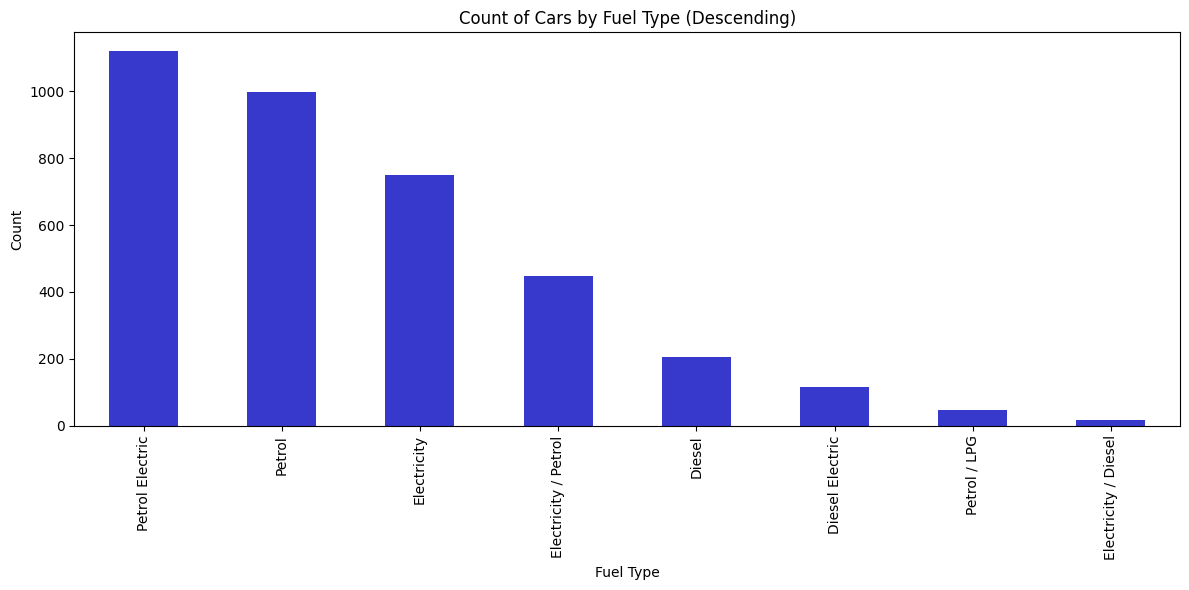

In [6]:
# Plot the categorical data from fuel  type column
fuel_type_counts = data["Fuel Type"].value_counts().reindex(fuel_type_categories, fill_value=0)
sorted_counts = fuel_type_counts.sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sorted_counts.plot(kind="bar", color="#3639CC")
plt.title("Count of Cars by Fuel Type (Descending)")
plt.ylabel("Count")
plt.xlabel("Fuel Type")
plt.tight_layout()
plt.show()

## Emissions Analysis
As the discussion is about emission, we will further understand the different types of emissions such as Carbon Monoxide (CO), Carbon Dioxide (CO2), Nitrogen Oxides (NOx) and Total Hydrocarbons (THC). These emissions are not polluting the environment but impacting our health. According to WHO (2021), when CO binds with haemoglobin more readily than oxyegen, it might reduce oxygen transport in blood and posing serious health risks to humans. While CO2 is non-toxis to humans but it significantly contributes to global warming and climate change as it can trap the heat in the atmosphere (Intergovernmental Panel on Climate Change [IPCC], 2021). When the temperature increase, it might bring disasters to human such as flood or extreme heat wave.

### Carbon Monoxide (CO) and Carbon Dioxide (CO2)
From the following bar chart, we can clearly see the emissions of CO2 and CO are co-exists in petrol or hybrid vehicles but not in electric car. Emission of CO is high especially in diesel vehicle and emission of CO2 based on WLTP CO2 is about the same in petrol or diesel verhicles but low in hybrid vehicles. WLTP CO2 Weighted seems to be not reliable as it is empty for most of the vehicles type. 

In [7]:
# Calculate mean emissions by fuel type
metrics_CO2 = ["WLTP CO2", "WLTP CO2 Weighted", "Emissions CO [mg/km]"]
CO2_emission_means = data.groupby("Fuel Type")[metrics_CO2].mean().reindex(fuel_type_categories)

metrics_NOx = ["Emissions NOx [mg/km]", "RDE NOx Urban", "RDE NOx Combined"]
NOx_emission_means = data.groupby("Fuel Type")[metrics_NOx].mean().reindex(fuel_type_categories)

metrics_THC = ["THC Emissions [mg/km]", "THC + NOx Emissions [mg/km]"]
has_thc = all(col in data.columns for col in metrics_THC)
THC_emission_means = (
    data.groupby("Fuel Type")[metrics_THC].mean().reindex(fuel_type_categories)
    if has_thc else None
)


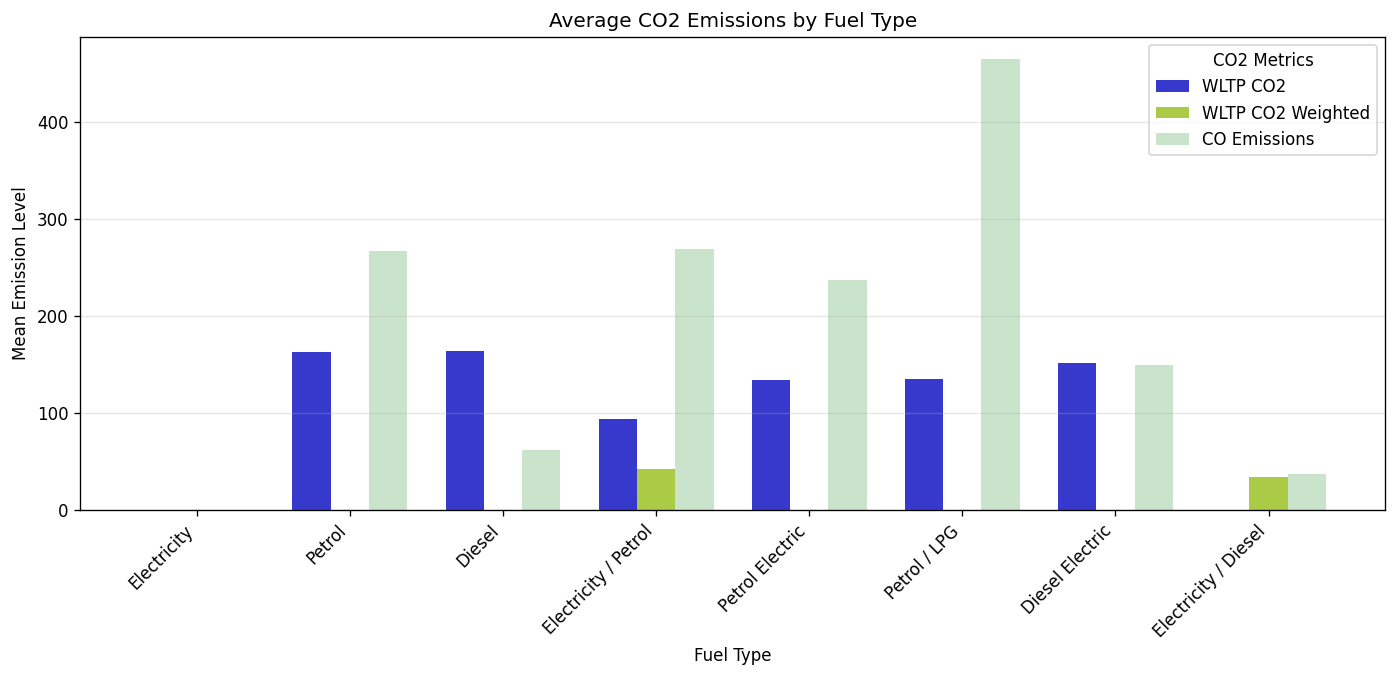

In [8]:
# Plot average CO2 emissions by fuel type
x = np.arange(len(CO2_emission_means.index))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
ax.bar(x - width, CO2_emission_means["WLTP CO2"], width, label="WLTP CO2", color="#3639CC")
ax.bar(x, CO2_emission_means["WLTP CO2 Weighted"], width, label="WLTP CO2 Weighted", color="#ABCA45")
ax.bar(x + width, CO2_emission_means["Emissions CO [mg/km]"], width, label="CO Emissions", color="#C9E4CA")
ax.set_title("Average CO2 Emissions by Fuel Type")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Mean Emission Level")
ax.set_xticks(x)
ax.set_xticklabels(CO2_emission_means.index, rotation=45, ha="right")
ax.legend(title="CO2 Metrics")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout(pad=2.0)
plt.show()


### Nitrogen Oxides (NOx)
Nitrogen Oxides (NOx) emissions are a major cause to photochemical smog, acid rain, and respiratory health issues (U.S. Environmental Protection Agency [EPA], 2023). Based on following chart, we find NOx emission exists in all the vehicles including electic car. Electric cars do produce a small average amount of NOx according Veza et al (2023). However, it should be understood that the NOx production from electric vehicles is caused from the source of electric used to charge the car batteries. NOₓ emissions from electric vehicles originate from the fossil fuel–based electricity used to charge them. The mean for NOx in Real Driving Emissions (RDE) for urban and combined are about same but they are higher than Emissions (NOx) [mg/km] which was the result tested in lab. 

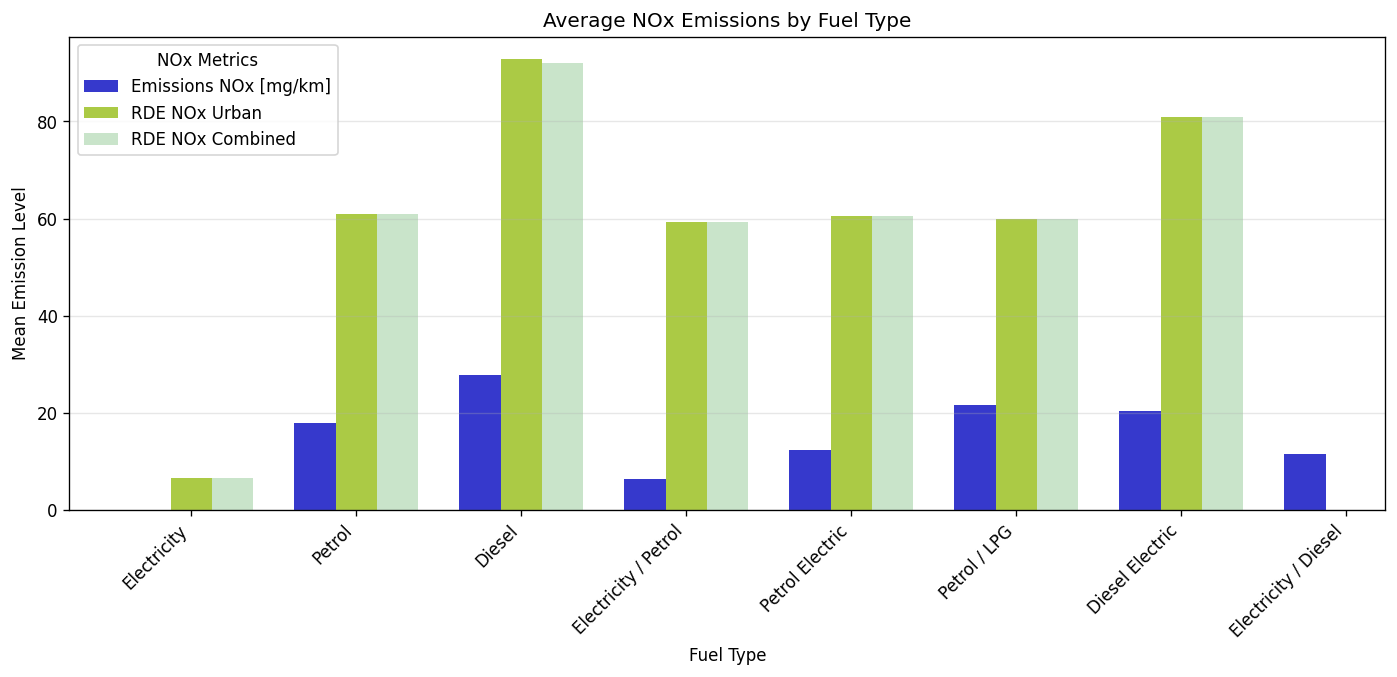

In [9]:
# Plot average NOx emissions by fuel type
x = np.arange(len(NOx_emission_means.index))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
ax.bar(x - width, NOx_emission_means["Emissions NOx [mg/km]"], width, label="Emissions NOx [mg/km]", color="#3639CC")
ax.bar(x, NOx_emission_means["RDE NOx Urban"], width, label="RDE NOx Urban", color="#ABCA45")
ax.bar(x + width, NOx_emission_means["RDE NOx Combined"], width, label="RDE NOx Combined", color="#C9E4CA")
ax.set_title("Average NOx Emissions by Fuel Type")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Mean Emission Level")
ax.set_xticks(x)
ax.set_xticklabels(NOx_emission_means.index, rotation=45, ha="right")
ax.legend(title="NOx Metrics")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout(pad=2.0)
plt.show()


### Total Hydrocarbons (THC)
Total Hydrocarbons (THC) are volatile organic compounds (VOCs) that react with NOx in the presence of sunlight to form ground-level ozone and smog (European Environment Agency [EEA], 2022). THC might cause photochemical pollution and impact the urban air quality but it have to react with NOx, hence, in this report we will not focus in analysing the relationship of THC with other features.

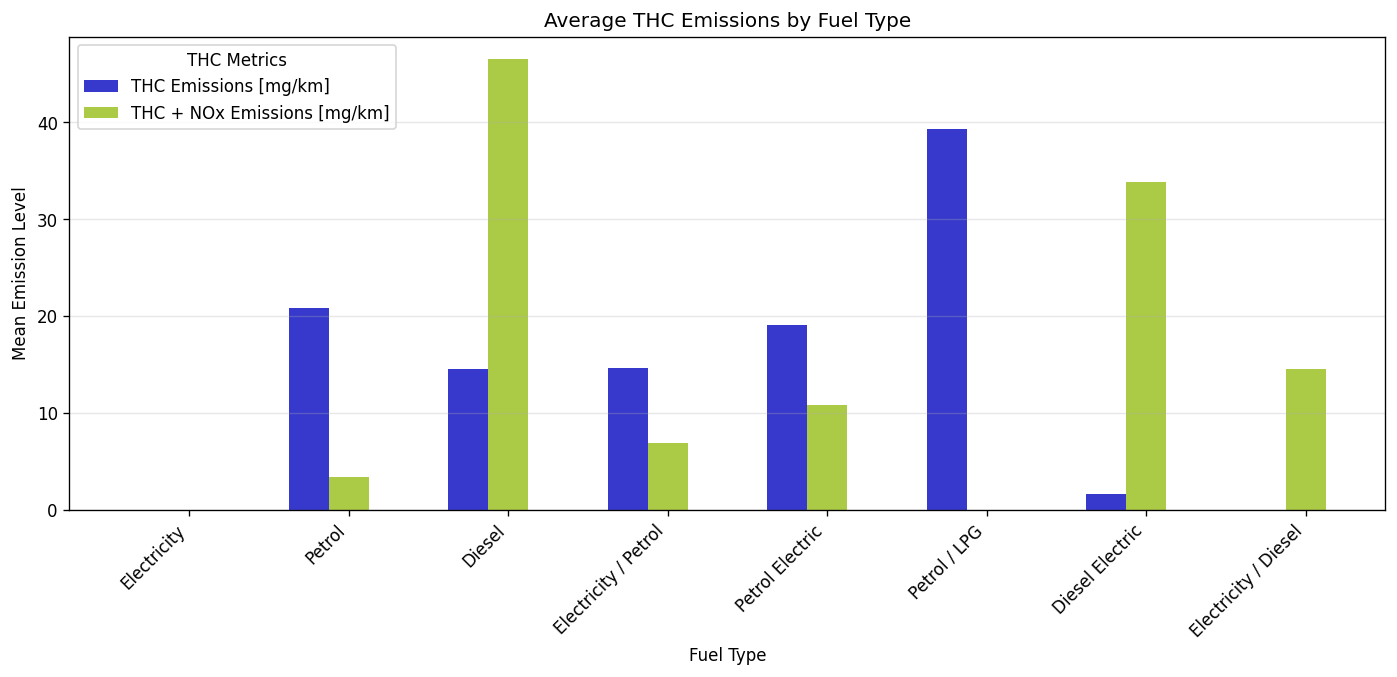

In [10]:
# Plot average THC emissions by fuel type (if available)
if not has_thc or THC_emission_means is None:
    print("THC metrics not available for this dataset.")
else:
    x = np.arange(len(THC_emission_means.index))
    width = 0.25
    fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
    ax.bar(x - width, THC_emission_means["THC Emissions [mg/km]"], width, label="THC Emissions [mg/km]", color="#3639CC")
    ax.bar(x, THC_emission_means["THC + NOx Emissions [mg/km]"], width, label="THC + NOx Emissions [mg/km]", color="#ABCA45")
    ax.set_title("Average THC Emissions by Fuel Type")
    ax.set_xlabel("Fuel Type")
    ax.set_ylabel("Mean Emission Level")
    ax.set_xticks(x)
    ax.set_xticklabels(THC_emission_means.index, rotation=45, ha="right")
    ax.legend(title="THC Metrics")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout(pad=2.0)
    plt.show()


## Target Variables
From the analysis, we have enough data for modelling accross different fuel types but we will choose CO2 as global warming is most common topic when discussing about the impacts of emission. As mentioned above, WLTP CO2 Weighted is lacking of data distribution accross fuel types, hence it will be excluded from target variables. Besides of CO2, we will pick Emissions NOx [mg/km] as our target variables because it has difference mean across fuld type which is easier for our comparison and prediction afterward in this report. 

Based on the graphs above, eletric cars have no CO2 emissions, and low NOx emissions. Therefore, all of the eletric cars will be excluded from the datasets when we build the model. Given the distribution, two datasets will be created based on their fuel types - fuel cars only (data_fuel), and hybrid cars only (data_hybrid). Furthermore, since the target variables (WLTP CO2 and NOx emissions) are not highly included in Eletricity /Diesel Fuel type, they will be removed from the data_hybrid.

# Data Preprocessing
## Model Building
After identified the target variables - Emissions NOx [mg/km] and WLTP CO2, based on the category that we have defined above, we will choose what are the relevant columns to keep in the modelling and remove all irrelevant columns. Reducing the variables/columns can help in improving the performance and cost effectiveness. Variables that are related to the manufacturer or car model will be removed as these variables cannot be used in predictions. As mentioned above, we will create 2 datasets - data_fuel and data_hybrid, which contains fuel vehicles and hybrid vehicles. Hence, the variables that are not relevant to fuel or hybrid will be removed too. For emmissions, we will keep only Emissions NOx [mg/km] and WLTP CO2 as our target variables and drop rest of the emissions related columns. Lastly, date and standard category columns will be removed too as this information cannot be used for modeling. 

| Category  | Keep | Remove |
|-----------|------| ------ |
| Vehicle   |  Manual or Automatic, Engine Capacity, Fuel Type, Powertrain, Engine Power (PS) | Manufacturer, Model, Description, Transmission, Engine Power (Kw) |
| Fuel Consumption | WLTP Imperial Low, WLTP Imperial Medium, WLTP Imperial High, WLTP Imperial Extra High, WLTP Imperial Combined, WLTP Imperial Combined (Weighted), WLTP Metric Low, WLTP Metric Medium,  WLTP Metric High, WLTP Metric Extra High, WLTP Metric Combined, WLTP Metric Combined (Weighted)| Diesel VED Supplement, Testing Scheme |
| Electric Consumption | |Electric energy consumption Miles/kWh, wh/km ,Maximum range (Km), Maximum range (Miles), Equivalent All Electric Range Miles, Equivalent All Electric Range KM, Electric Range City Miles, Electric Range City Km |
| Standard |  | Euro Standard | 
| Emmission | Emissions NOx [mg/km], WLTP CO2  | WLTP CO2 Weighted , THC Emissions [mg/km], THC + NOx Emissions [mg/km], Particulates [No.] [mg/km], RDE NOx Urban, RDE NOx Combined, Noise Level dB(A) |
| Date | | Date of change |

In [11]:
removed_variables = [
    "Manufacturer", "Model", "Description",
    "Transmission", "Engine Power (Kw)", "Electric energy consumption Miles/kWh",
    "wh/km", "Maximum range (Km)", "Maximum range (Miles)",
    "Euro Standard", "Diesel VED Supplement", "Testing Scheme", 
    "WLTP CO2 Weighted", "Equivalent All Electric Range Miles", "Equivalent All Electric Range KM",
    "Electric Range City Miles", "Electric Range City Km", "Emissions CO [mg/km]",
    "THC Emissions [mg/km]", "THC + NOx Emissions [mg/km]", "Particulates [No.] [mg/km]",
    "RDE NOx Urban", "RDE NOx Combined", "Noise Level dB(A)", 
    "Date of change"
]
print(f"Data shape before removing columns: {data.shape}")
data = data.drop(columns=removed_variables)
print(f"Data shape after removing columns: {data.shape}")

Data shape before removing columns: (3702, 44)
Data shape after removing columns: (3702, 19)


After removing the irrelevant variables, we have 19 variables remained in the datasets. Next, we will split our data into two groups as mentioned above which are the hybrid vehicles and fuel vehicles. We are getting **1686 hybrid** vehicles and **1250 fuel** vehicles in our datasets after splitting by the fuel type. 

In [12]:
# Define fuel type categories for each group
# electric_types = ["Electricity"]

hybrid_types = [
    "Electricity / Petrol", "Petrol Electric",
    "Diesel Electric"]

fuel_types = [
    "Petrol", "Diesel", "Petrol / LPG"
]

# Split the dataset
# data_electric = data[data["Fuel Type"].isin(electric_types)] #Can remove since not relevant to the target variable
data_hybrid = data[data["Fuel Type"].isin(hybrid_types)]
data_fuel = data[data["Fuel Type"].isin(fuel_types)]

# print(f"Electric cars: {data_electric.shape[0]} rows")
print(f"Hybrid cars: {data_hybrid.shape[0]} rows")
print(f"Fuel cars: {data_fuel.shape[0]} rows")
# print(f"Original data: {data.shape[0]} rows ") #To check whether the split is correct

Hybrid cars: 1686 rows
Fuel cars: 1250 rows


## Data Cleaning
Before we start the modelling, cross checking on the data with "not available (NA)" values or empty, this will help to ensure the accuracy of our model. Based on the result, we found NA values in WLTP Imperial Combined (Weighted) and WLTP Metric Combined (Weighted) columns in both fuel and hybrid datasets. After removing the NA rows, we have **1233 fuel** vehicles and **1683 hybrid** vehicles remained in the datasets. 

In [13]:
print("Fuel dataset shape before removing NA values:", data_fuel.shape);
print("Hybrid dataset shape before removing NA values:", data_hybrid.shape);

Fuel dataset shape before removing NA values: (1250, 19)
Hybrid dataset shape before removing NA values: (1686, 19)


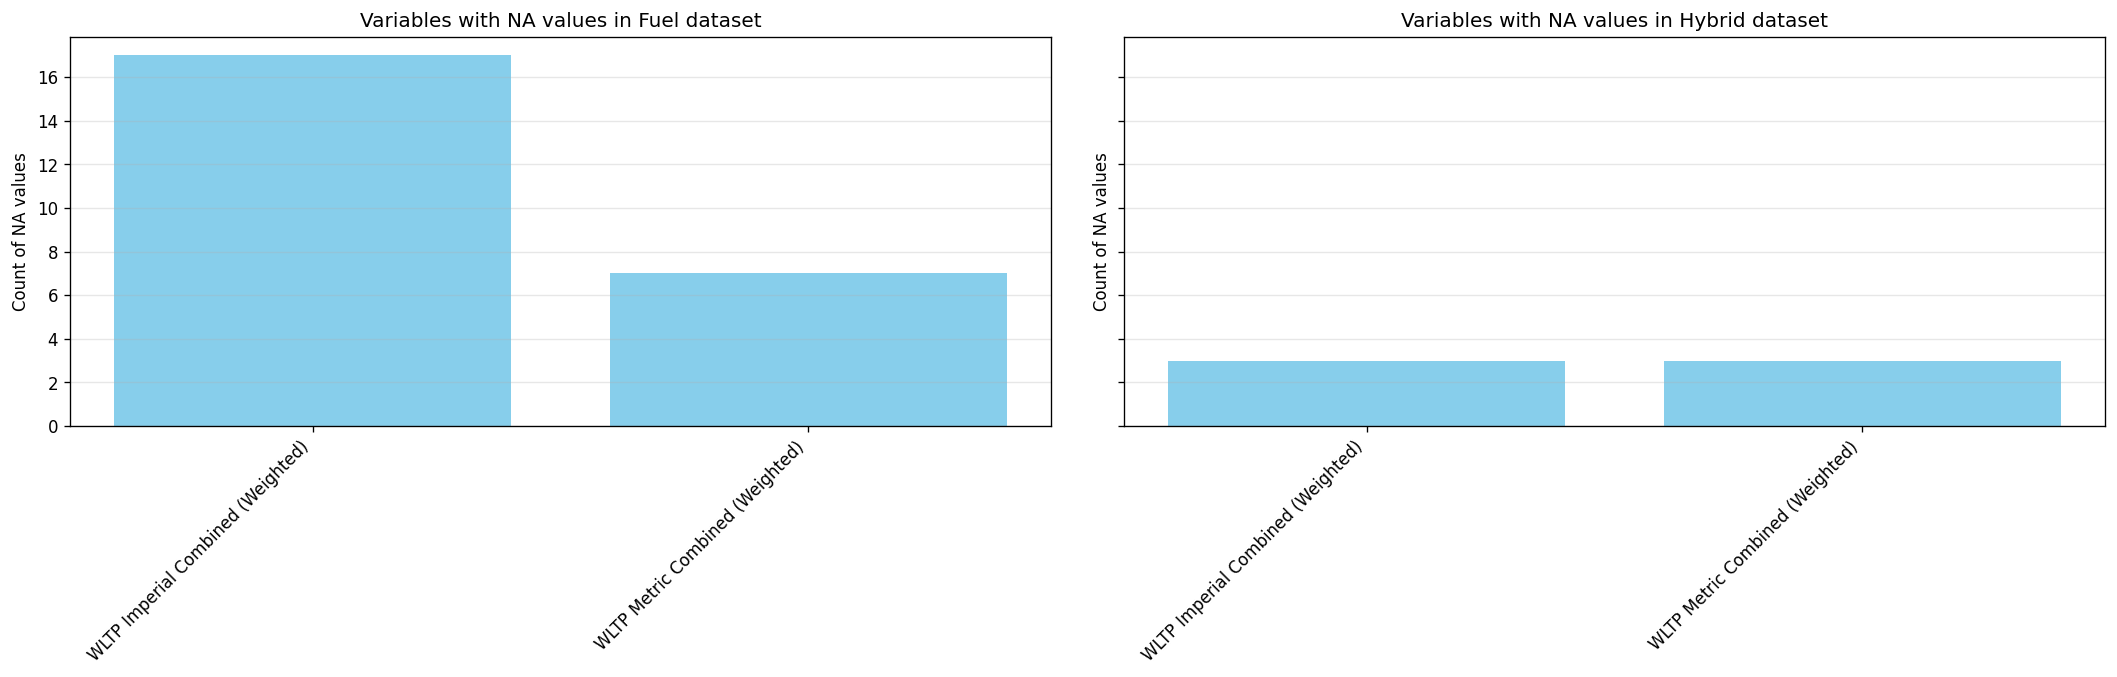

In [14]:
# Visualise columns containing NA values
def count_visualisa_na(data, data_name="data", *, compare_data=None, compare_name=None):
    def _prepare_counts(df):
        counts = df.isna().sum()
        counts = counts[counts > 0]
        return counts

    counts_main = _prepare_counts(data)

    if compare_data is None:
        if counts_main.empty:
            print(f"No NA values found in {data_name}.")
            return
        fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
        positions = np.arange(len(counts_main))
        ax.bar(positions, counts_main.values, color="skyblue")
        ax.set_xticks(positions)
        ax.set_xticklabels(counts_main.index, rotation=45, ha="right")
        ax.set_ylabel("Count of NA values")
        ax.set_title(f"Variables with NA values in {data_name}")
        ax.grid(axis="y", alpha=0.3)
        fig.tight_layout(pad=2.0)
        plt.show()
        return

    compare_name = compare_name or "comparison dataset"
    counts_compare = _prepare_counts(compare_data)

    if counts_main.empty and counts_compare.empty:
        print(f"No NA values in either {data_name} or {compare_name}.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=120, sharey=True)
    configs = [
        (axes[0], counts_main, f"Variables with NA values in {data_name}"),
        (axes[1], counts_compare, f"Variables with NA values in {compare_name}")
    ]

    for ax, counts, title in configs:
        if counts.empty:
            ax.axis("off")
            ax.set_title(title)
            ax.text(0.5, 0.5, "No NA values", ha="center", va="center", fontsize=12, transform=ax.transAxes)
            continue
        positions = np.arange(len(counts))
        ax.bar(positions, counts.values, color="skyblue")
        ax.set_xticks(positions)
        ax.set_xticklabels(counts.index, rotation=45, ha="right")
        ax.set_ylabel("Count of NA values")
        ax.set_title(title)
        ax.grid(axis="y", alpha=0.3)

    fig.tight_layout(pad=2.0)
    plt.show()

if "data_hybrid" in globals():
    count_visualisa_na(
        data_fuel,
        data_name="Fuel dataset",
        compare_data=data_hybrid,
        compare_name="Hybrid dataset"
    )
else:
    count_visualisa_na(data_fuel, data_name="Fuel dataset")


In [15]:
data_fuel = data_fuel.dropna()
print("Dataset shape after removing NA values:", data_fuel.shape)


Dataset shape after removing NA values: (1233, 19)


In [16]:
data_hybrid = data_hybrid.dropna()
print("Dataset shape after removing NA values:", data_hybrid.shape)

Dataset shape after removing NA values: (1683, 19)


## Correlation Analysis
Correlation analysis started with a heatmap to understand the correlation between each variables. From the heatmap, we can see the correlation with our target variables are low at Engine Power (Ps), WLTP Imperial Combined (Weighted), and WLTP Metric Combined (Weighted). 

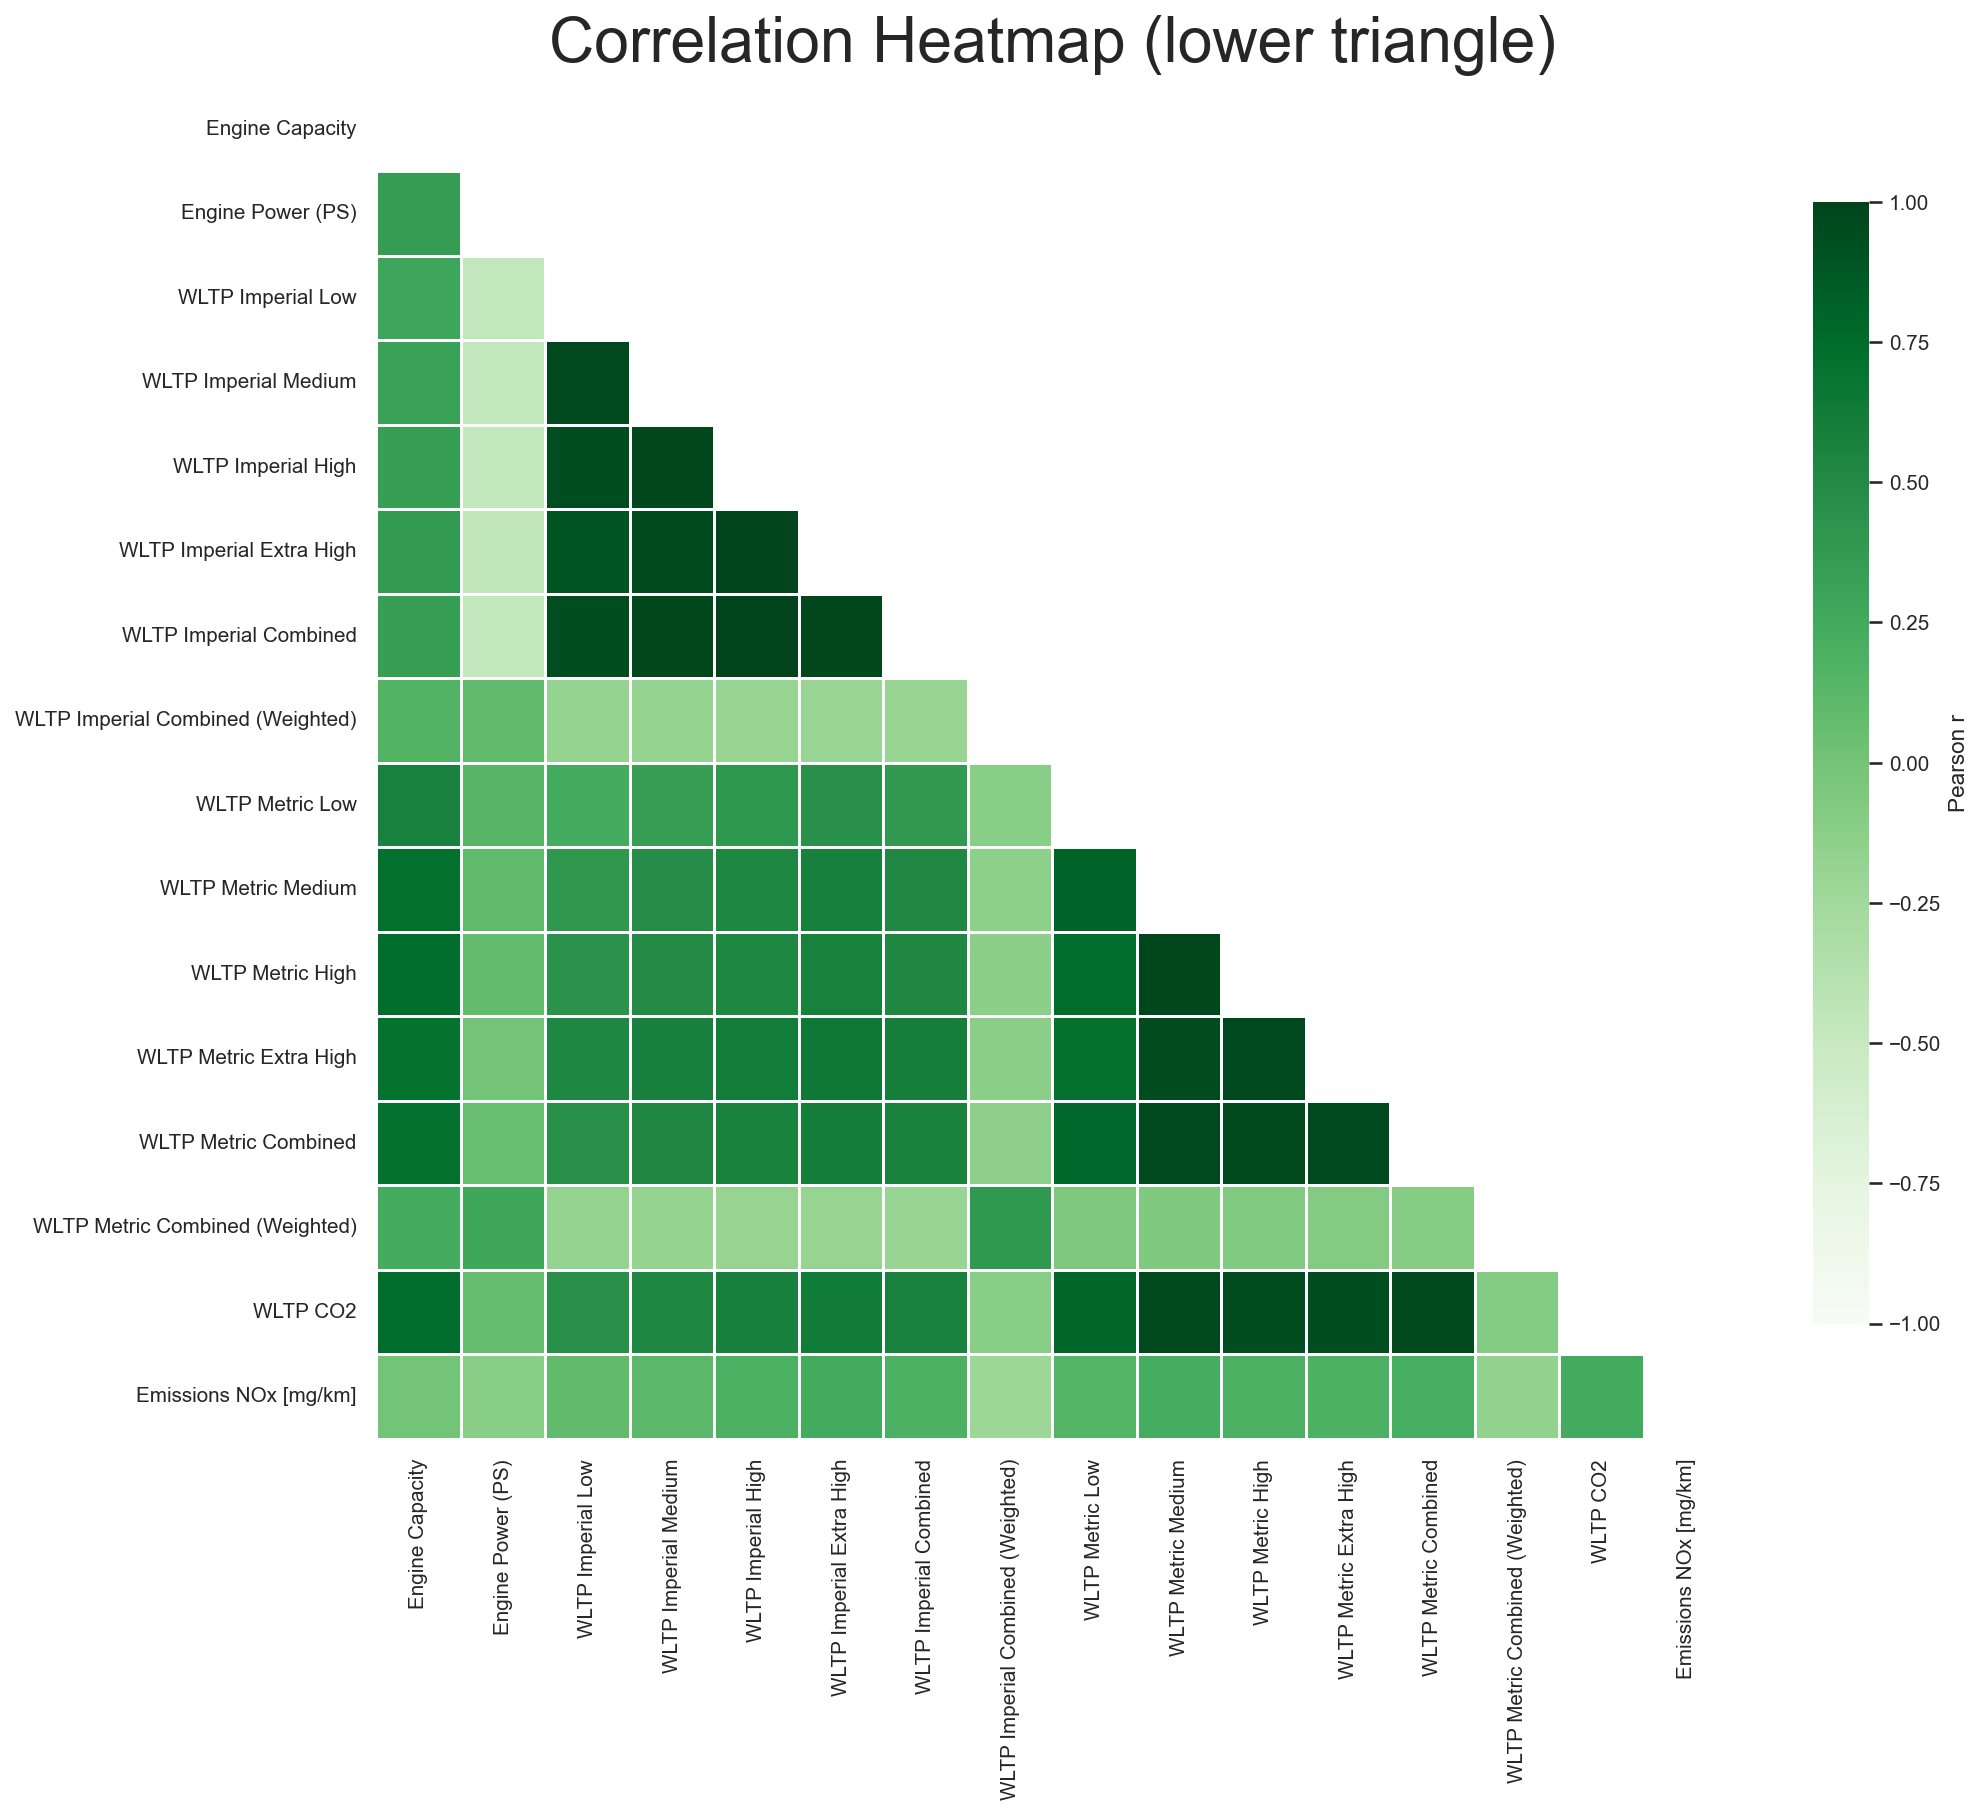

In [17]:
sns.set_theme(style="white", font_scale=0.9)  # smaller fonts

# Select only numeric columns for computing correlation
numeric_data = data.select_dtypes(include=[np.number])
corr = numeric_data.corr()

# mask the upper triangle (matrix is symmetric)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12), dpi=150)
ax = sns.heatmap(
    corr, mask=mask, cmap="Greens", vmin=-1, vmax=1, center=0,
    linewidths=.5, linecolor="white",
    cbar_kws=dict(shrink=.8, label="Pearson r"),
    annot=False,  # turn off numbers (too dense)
    square=True
)

ax.set_title("Correlation Heatmap (lower triangle)", fontsize = 30, pad=12)
plt.tight_layout()
plt.show()

In [18]:
# Create a function to plot top Correlation values based on the target variable
def plot_top_correlation(variable: str, data, *, compare_data=None, compare_name=None):
    """Plot correlations for `variable` in `data`.

    When `compare_data` is provided, render a side-by-side subplot for comparison.
    """

    def _compute_top(df):
        if variable not in df.columns:
            raise KeyError(f"{variable} not found in dataframe columns")
        corr = df.select_dtypes(include="number").corr()
        if variable not in corr.columns:
            raise ValueError(f"{variable} is not numeric or lacks correlations")
        series = corr[variable].drop(labels=[variable])
        return series.reindex(series.abs().sort_values(ascending=False).index).head(20)

    def _infer_label(df, explicit=None):
        if explicit:
            return explicit
        if "Fuel Type" in df.columns:
            if df["Fuel Type"].isin(fuel_types).any():
                return "Fuel Cars"
            if df["Fuel Type"].isin(hybrid_types).any():
                return "Hybrid Cars"
        return "Dataset"

    def _plot(ax, series, title):
        bars = ax.barh(series.index, series.values, color="seagreen", edgecolor="black")
        for bar, value in zip(bars, series.values):
            ax.text(value, bar.get_y() + bar.get_height() / 2, f"{value:.2f}",
                    ha="left" if value > 0 else "right", va="center", fontsize=9)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(title, fontsize=15, pad=10)
        ax.set_xlabel("Correlation - Pearson r", fontsize=11)
        ax.set_ylabel("Variable", fontsize=11)
        ax.invert_yaxis()
        ax.grid(axis="x", alpha=0.3)

    primary_label = _infer_label(data)
    top_primary = _compute_top(data)

    if compare_data is None:
        fig, ax = plt.subplots(figsize=(8, 7), dpi=150)
        _plot(ax, top_primary, f"Correlations with {variable} from {primary_label}")
        fig.tight_layout()
        plt.show()
        return

    secondary_label = _infer_label(compare_data, explicit=compare_name)
    top_secondary = _compute_top(compare_data)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150, sharey=False)
    _plot(axes[0], top_primary, f"Correlations with {variable} from {primary_label}")
    _plot(axes[1], top_secondary, f"Correlations with {variable} from {secondary_label}")
    axes[1].set_ylabel("")
    fig.tight_layout()
    plt.show()



When drilling down to the correlations with CO2, we can see that the WLTP Imperial Combined (Weighted) and WLTP Metric Combined (Weighted) are having the lowest score in both fuel and hybrid vehicles. Whereas fuel is having high correlation with fuel vehicle but not the hybrid vehicle. 

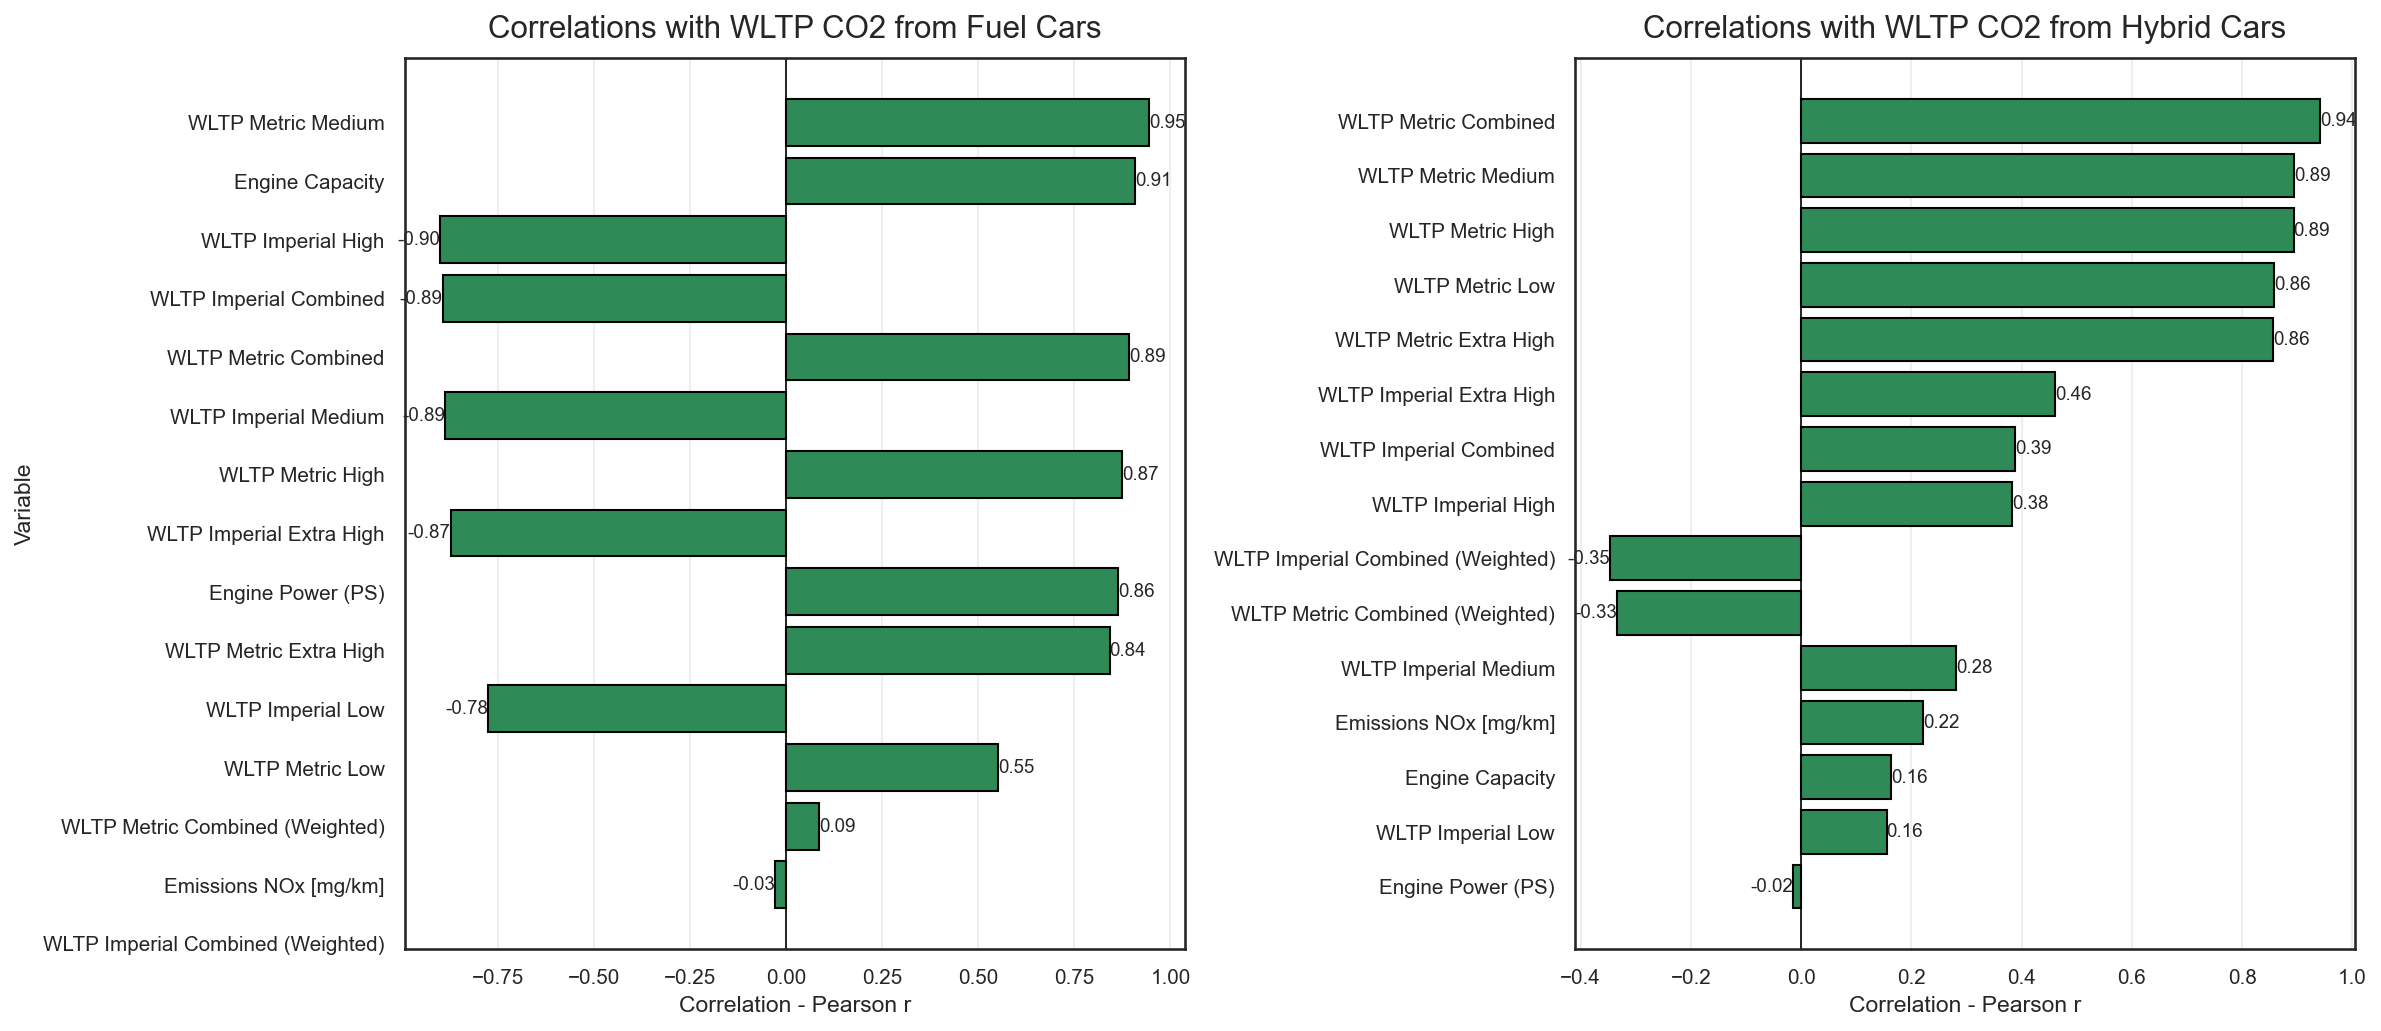

In [19]:
# -- Correlation comparison: Fuel
plot_top_correlation("WLTP CO2", data_fuel, compare_data=data_hybrid, compare_name="Hybrid Cars")

In NOx emmissions, WLTP Imperial Combined (Weighted) and WLTP Metric Combined (Weighted) are still having lowest correlation in fuel vehicles but these variables are the top three correlated variables in hybrid vehicles. This could be due to the hybrid engine turns on intermittently, it often operates under non-steady, high-load conditions to recharge the battery or accelerate. 

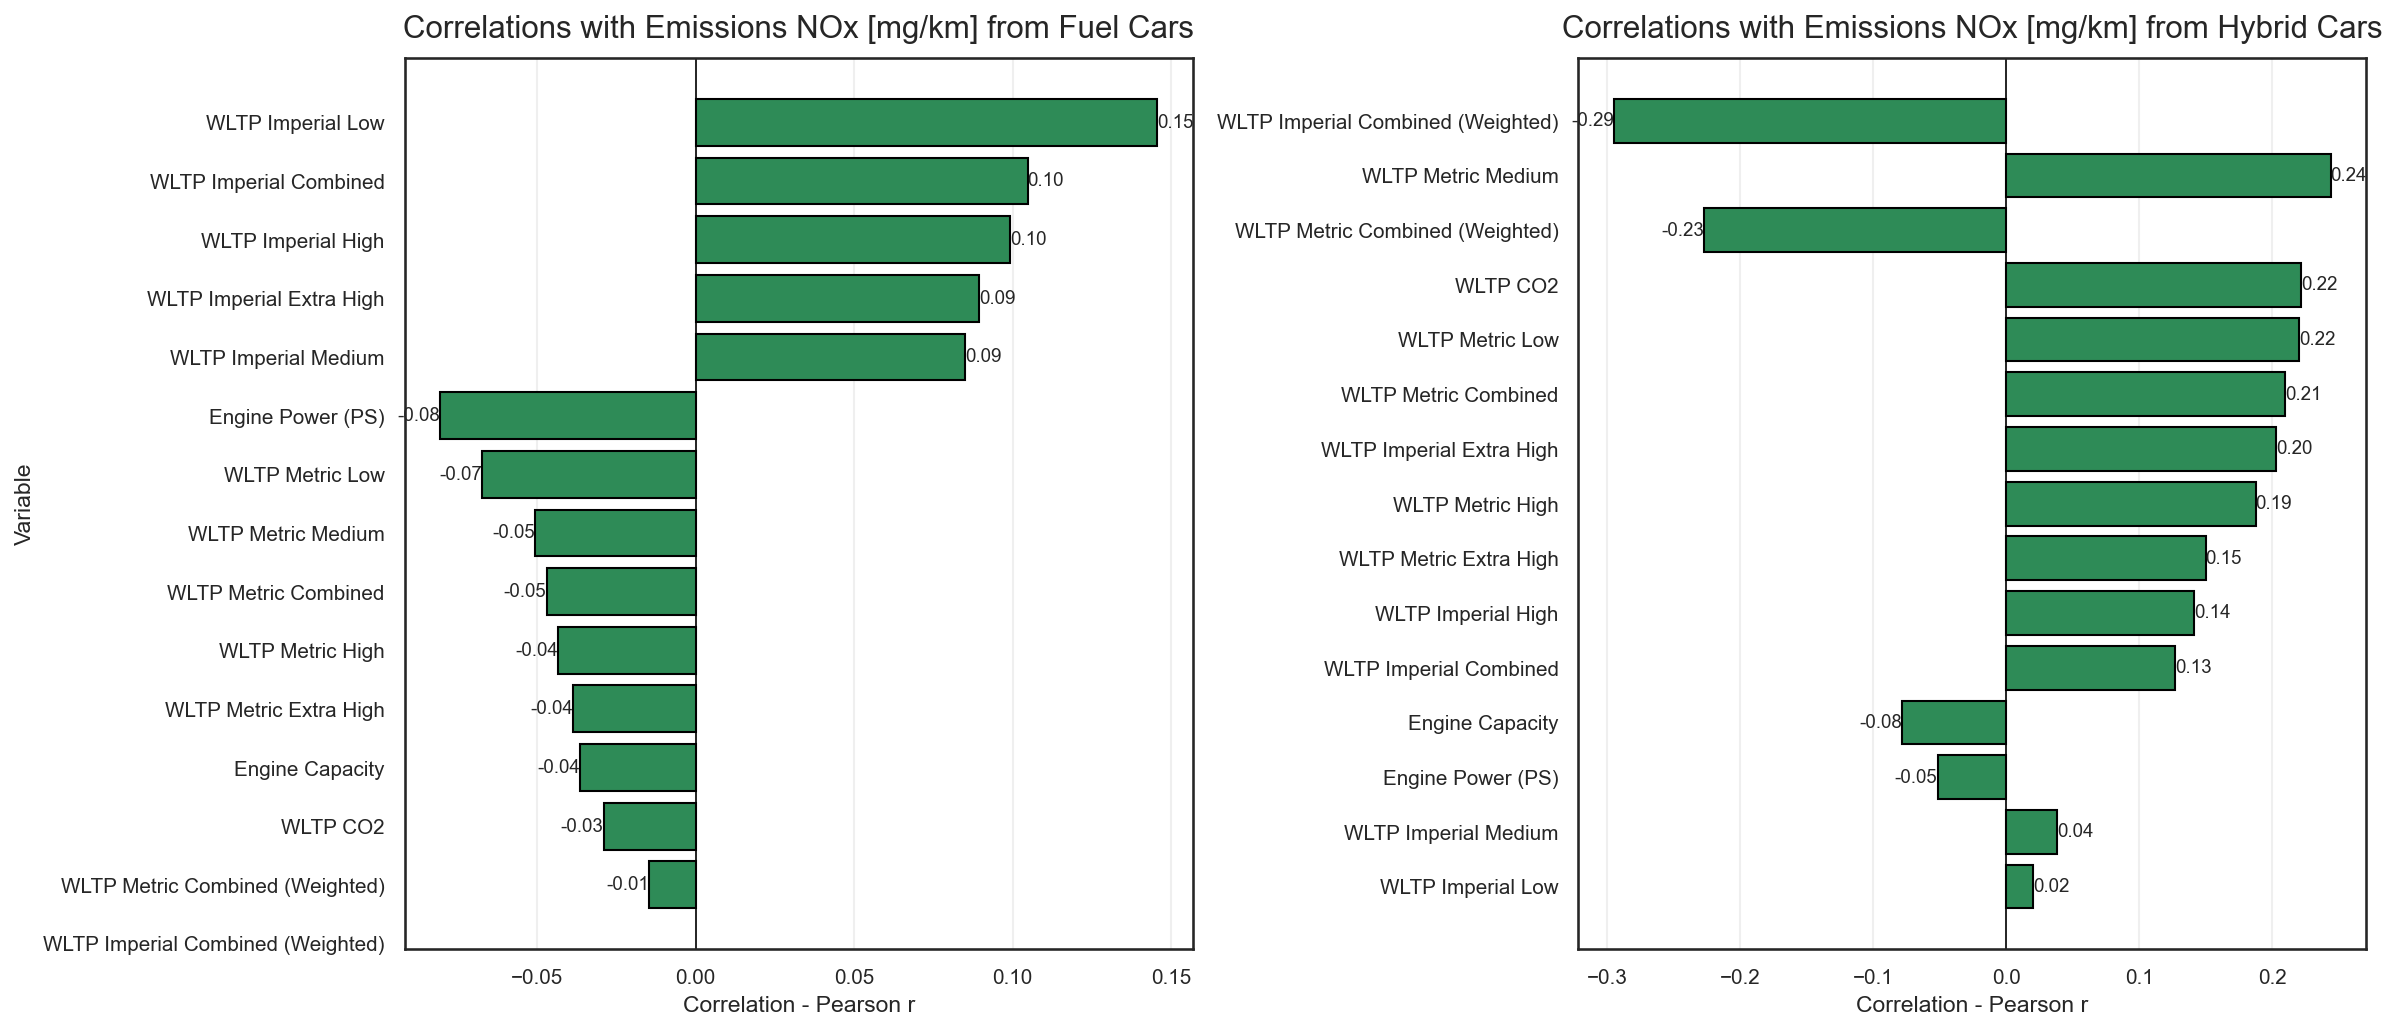

In [20]:
# -- Correlation comparison: Hybrid
plot_top_correlation("Emissions NOx [mg/km]", data_fuel, compare_data=data_hybrid, compare_name="Hybrid Cars")

## Data Distribution Analysis
Distribution of data is important in identifying the normalisation or standardisation of each variables in our datasets. Below histogram matrix that showing the data distribution for fuel vehicles, we can see that WLTP Imperial Combined (Weighted) and WLTP Metric Combined (Weighted) are not statistically normalised, as their disbutions are tightly clustered and do not follow a standardisation or z-score normalisation. Hence, we can safely remove WLTP Imperial Combined (Weighted) and WLTP Metric Combined (Weighted) columns from _data_fuel_ dataset

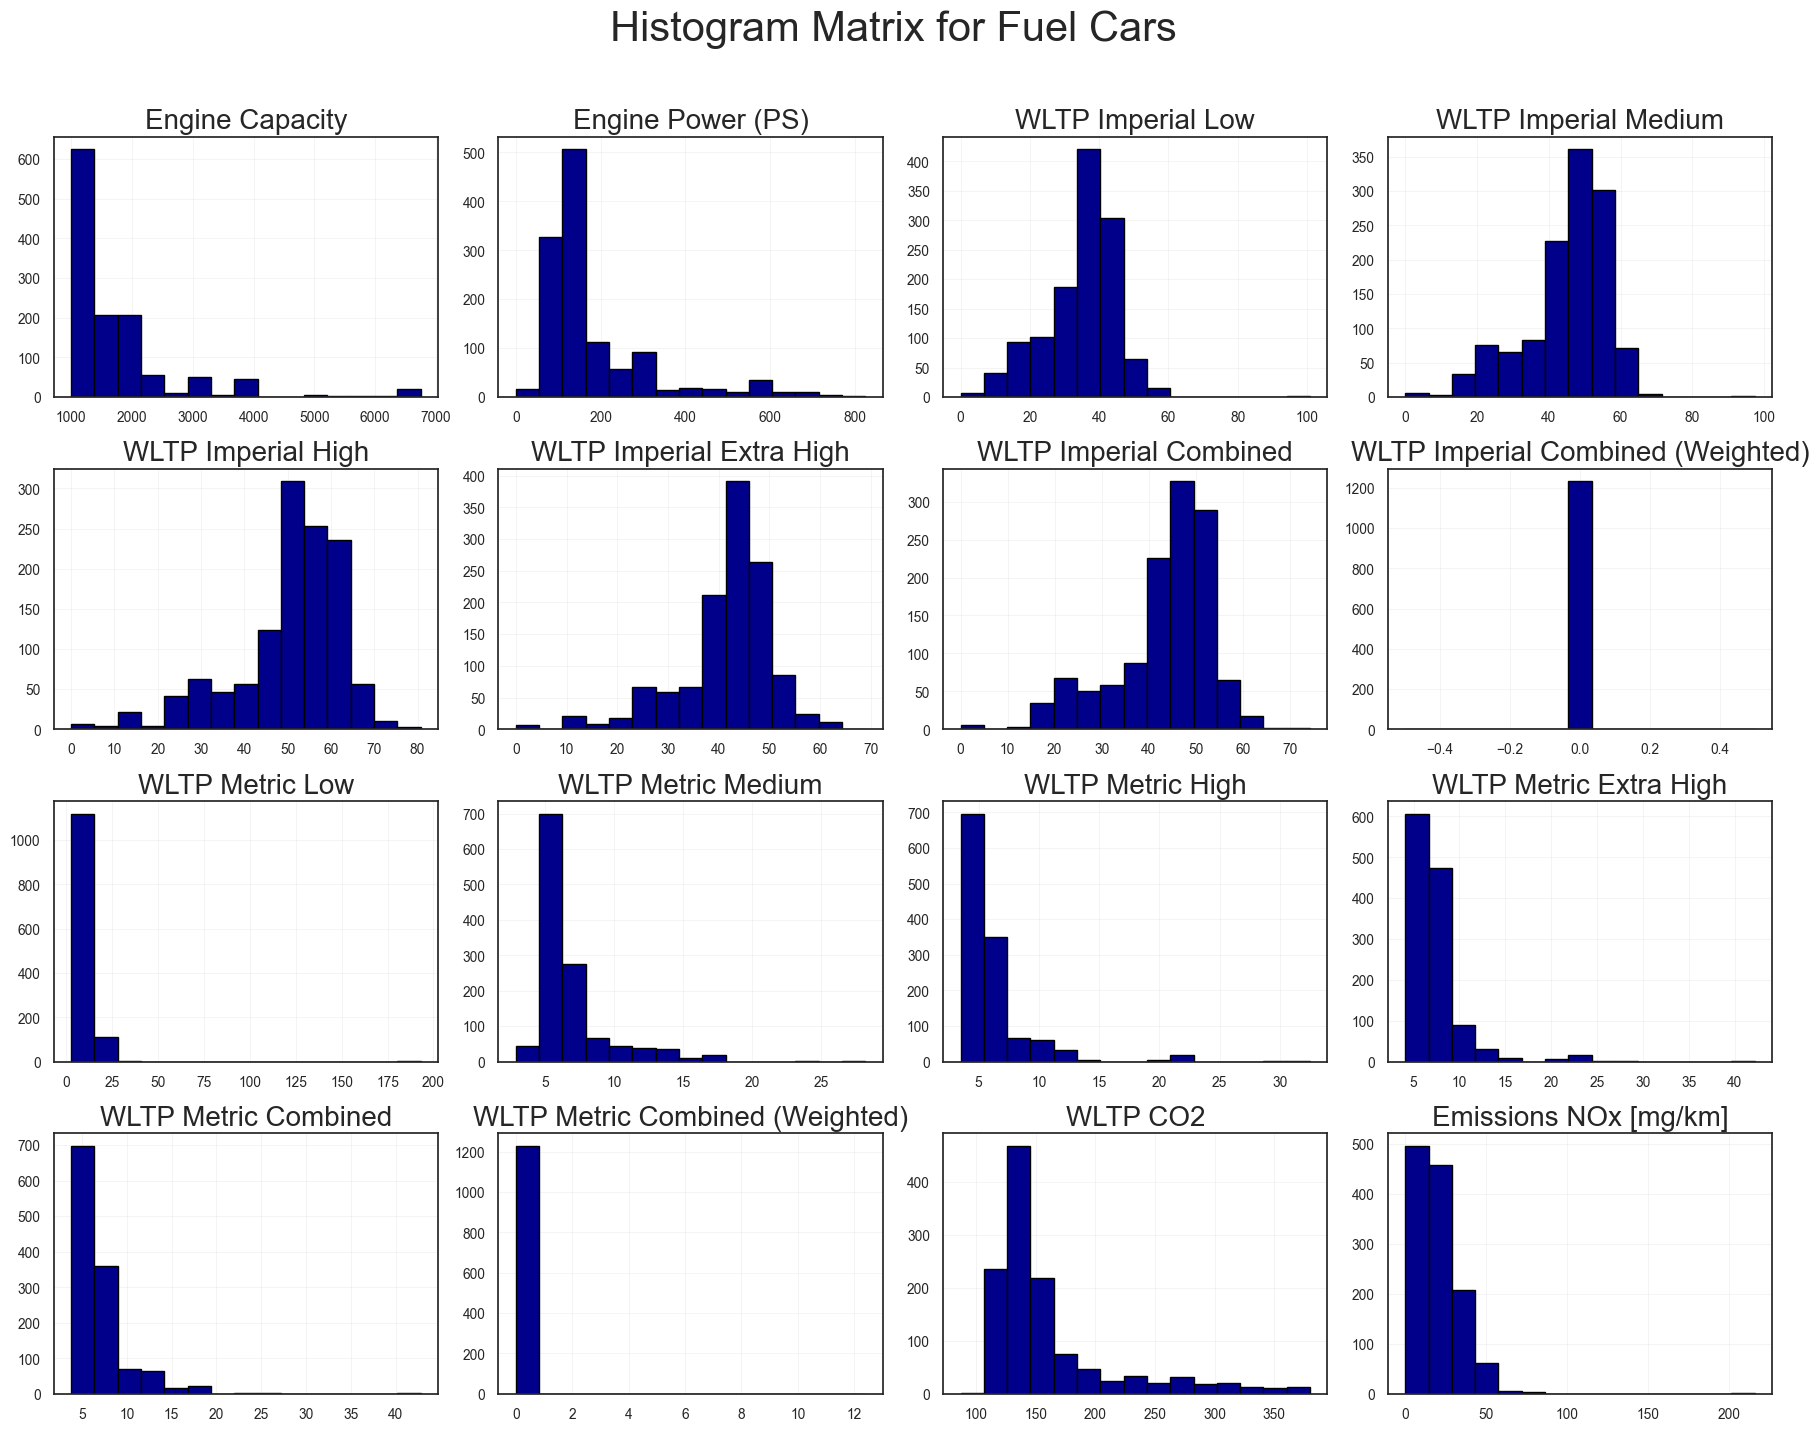

In [21]:
# -- Histogram Matrix for Fuel Cars --

# Set overall figure size (width, height)
axes = data_fuel.hist(
    figsize=(18, 14),  # larger matrix
    bins=15, # adjust bin count
    color='darkblue',
    edgecolor='black',
    grid=False
)

# Loop over all subplots to format text and labels
for ax in axes.flatten():
    # Bigger titles and smaller axis labels
    ax.set_title(ax.get_title(), fontsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    ax.grid(alpha=0.3, linewidth=0.5) # thin gridlines for readability

plt.suptitle("Histogram Matrix for Fuel Cars", fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# Remove irrelevant columns for regression task
data_fuel = data_fuel.drop(columns=["WLTP Imperial Combined (Weighted)", "WLTP Metric Combined (Weighted)"])
data_fuel.shape

(1233, 17)

Each variable in hybrid vehicles is statistically normalised, we do not see abnormal data distribution here. Hence, no changes to the variables for hybrid vehicles.  

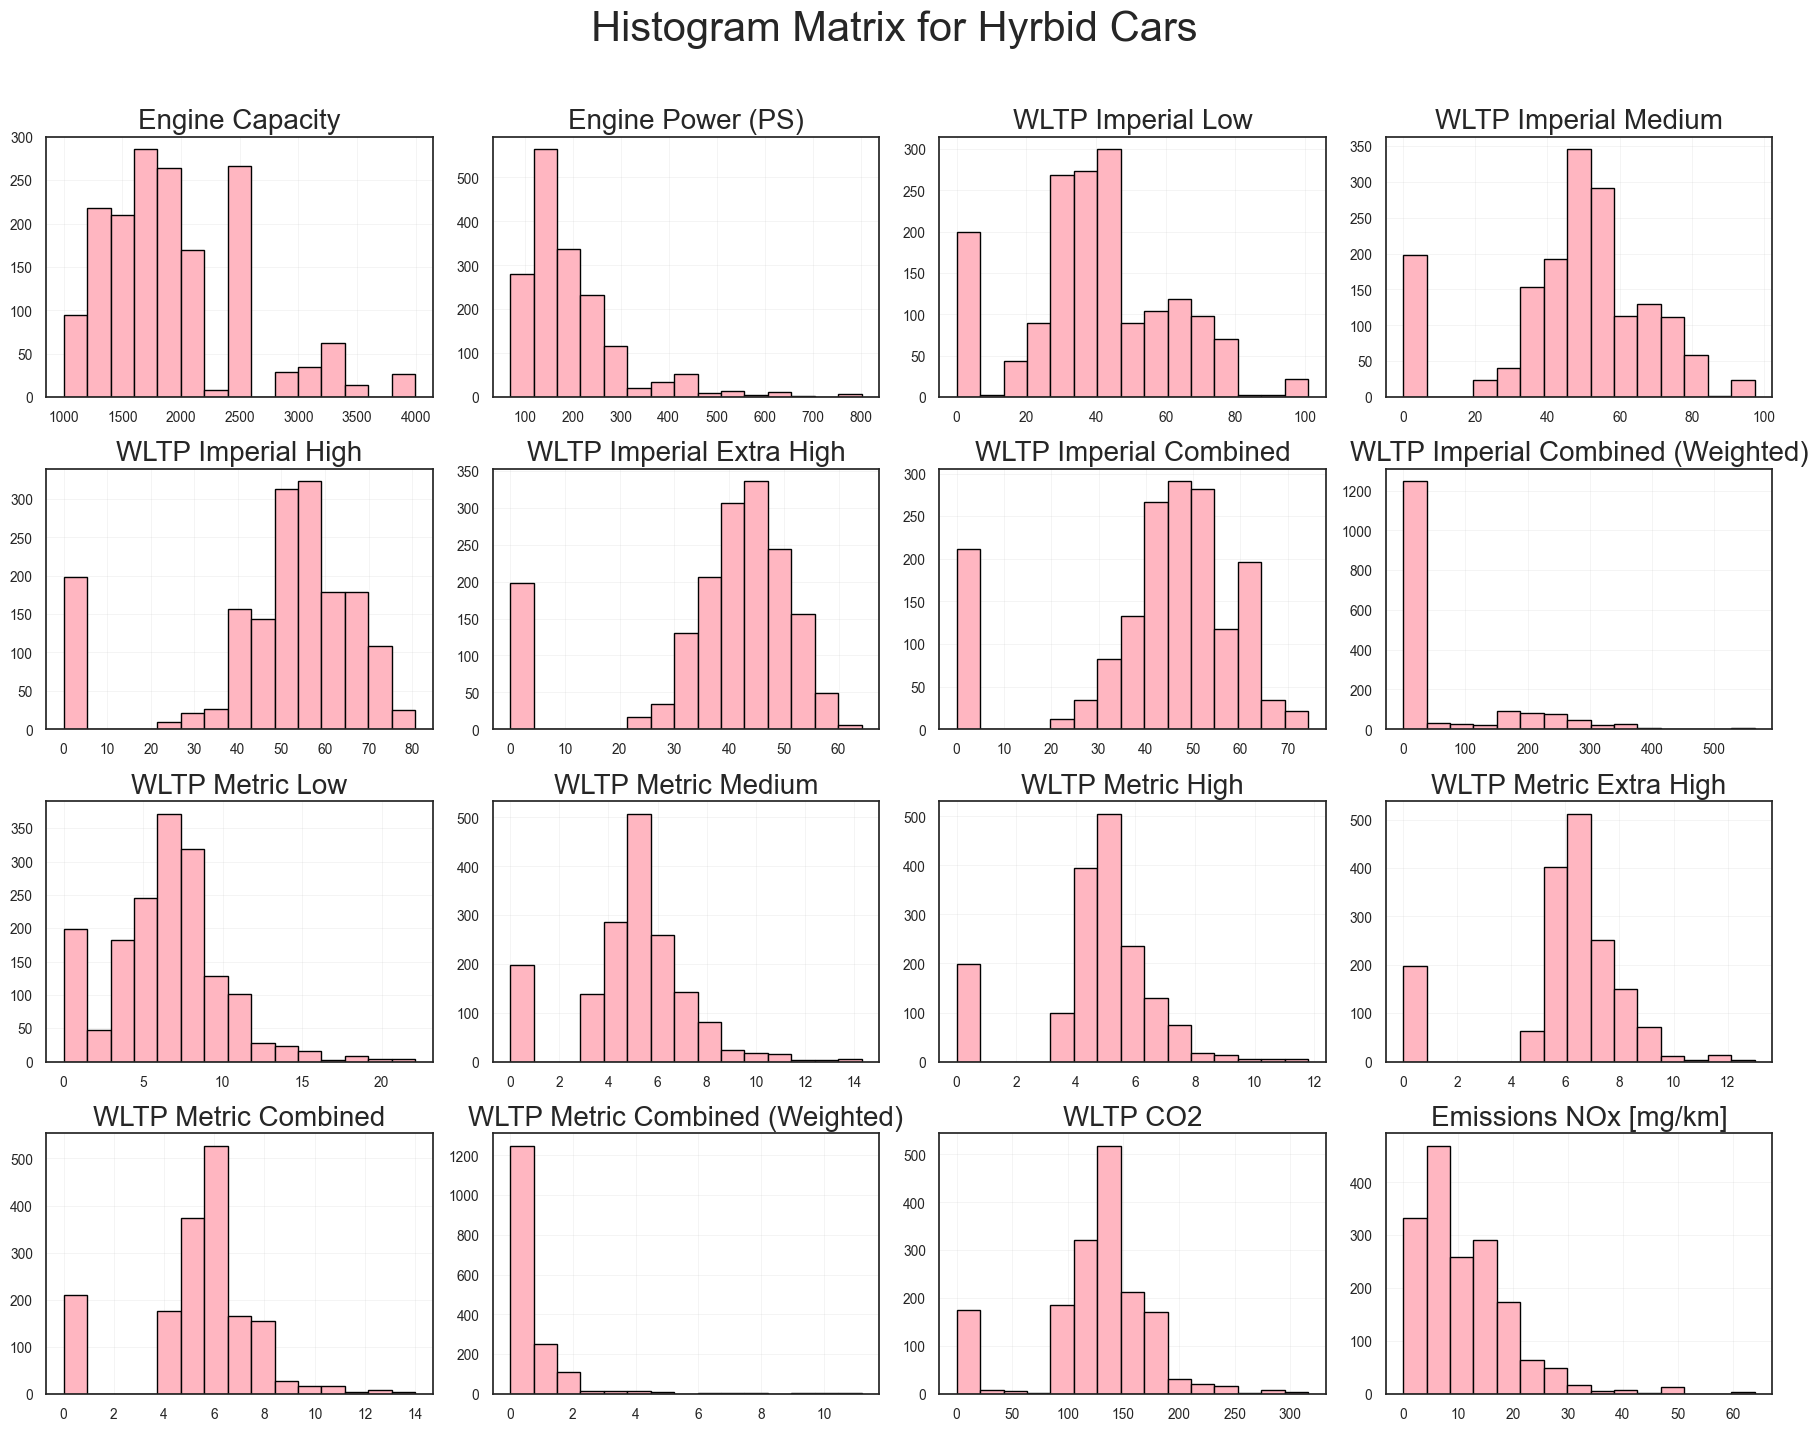

In [23]:
# -- Histogram Matrix for Hyrbid Cars --

# Set overall figure size (width, height)
axes = data_hybrid.hist(
    figsize=(18, 14),  # larger matrix
    bins=15, # adjust bin count
    color='lightpink',
    edgecolor='black',
    grid=False
)

# Loop over all subplots to format text and labels
for ax in axes.flatten():
    # Bigger titles and smaller axis labels
    ax.set_title(ax.get_title(), fontsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    ax.grid(alpha=0.3, linewidth=0.5) # thin gridlines for readability

plt.suptitle("Histogram Matrix for Hyrbid Cars", fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

## Outlier Check
To further improve our model and increase the accuracy, we have perform an analysis of the outliers for both datasets. In the fuel vehicles, we can clearly see the outliers are strongly skewed in most of the WLTP Metric variables and highly skewed in Engine Capacity and Power. This could be due to the high-performance models of vehicles. Since, the WLTP Imperial is having the same purpose with a different unit of measurements, we have decided to drop all the WLTP Metric variables which having higher outliers compare to MLTP Imperial. This table showing the updated model for _data_fuel_.


| Category  | Keep | Remove |
|-----------|------| ------ |
| Vehicle   |  Manual or Automatic, Engine Capacity, Fuel Type, Powertrain, Engine Power (PS) | Manufacturer, Model, Description, Transmission, Engine Power (Kw) |
| Fuel Consumption | WLTP Imperial Low, WLTP Imperial Medium, WLTP Imperial High, WLTP Imperial Extra High, WLTP Imperial Combined | Diesel VED Supplement, Testing Scheme, WLTP Imperial Combined (Weighted), WLTP Metric Combined (Weighted), WLTP Metric Low, WLTP Metric Medium, WLTP Metric High, WLTP Metric Extra High, WLTP Metric Combined  |
| Electric Consumption | |Electric energy consumption Miles/kWh, wh/km ,Maximum range (Km), Maximum range (Miles), Equivalent All Electric Range Miles, Equivalent All Electric Range KM, Electric Range City Miles, Electric Range City Km |
| Standard |  | Euro Standard | 
| Emmission | Emissions NOx [mg/km], WLTP CO2  | WLTP CO2 Weighted , THC Emissions [mg/km], THC + NOx Emissions [mg/km], Particulates [No.] [mg/km], RDE NOx Urban, RDE NOx Combined, Noise Level dB(A) |
| Date | | Date of change |

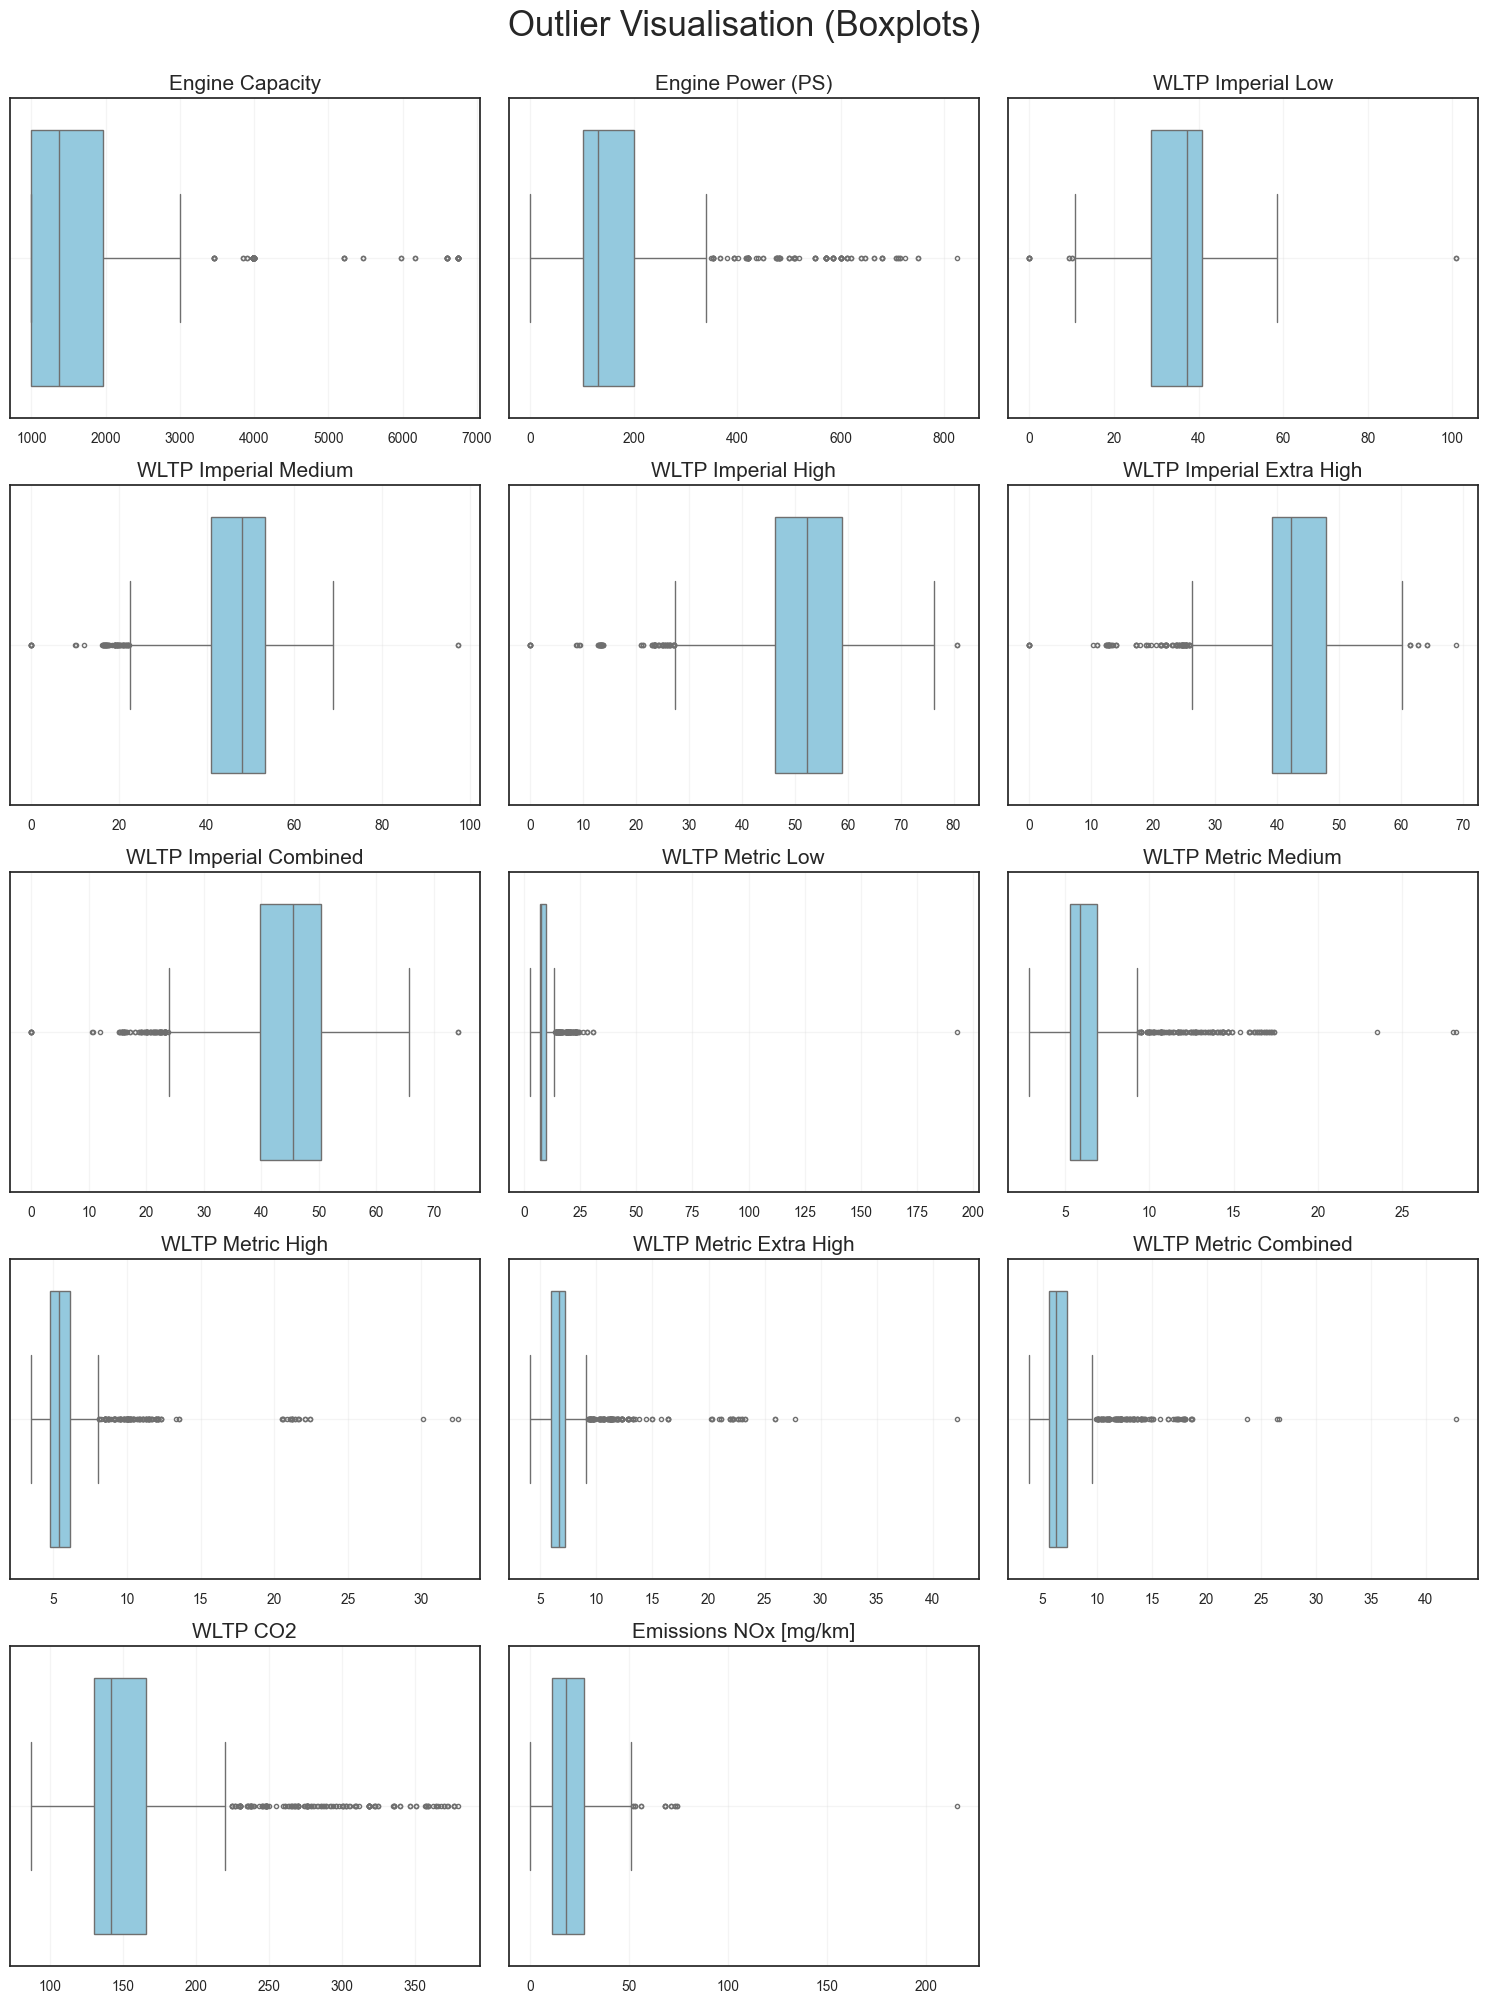

In [24]:
# A reusable function to visualise outliers, arguments: dataset
def outlier_check(data):
    # Select only numeric columns
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    
    if len(numeric_cols) == 0:
        print("No numeric columns found in the dataset.")
        return
    
    # Determine layout
    n_cols = 3
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    
    # Set up figure
    plt.figure(figsize=(n_cols * 5, n_rows * 4))
    plt.suptitle("Outlier Visualisation (Boxplots)", fontsize=25, y =1)
    
    # Create boxplots for each numeric column
    for idx, col in enumerate(numeric_cols, 1):
        plt.subplot(n_rows, n_cols, idx)
        sns.boxplot(x=data[col], color='skyblue', fliersize=3, linewidth=1)
        plt.title(col, fontsize=15)
        plt.xlabel("")
        plt.grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()

outlier_check(data_fuel)

In [25]:
removed_variables_fuel = [ "WLTP Metric Low", "WLTP Metric Medium",
                            "WLTP Metric High", "WLTP Metric Extra High",
                            "WLTP Metric Combined" ]

print(f"Data shape before removing columns: {data_fuel.shape}")

data_fuel = data_fuel.drop(columns=removed_variables_fuel)
print(f"Data shape after removing columns: {data_fuel.shape}")

Data shape before removing columns: (1233, 17)
Data shape after removing columns: (1233, 12)


Same for fuel vehicles, it seems to be a high outliers in WLTP Metric for hybrid vehicles. Therefore, these variables will be removed from hybrid vehicles dataset too. Here is the table showing the updated columns remain in _data_hybrid_. 

| Category  | Keep | Remove |
|-----------|------| ------ |
| Vehicle   |  Manual or Automatic, Engine Capacity, Fuel Type, Powertrain, Engine Power (PS) | Manufacturer, Model, Description, Transmission, Engine Power (Kw) |
| Fuel Consumption | WLTP Imperial Low, WLTP Imperial Medium, WLTP Imperial High, WLTP Imperial Extra High, WLTP Imperial Combined | Diesel VED Supplement, Testing Scheme, WLTP Metric Low, WLTP Metric Medium, WLTP Metric High, WLTP Metric Extra High, WLTP Metric Combined, WLTP Metric Combined (Weighted), WLTP Imperial Combined (Weighted) |
| Electric Consumption | |Electric energy consumption Miles/kWh, wh/km ,Maximum range (Km), Maximum range (Miles), Equivalent All Electric Range Miles, Equivalent All Electric Range KM, Electric Range City Miles, Electric Range City Km |
| Standard |  | Euro Standard | 
| Emmission | Emissions NOx [mg/km], WLTP CO2  | WLTP CO2 Weighted , THC Emissions [mg/km], THC + NOx Emissions [mg/km], Particulates [No.] [mg/km], RDE NOx Urban, RDE NOx Combined, Noise Level dB(A) |
| Date | | Date of change |

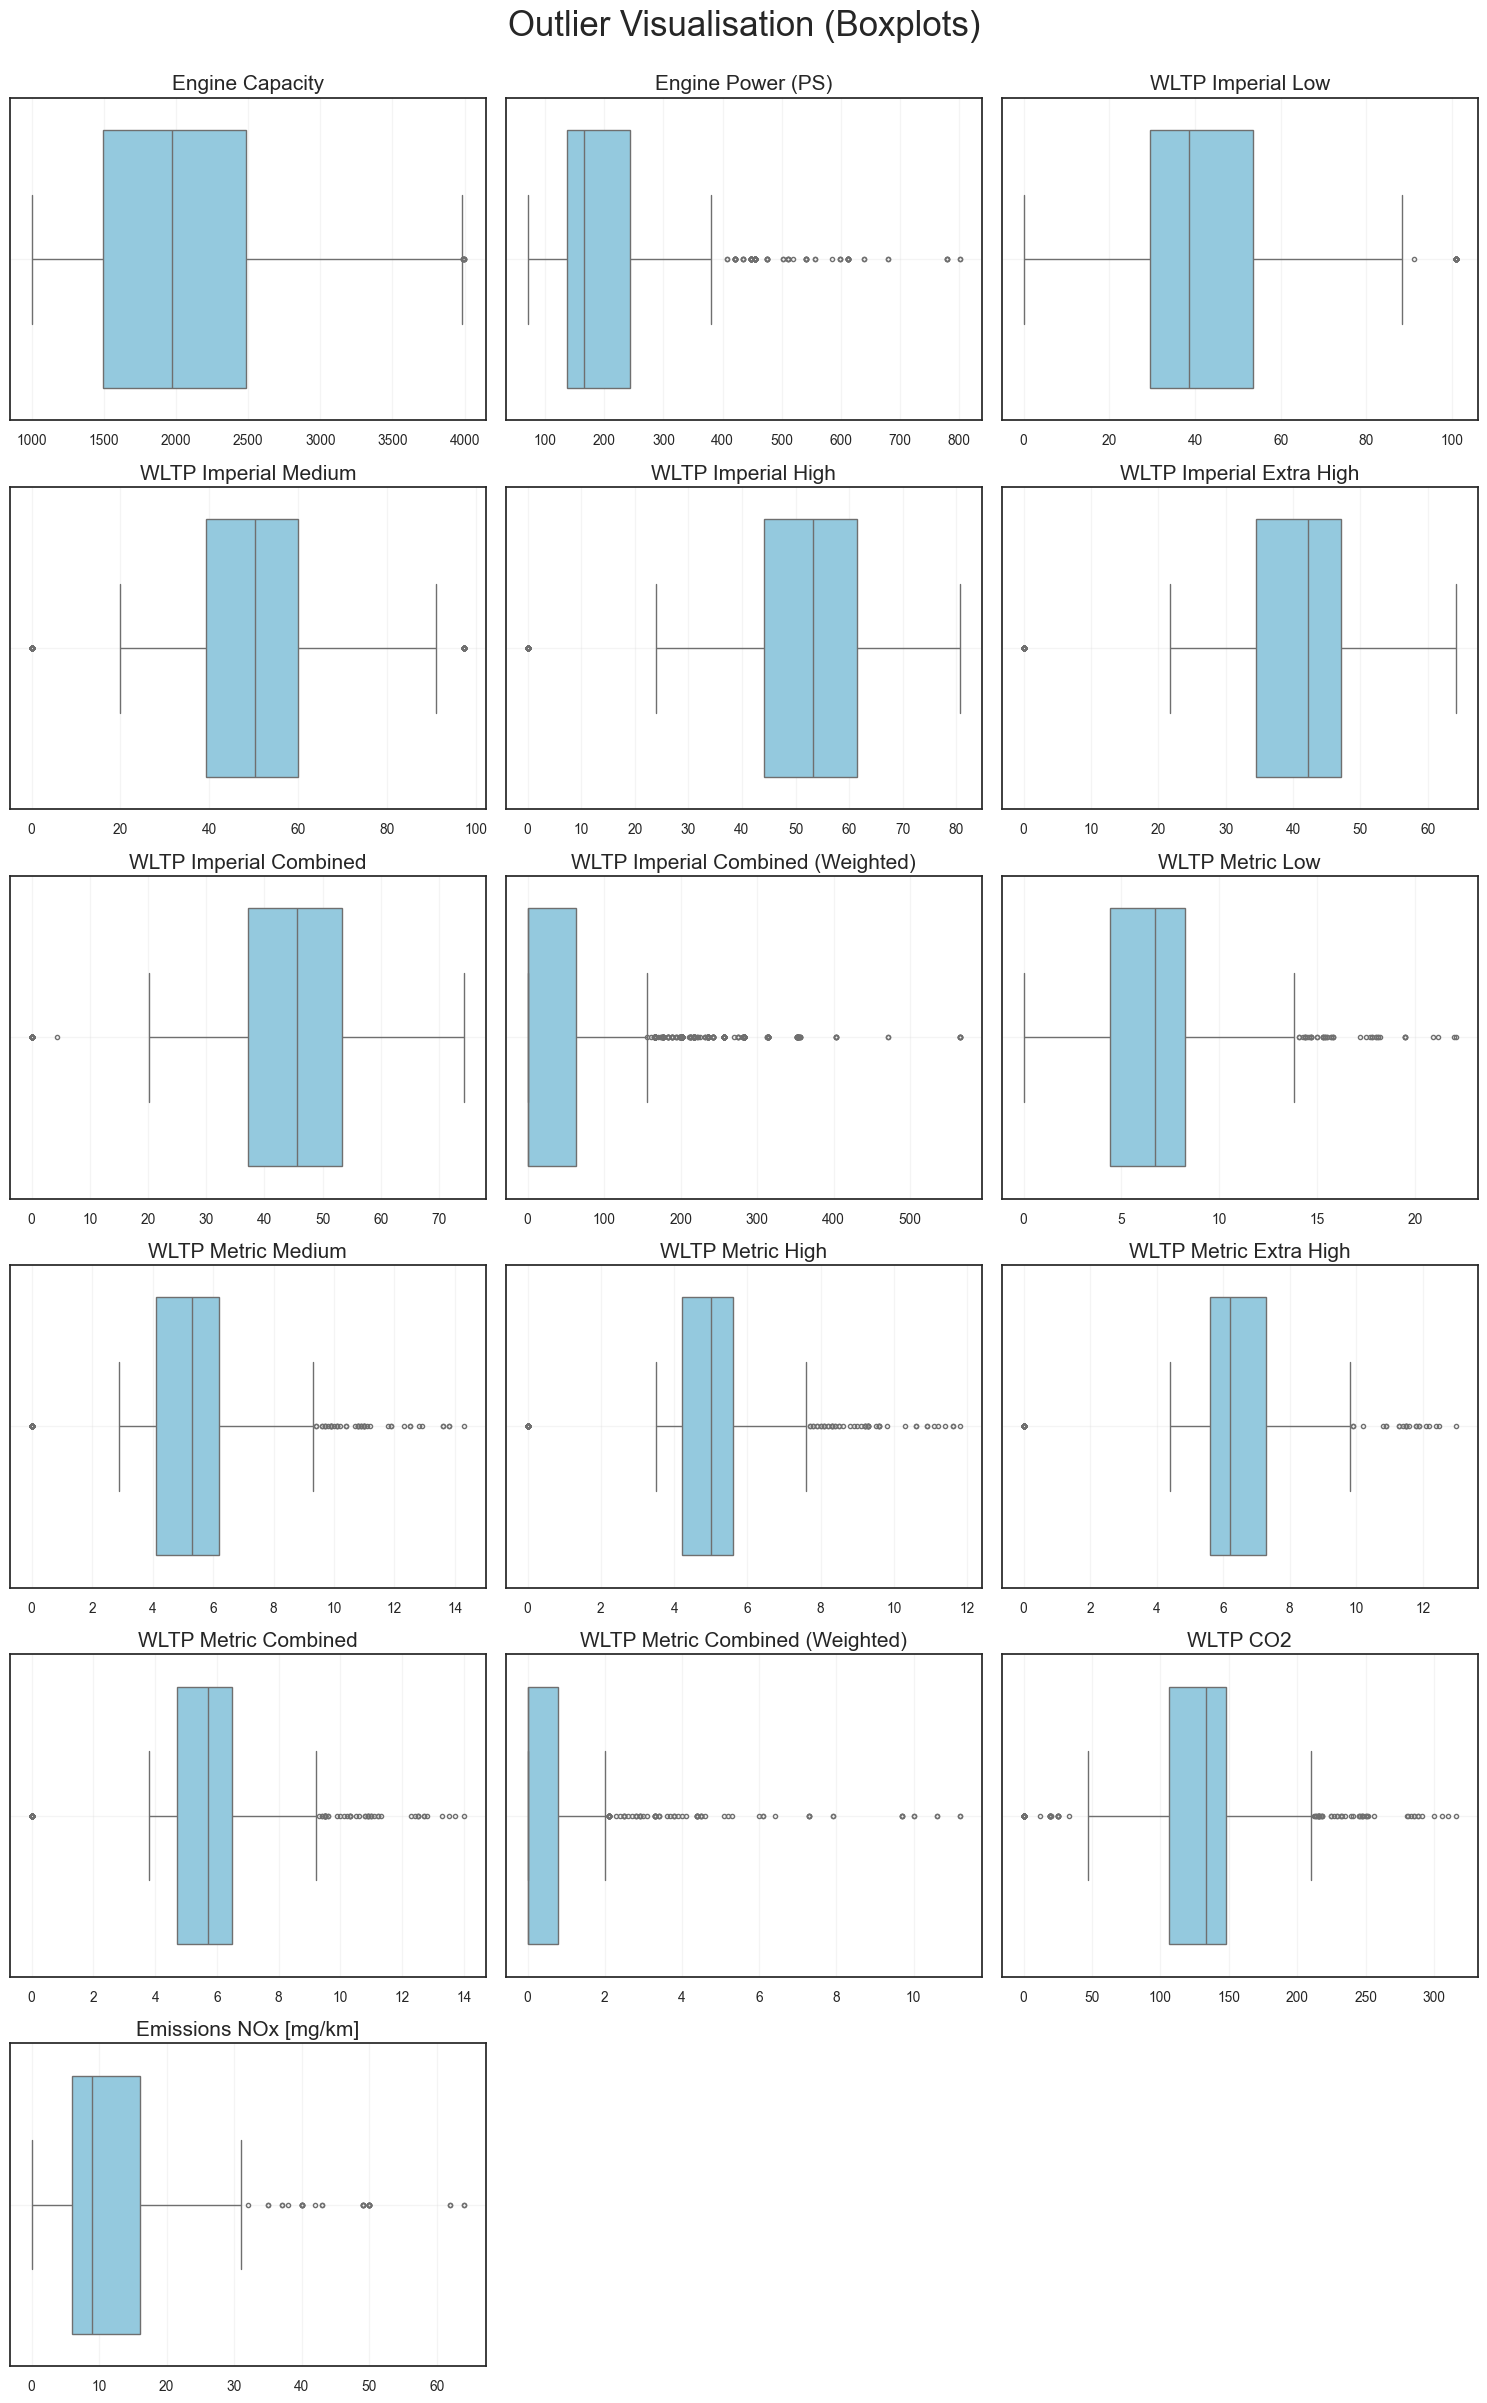

In [26]:
outlier_check(data_hybrid)

In [27]:
removed_variables_hybrid = [ "WLTP Metric Low", "WLTP Metric Medium",
                            "WLTP Metric High", "WLTP Metric Extra High",
                            "WLTP Metric Combined", "WLTP Metric Combined (Weighted)",
                            "WLTP Imperial Combined (Weighted)" ]

print(f"Data shape before removing columns: {data_hybrid.shape}")

data_hybrid = data_hybrid.drop(columns=removed_variables_hybrid)
print(f"Data shape after removing columns: {data_hybrid.shape}")

Data shape before removing columns: (1683, 19)
Data shape after removing columns: (1683, 12)


## Cross Validation
Now, we have the final model with all the features and target variables to train and test and model. Before we start the model, a _data_split_ function was created to split the _data_fuel_ and _data_hybrid_ into train, validate, and test datasets. The datasets were split into **80% for training, 10% for validations and 10% for testing**.

After splitting the data, we have created a function called _train_lasso_with_cv_ to use **Lasso** model for feature selection with a **10-fold** cross validations. Based on the results from Lasso model, we have designed to refine the Lasso model again with the best L1 regularisation strength (_alphas_). With the results from Lasso model, we can understand the errors using **mean squared error (MSE)** and variances by calculating the **r2_score** as well as listing the coefficient of each features. 

In [28]:
# Data Splitting Function into training set, test set, and validation set
np.random.seed(42) # for reproducibility

def data_split(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."
    
    # Split X/y
    X = data.drop(columns=[target])
    y = data[target]
    
    # Simple numeric imputation (if there are any remaining NaNs)
    # X = X.fillna(X.mean(numeric_only=True)).fillna(0)
    
    # 80 / 20 split, then 10 / 10 from the 20
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, 
                                                         random_state=random_state)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, 
                                                     random_state=random_state)
     
    # Encode categorical variables as dummy/one-hot columns
    X_train = pd.get_dummies(X_train, drop_first=True, dtype=float)
    X_val   = pd.get_dummies(X_val,   drop_first=True, dtype=float)
    X_test  = pd.get_dummies(X_test,  drop_first=True, dtype=float)

    #Re-index columns after encoding
    train_cols = X_train.columns
    X_val  = X_val.reindex(columns=train_cols, fill_value=0)
    X_test = X_test.reindex(columns=train_cols, fill_value=0)
    
    #Scaling the X data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return {
         "X_train": X_train,
         "X_val": X_val,
         "X_test": X_test,
         "y_train": y_train,
         "y_val": y_val,
         "y_test": y_test
    }     

#reuse this part to access the splitted data.
splits = data_split("WLTP CO2", data_fuel)

# Access the data 
X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]
y_val   = splits["y_val"]
y_test  = splits["y_test"]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(X_train[0:5,:])

(986, 13)
(124, 13)
(123, 13)
[[-0.69355105 -0.66468299  0.23878138  0.22261852  0.16192353  0.0135079
   0.15199583 -1.26703709 -0.96022252  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [ 3.44051473  3.98740879 -2.37420157 -2.1867223  -2.14748521 -2.05174708
  -2.26179734  0.2015991   1.04142527  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [-0.69355105 -0.50040367  0.59553551  0.43249142  0.31956235  0.087267
   0.29071957 -1.26703709  1.04142527  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [-0.20296869 -0.23158296 -0.03119472 -0.14675777 -0.18488188 -0.16562136
  -0.08845866 -1.26703709  1.04142527  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [-0.69453418 -0.81402783  1.51152584  1.47346097  1.34421469  0.86700613
   1.23404104 -0.62849962 -0.96022252  0.5139091  -0.19466571  0.12428995
  -0.11558867]]


In [29]:
# Residual diagnostics 
def plot_residual_diagnostics(y_true, y_pred, title_prefix: str, bins: int = 30):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=120)

    axes[0].scatter(y_pred, residuals, alpha=0.6, edgecolor="black", linewidth=0.3)
    axes[0].axhline(0, color="red", linewidth=1)
    axes[0].set_title(f"{title_prefix} - Residuals vs Prediction")
    axes[0].set_xlabel("Predicted value")
    axes[0].set_ylabel("Residual")
    axes[0].grid(alpha=0.3)

    axes[1].hist(residuals, bins=bins, color="steelblue", edgecolor="white")
    axes[1].set_title(f"{title_prefix} - Residual Distribution")
    axes[1].set_xlabel("Residual")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return residuals

In [30]:
# Ridge baseline comparison
def evaluate_ridge_baseline(target: str, data: pd.DataFrame, cv: int = 10, alphas=None):
    alphas = alphas or np.logspace(-3, 3, 20)

    splits = data_split(target=target, data=data, random_state=42)
    X_train = splits["X_train"]
    X_val = splits["X_val"]
    X_test = splits["X_test"]
    y_train = splits["y_train"]
    y_val = splits["y_val"]
    y_test = splits["y_test"]

    ridge = RidgeCV(alphas=alphas, cv=cv)
    ridge.fit(X_train, y_train)

    def metrics(y_true, y_pred):
        return {
            "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "r2": float(r2_score(y_true, y_pred)),
        }

    return {
        "model": ridge,
        "best_alpha": float(ridge.alpha_),
        "train": metrics(y_train, ridge.predict(X_train)),
        "val": metrics(y_val, ridge.predict(X_val)),
        "test": metrics(y_test, ridge.predict(X_test)),
    }


In [31]:
# Lasso CV train model
def train_lasso_with_cv(target: str,
                        data: pd.DataFrame,
                        random_state: int = 42, # follow same seed for reproducibility
                        alphas=None,
                        cv: int = 5,
                        refine: bool = True,
                        refine_span: float = 1.5,
                        refine_points: int = 15,
                        plot_diagnostics: bool = False):
    splits = data_split(target=target, data=data, random_state=random_state) #reuse data_split function

    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]

    # Coefficient check
    X_train_raw = data.loc[y_train.index].drop(columns=[target])
    feature_names = pd.get_dummies(X_train_raw, drop_first=True, dtype=float).columns
    if len(feature_names) != X_train.shape[1]:
        feature_names = pd.Index([f"feature_{i}" for i in range(X_train.shape[1])])

    lasso_cv = LassoCV(alphas=alphas, cv=cv, random_state=random_state)
    lasso_cv.fit(X_train, y_train)

    y_train_pred = lasso_cv.predict(X_train)
    y_val_pred   = lasso_cv.predict(X_val)
    y_test_pred  = lasso_cv.predict(X_test)

    def rmse(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

    def residual_summary(residuals):
        residuals = np.asarray(residuals)
        return {
            "mean": float(np.mean(residuals)),
            "std": float(np.std(residuals, ddof=1)),
            "min": float(np.min(residuals)),
            "max": float(np.max(residuals)),
        }

    residuals_train = y_train - y_train_pred
    residuals_val = y_val - y_val_pred
    residuals_test = y_test - y_test_pred

    if plot_diagnostics:
        plot_residual_diagnostics(y_val, y_val_pred, f"{target} (validation)")
        plot_residual_diagnostics(y_test, y_test_pred, f"{target} (test)")

    coef_series = pd.Series(lasso_cv.coef_, index=feature_names)
    nonzero_coefs = coef_series[coef_series != 0].sort_values(key=np.abs, ascending=False)

    results = {
        "model": lasso_cv,
        "best_alpha": lasso_cv.alpha_,
        "train_rmse": rmse(y_train, y_train_pred),
        "val_rmse": rmse(y_val, y_val_pred),
        "val_r2": r2_score(y_val, y_val_pred),
        "test_rmse": rmse(y_test, y_test_pred),
        "test_r2": r2_score(y_test, y_test_pred),
        "coefficients": nonzero_coefs,
        "diagnostics": {
            "train": residual_summary(residuals_train),
            "val": residual_summary(residuals_val),
            "test": residual_summary(residuals_test),
        },
    }
    # Refine the model by regularise with best alpha
    if refine and lasso_cv.alpha_ > 0:
        lower = max(lasso_cv.alpha_ / refine_span, 1e-6)
        upper = lasso_cv.alpha_ * refine_span
        alpha_grid = np.linspace(lower, upper, refine_points)
        alpha_grid = np.unique(alpha_grid)
        refined_cv = LassoCV(alphas=alpha_grid, cv=cv, random_state=random_state)
        refined_cv.fit(X_train, y_train)

        ref_val_pred  = refined_cv.predict(X_val)
        ref_test_pred = refined_cv.predict(X_test)

        results["refined_search"] = {
            "alphas": alpha_grid,
            "best_alpha": refined_cv.alpha_,
            "val_rmse": rmse(y_val, ref_val_pred),
            "val_r2": r2_score(y_val, ref_val_pred),
            "test_rmse": rmse(y_test, ref_test_pred),
            "test_r2": r2_score(y_test, ref_test_pred),
            "coefficients": pd.Series(refined_cv.coef_, index=feature_names)[
                refined_cv.coef_ != 0
            ].sort_values(key=np.abs, ascending=False),
            "diagnostics": {
                "val": residual_summary(y_val - ref_val_pred),
                "test": residual_summary(y_test - ref_test_pred),
            },
        }

        if plot_diagnostics:
            plot_residual_diagnostics(y_val, ref_val_pred, f"{target} (validation) - refined")
            plot_residual_diagnostics(y_test, ref_test_pred, f"{target} (test) - refined")

    return results

In [32]:
# Summarise the models lasso vs ridge
def summarise_models(label: str, lasso: dict, ridge: dict) -> pd.DataFrame:
    rows = []

    rows.append({
        "Label": label,
        "Variant": "Lasso",
        "Best α": lasso["best_alpha"],
        "Train RMSE": lasso["train_rmse"],
        "Val RMSE": lasso["val_rmse"],
        "Val R²": lasso["val_r2"],
        "Test RMSE": lasso["test_rmse"],
        "Test R²": lasso["test_r2"],
    })

    rows.append({
        "Label": label,
        "Variant": "Ridge",
        "Best α": ridge["best_alpha"],
        "Train RMSE": ridge["train"]["rmse"],
        "Val RMSE": ridge["val"]["rmse"],
        "Val R²": ridge["val"]["r2"],
        "Test RMSE": ridge["test"]["rmse"],
        "Test R²": ridge["test"]["r2"],
    })

    return pd.DataFrame(rows)

We have done the training for both datasets _data_fuel_ and _data_hybrid with the two target variables _WLTP CO2_ and _Emissions NOx [mg/km]_ that we have defined above. Below table is the results from the _lasso_ model training with _10-fold_ cross validation.

| Metric              | Fuel / CO2 (12 features) | Fuel / CO2 (3 features) | Fuel / NOx (12 features) | Fuel / NOx (3 features) | Hybrid / CO2 (12 features) | Hybrid / CO2 (3 features) | Hybrid / NOx (12 features) | Hybrid / NOx (3 features) |
|---------------------|------------------------|-----------------------|------------------------|-----------------------|--------------------------|-------------------------|--------------------------|-------------------------|
| Best alpha          | 0.054                  | 0.022                 | 0.022                  | 0.002                 | 0.103                    | 0.022                   | 0.004                    | 0.055                   |
| Train RMSE          | 197.082                | 2071.979              | 213.583                | 238.598               | 1359.811                 | 2071.979                | 45.390                   | 74.931                  |
| Validate RMSE       | 270.483                | 1912.145              | 1272.888               | 171.254               | 1044.115                 | 1912.145                | 71.701                   | 98.815                  |
| Validate R²         | 0.926                  | 0.055                 | -6.459                 | -0.003                | 0.484                    | 0.055                   | 0.279                    | 0.007                   |
| Test RMSE           | 247.201                | 2080.948              | 1172.173               | 149.236               | 1525.036                 | 2080.948                | 24.205                   | 45.544                  |
| Test R²             | 0.890                  | 0.251                 | 6.831                  | 0.002                 | 0.451                    | 0.251                   | 0.463                    | -0.009                  |

Based on the _alphas_ returned from first round of training, we have run the _lasso_ model again with following results.

| Metric (refined)    | Fuel / CO2 (12 features) | Fuel / CO2 (3 features) | Fuel / NOx (12 features) | Fuel / NOx (3 features) | Hybrid / CO2 (12 features) | Hybrid / CO2 (3 features) | Hybrid / NOx (12 features) | Hybrid / NOx (3 features) |
|---------------------|------------------------|-----------------------|------------------------|-----------------------|--------------------------|-------------------------|--------------------------|-------------------------|
| Validate RMSE       | 261.047                | 1912.280              | 1276.104               | 171.228               | 1043.926                 | 1912.280                | 71.691                   | 98.813                  |
| Validate R²         | 0.928                  | 0.055                 | -6.478                 | -0.003                | 0.484                    | 0.055                   | 0.279                    | 0.007                   |
| Test RMSE           | 236.887                | 2081.085              | 1175.241               | 149.221               | 1525.295                 | 2081.085                | 24.225                   | 45.544                  |
| Test R²             | 0.894                  | 0.251                 | -6.852                 | 0.003                 | 0.451                    | 0.251                   | 0.462                    | -0.009                  |

From the _lasso_ training, we found that the model with all the 12 features are working fine in both datasets for fuel and hybrid vehicle when we examine the correlation with CO2 and NOx. The errors have increased drastically after reduced to 3 features only. Eventhough the model for Fuel/NOx was strongly negative in validation R2, we are keeping the 12 features to standardised the features selection. We will consider an algorithm improvements in the future. 

Next, we have done a diagnostic using **residual/prediction scatter plot** to check the scalar metrics on the 12 features.

### Fuel / WLTP CO2
The result showing the residual scatter is tight, centered on zero, and roughly uniform across fitted values. The histogram is symmetric with light tails that matches the small residual mean and standard deviation (~0, 14) and strong validation R² (~0.93), so the model is well calibrated with no obvious bias or variances.

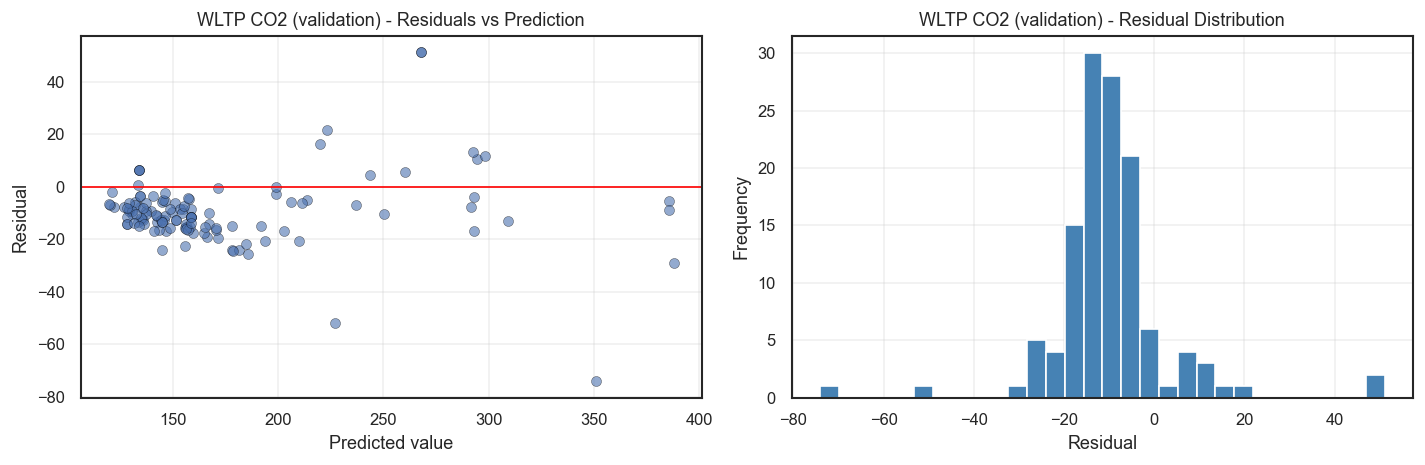

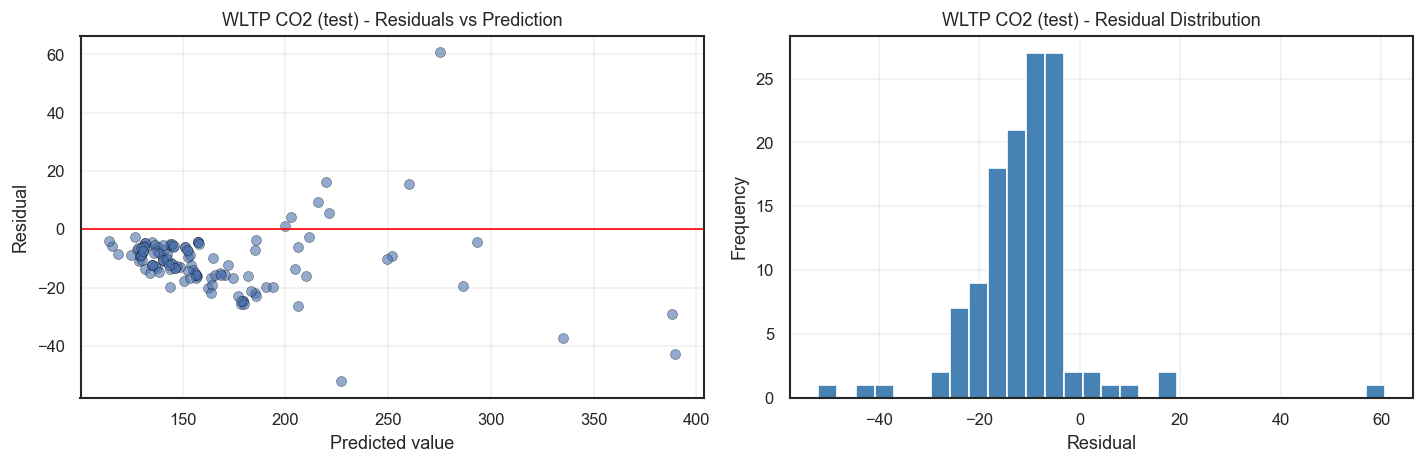

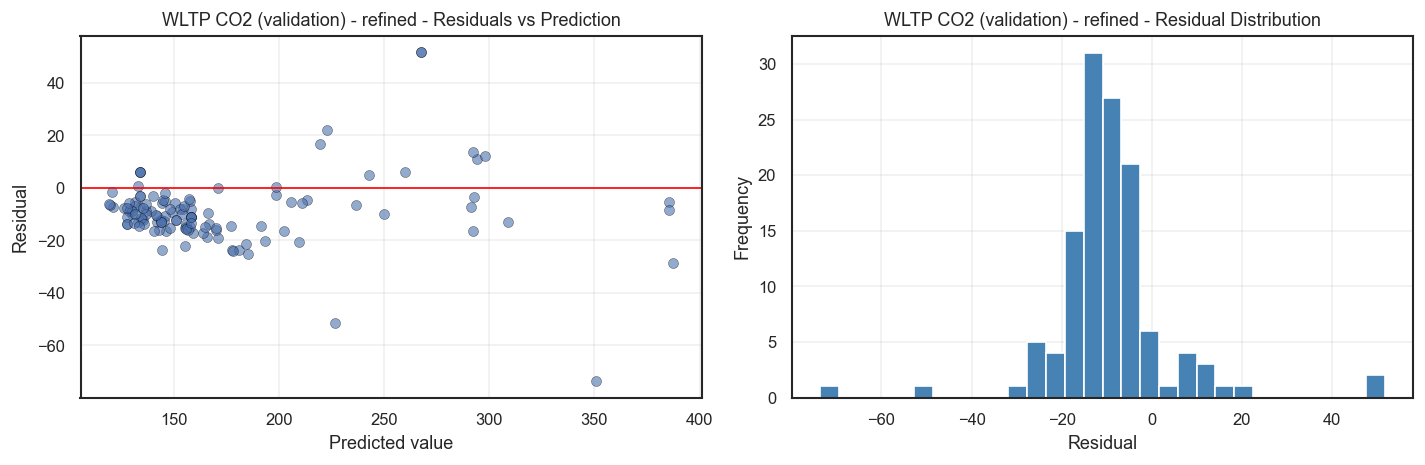

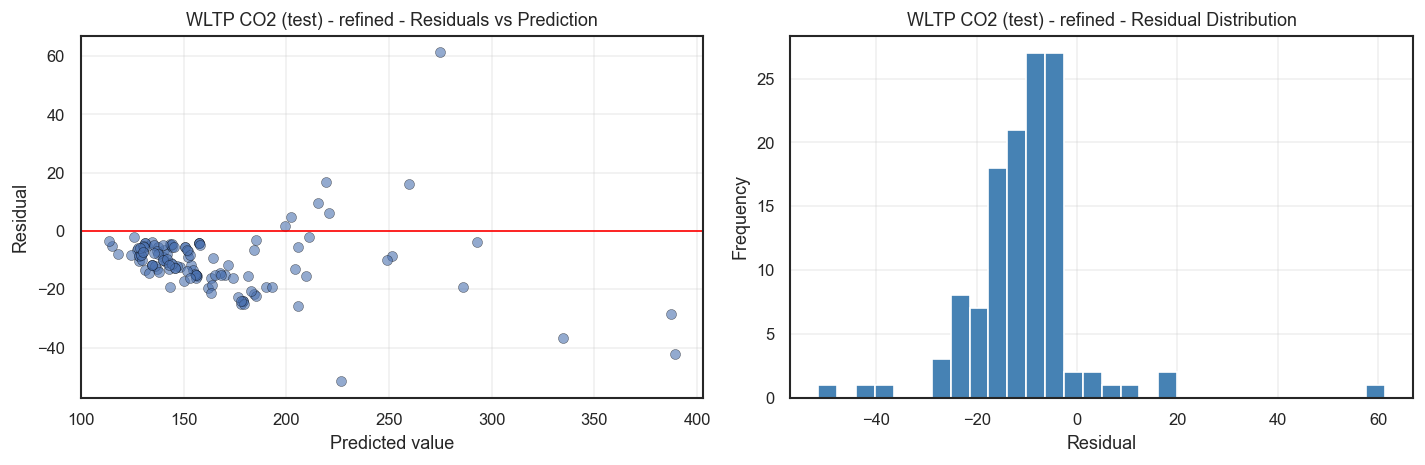

In [33]:
# Lasso for fuel/CO2
with warnings.catch_warnings():
   warnings.simplefilter("ignore")
   lasso_fuel_co2 = train_lasso_with_cv(target="WLTP CO2", data=data_fuel, cv=10, plot_diagnostics=True)
   lasso_fuel_co2
   
   ridge_fuel_co2 = evaluate_ridge_baseline(target="WLTP CO2", data=data_fuel, cv=10)
   ridge_fuel_co2

In [34]:
comparison_fuel_co2 = summarise_models(
    label="Fuel / WLTP CO2 (12 features)",
    lasso=lasso_fuel_co2,          # from the Lasso cell
    ridge=ridge_fuel_co2          # from the Ridge baseline cell
)
comparison_fuel_co2
display(Markdown(comparison_fuel_co2.to_markdown(index=False, floatfmt=".3f")))

| Label                         | Variant   |   Best α |   Train RMSE |   Val RMSE |   Val R² |   Test RMSE |   Test R² |
|:------------------------------|:----------|---------:|-------------:|-----------:|---------:|------------:|----------:|
| Fuel / WLTP CO2 (12 features) | Lasso     |    0.054 |       14.039 |     16.446 |    0.926 |      15.723 |     0.890 |
| Fuel / WLTP CO2 (12 features) | Ridge     |    2.976 |       13.994 |     24.107 |    0.840 |      24.144 |     0.740 |

In [35]:
# Lasso Fuel/CO2 - reduced features
target_col = "WLTP CO2"

# Create a copy of the data
features = data_fuel.copy()

# Keep only a subset of columns
keep_cols = ['Engine Capacity', 'Engine Power (PS)','WLTP Imperial Combined', target_col]
features = features[keep_cols]

# Train Lasso on the customised feature set
lasso_fuel_co2_reduced = train_lasso_with_cv(target=target_col, data=features, cv=10)
lasso_fuel_co2_reduced

# Ridge baseline comparison
ridge_fuel_co2_reduced = evaluate_ridge_baseline(target=target_col, data=features, cv=10)
ridge_fuel_co2_reduced

/Users/Hilary/Library/CloudStorage/OneDrive-WesternSydneyUniversity/COMP7023/GitHub/assignment-2-pa-25-group-7/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


{'model': RidgeCV(alphas=array([1.00000000e-03, 2.06913808e-03, 4.28133240e-03, 8.85866790e-03,
        1.83298071e-02, 3.79269019e-02, 7.84759970e-02, 1.62377674e-01,
        3.35981829e-01, 6.95192796e-01, 1.43844989e+00, 2.97635144e+00,
        6.15848211e+00, 1.27427499e+01, 2.63665090e+01, 5.45559478e+01,
        1.12883789e+02, 2.33572147e+02, 4.83293024e+02, 1.00000000e+03]),
         cv=10),
 'best_alpha': 2.976351441631316,
 'train': {'rmse': 14.787093445552427, 'r2': 0.9283276699594598},
 'val': {'rmse': 14.79008971601533, 'r2': 0.9399050847779963},
 'test': {'rmse': 13.342837429669107, 'r2': 0.9206312493385818}}

With the reduced 3-feature set, the result from _Lasso_ matches the result _Ridge_ model. That tells us the simplified feature gives lower error with less tuning sensitivity, it's the stronger feature-selection choice for fuel and CO2 mode.

In [36]:
comparison_fuel_co2_reduced = summarise_models(
    label="Fuel / WLTP CO2 (3 features)",
    lasso=lasso_fuel_co2_reduced,          # from the Lasso cell
    ridge=ridge_fuel_co2_reduced           # from the Ridge baseline cell
)
comparison_fuel_co2_reduced 
display(Markdown(comparison_fuel_co2_reduced.to_markdown(index=False, floatfmt=".3f")))

| Label                        | Variant   |   Best α |   Train RMSE |   Val RMSE |   Val R² |   Test RMSE |   Test R² |
|:-----------------------------|:----------|---------:|-------------:|-----------:|---------:|------------:|----------:|
| Fuel / WLTP CO2 (3 features) | Lasso     |    0.143 |       14.786 |     14.781 |    0.940 |      13.299 |     0.921 |
| Fuel / WLTP CO2 (3 features) | Ridge     |    2.976 |       14.787 |     14.790 |    0.940 |      13.343 |     0.921 |

### Fuel / NOx
In fuel / NOx model, the residuals are mostly located above zero. The model seems to be under-predicts high NOx readings, which is why validation/test R² plunge well below zero. The histogram’s heavy right tail confirms the bias and we might need to add more features or change a different model for fuel vehicles and NOx emission prediction.

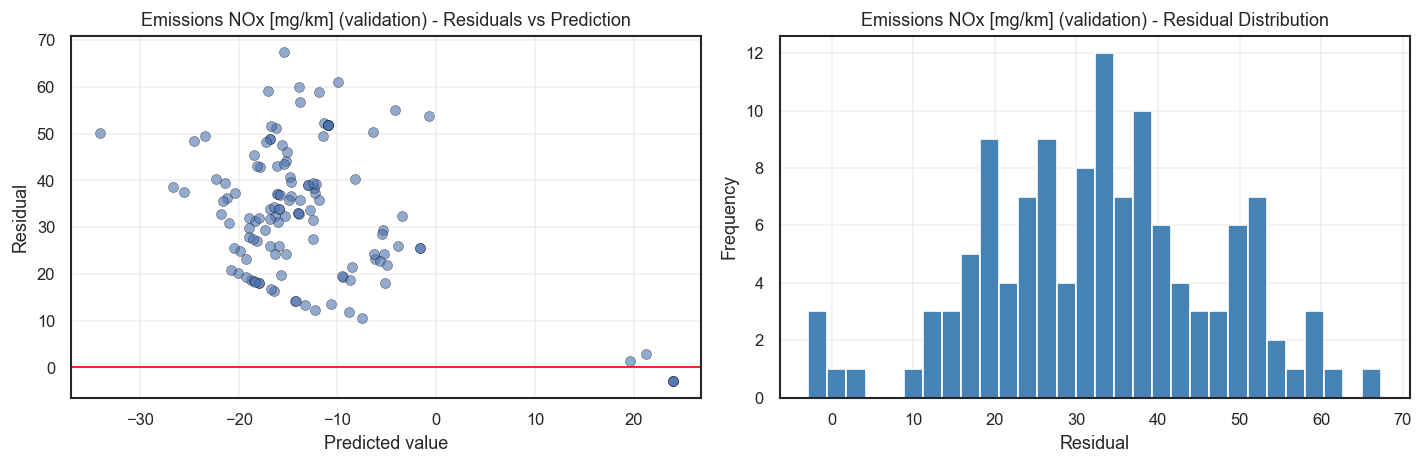

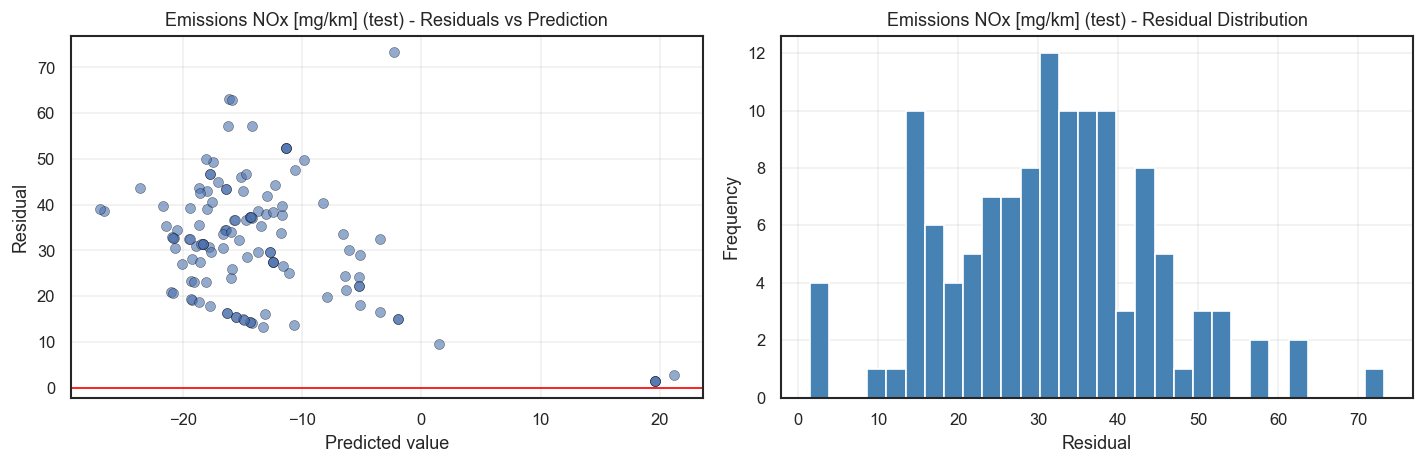

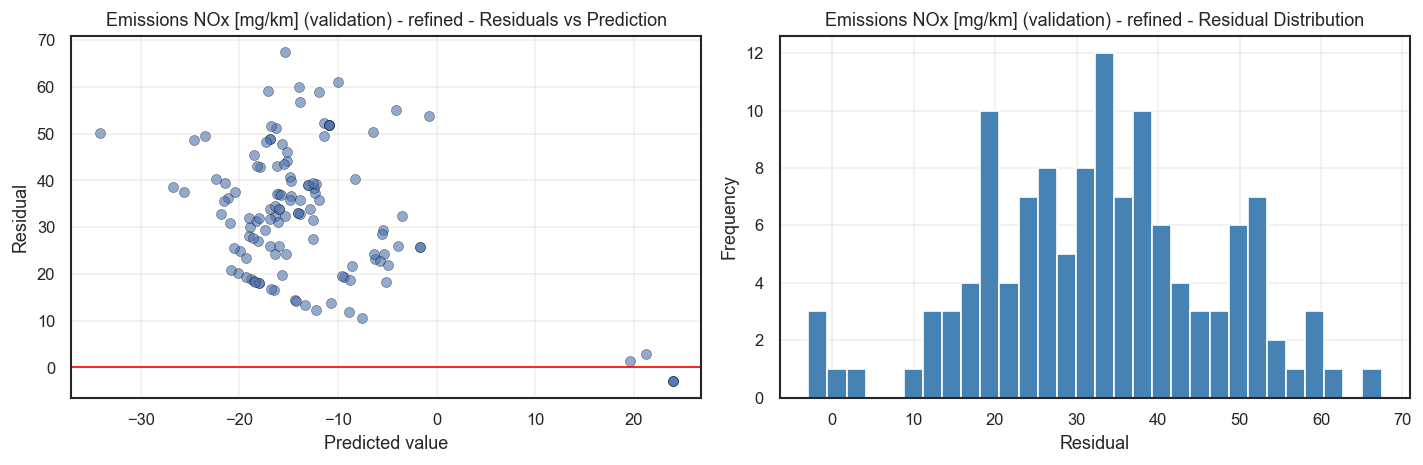

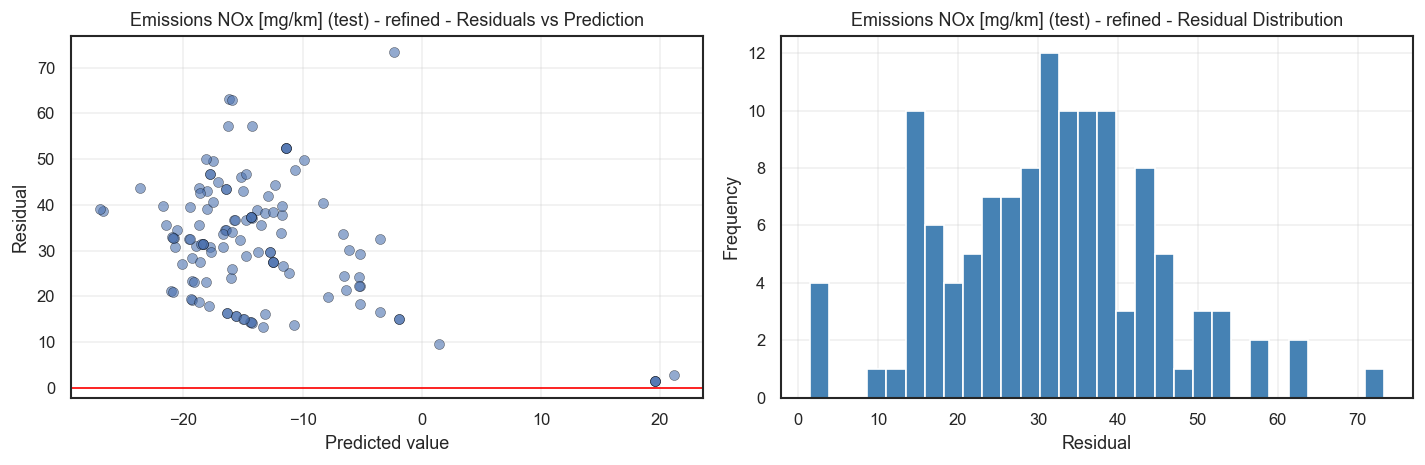

In [37]:
# Lasso for fuel/NOx
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lasso_fuel_nox = train_lasso_with_cv(target="Emissions NOx [mg/km]", data=data_fuel, cv=10, plot_diagnostics=True)
    lasso_fuel_nox

    ridge_fuel_nox = evaluate_ridge_baseline(target="Emissions NOx [mg/km]", data=data_fuel, cv=10)
    ridge_fuel_nox

Both results from _Lasso_ and _Ridge_ tells the 12-features models give negative value in R2 and RMSE jump to around 35.

In [38]:
comparison_fuel_nox = summarise_models(
    label="Fuel / NOx (12 features)",
    lasso=lasso_fuel_nox,          # from the Lasso cell
    ridge=ridge_fuel_nox           # from the Ridge baseline cell
)
comparison_fuel_nox
display(Markdown(comparison_fuel_nox.to_markdown(index=False, floatfmt=".3f")))

| Label                    | Variant   |   Best α |   Train RMSE |   Val RMSE |   Val R² |   Test RMSE |   Test R² |
|:-------------------------|:----------|---------:|-------------:|-----------:|---------:|------------:|----------:|
| Fuel / NOx (12 features) | Lasso     |    0.023 |       14.614 |     35.678 |   -6.460 |      34.237 |    -6.832 |
| Fuel / NOx (12 features) | Ridge     |    2.976 |       14.613 |     36.945 |   -6.999 |      35.501 |    -7.421 |

In [39]:
# Lasso Fuel/NOx - reduced features
target_col = "Emissions NOx [mg/km]"

# Create a copy of the data
features = data_fuel.copy()

# Keep only a subset of columns
keep_cols = ['Engine Capacity', 'Engine Power (PS)','WLTP Imperial Low', target_col]
features = features[keep_cols]

# Train Lasso on the customised feature set
lasso_fuel_nox_reduced = train_lasso_with_cv(target=target_col, data=features, cv=10)
lasso_fuel_nox_reduced

ridge_fuel_nox_reduced = evaluate_ridge_baseline(target=target_col, data=features, cv=10)
ridge_fuel_nox_reduced

/Users/Hilary/Library/CloudStorage/OneDrive-WesternSydneyUniversity/COMP7023/GitHub/assignment-2-pa-25-group-7/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


{'model': RidgeCV(alphas=array([1.00000000e-03, 2.06913808e-03, 4.28133240e-03, 8.85866790e-03,
        1.83298071e-02, 3.79269019e-02, 7.84759970e-02, 1.62377674e-01,
        3.35981829e-01, 6.95192796e-01, 1.43844989e+00, 2.97635144e+00,
        6.15848211e+00, 1.27427499e+01, 2.63665090e+01, 5.45559478e+01,
        1.12883789e+02, 2.33572147e+02, 4.83293024e+02, 1.00000000e+03]),
         cv=10),
 'best_alpha': 233.57214690901213,
 'train': {'rmse': 15.47937769319942, 'r2': 0.023033261014493323},
 'val': {'rmse': 12.928745354229006, 'r2': 0.020373187496034006},
 'test': {'rmse': 12.133108447683531, 'r2': 0.01643219594973233}}

Whereas in 3-features models for fuel / NOx is more stable with low RMSE but it is heavy regularised in _Ridge_ with a high _alpha_ at 234. In conclusion, the features we have selected do not fit well in fuel and NOx prediction. 

In [40]:
comparison_fuel_nox_reduced = summarise_models(
    label="Fuel / NOx (3 features)",
    lasso=lasso_fuel_nox_reduced ,          # from the Lasso cell
    ridge=ridge_fuel_nox_reduced           # from the Ridge baseline cell
)
comparison_fuel_nox_reduced 
display(Markdown(comparison_fuel_nox_reduced.to_markdown(index=False, floatfmt=".3f")))

| Label                   | Variant   |   Best α |   Train RMSE |   Val RMSE |   Val R² |   Test RMSE |   Test R² |
|:------------------------|:----------|---------:|-------------:|-----------:|---------:|------------:|----------:|
| Fuel / NOx (3 features) | Lasso     |    0.002 |       15.447 |     13.086 |   -0.004 |      12.216 |     0.003 |
| Fuel / NOx (3 features) | Ridge     |  233.572 |       15.479 |     12.929 |    0.020 |      12.133 |     0.016 |

### Hybrid / CO2
Residual cloud is symmetric but very wide (+/-140), showing high variance even though it remains centered. That matches RMSE ~32–39 and explains only ~45–48% of variance, we might consider adding more features or a nonlinear terms to lower down the variance.

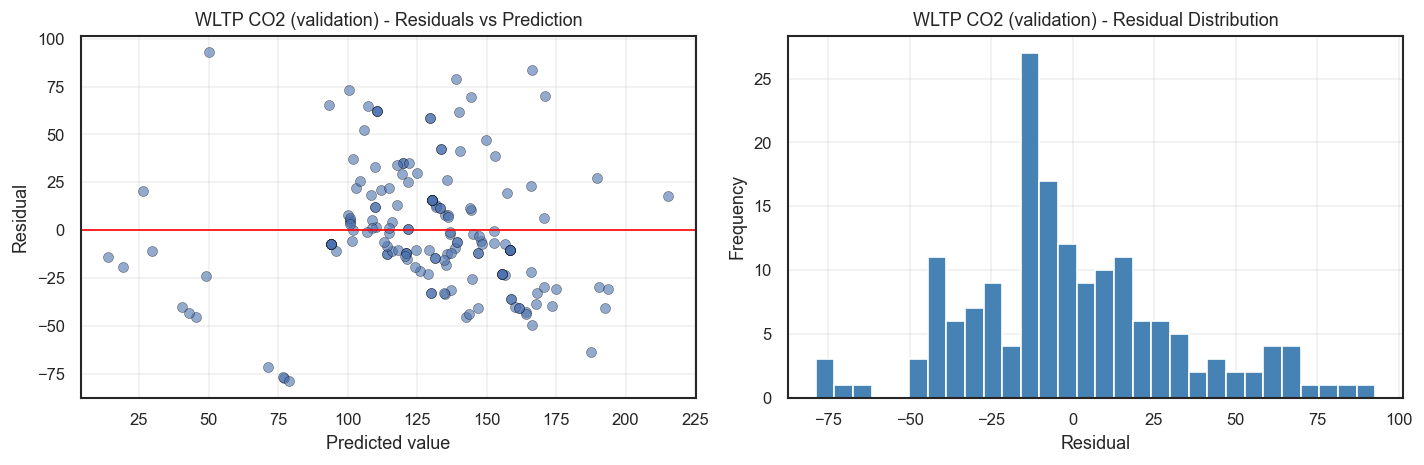

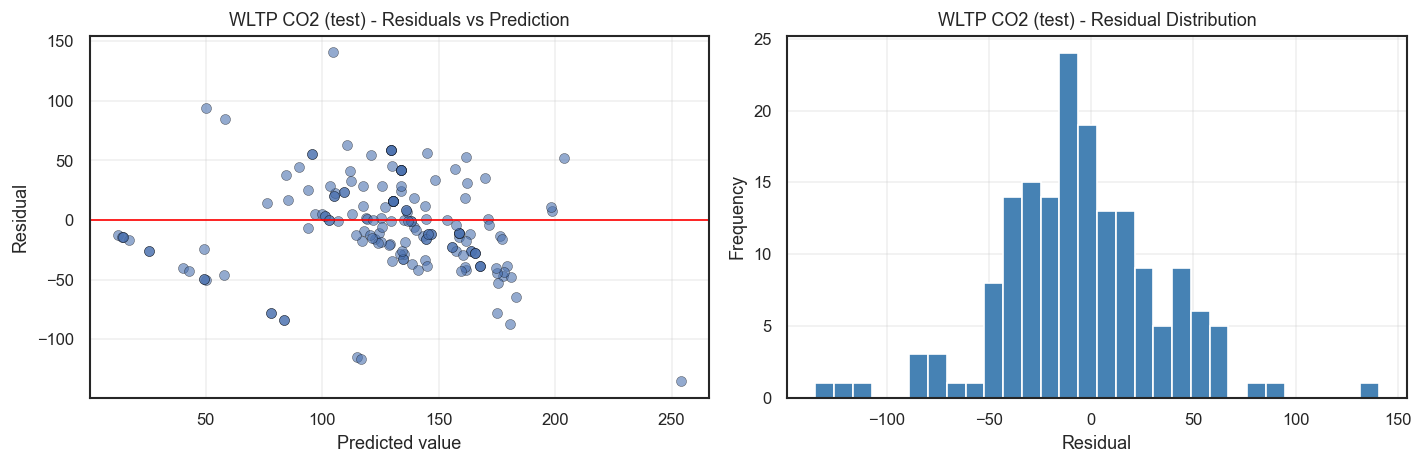

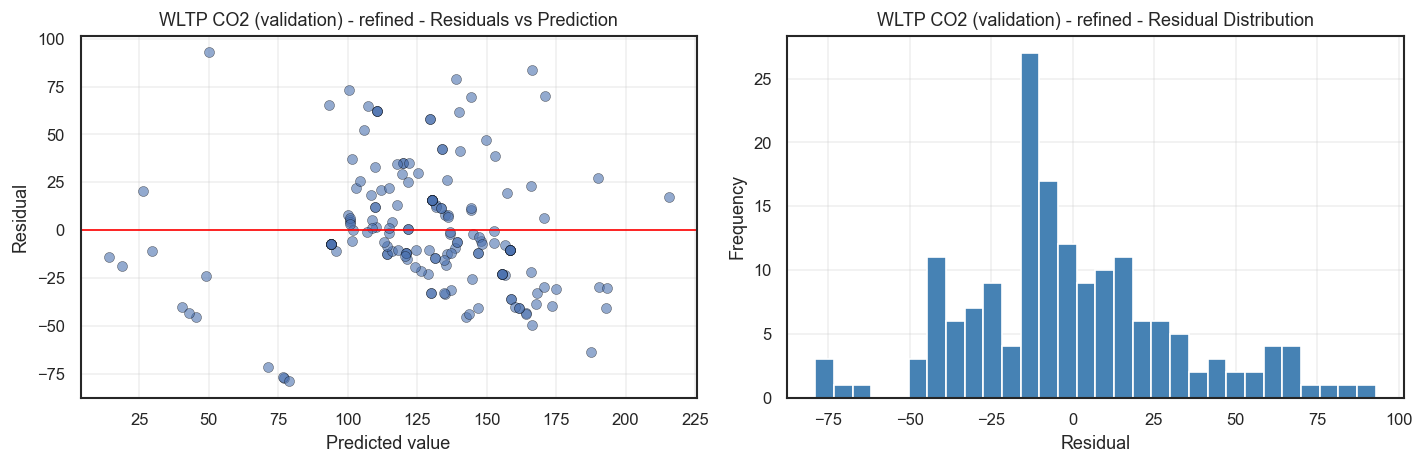

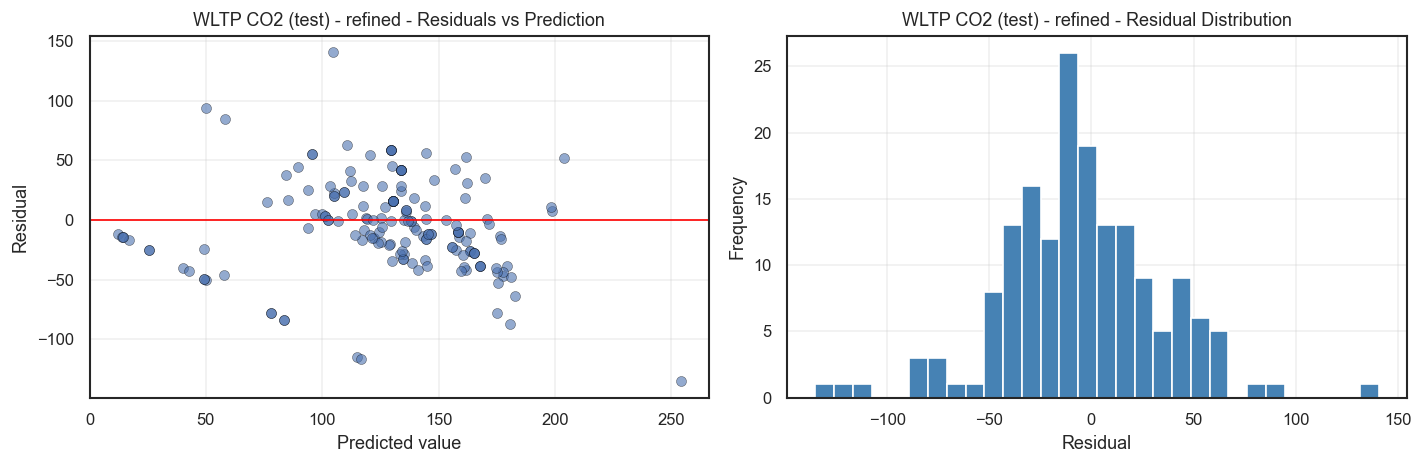

In [41]:
# Lasso for hybrid/CO2
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lasso_hybrid_co2 = train_lasso_with_cv(target="WLTP CO2", data=data_hybrid, cv=10, plot_diagnostics=True)
    lasso_hybrid_co2

    ridge_hybrid_co2 = evaluate_ridge_baseline(target="WLTP CO2", data=data_hybrid, cv=10)
    ridge_hybrid_co2

When comparing the 12-features set for hybrid / CO2 model, the results from _Lasso_ and _Ridge_ are about the same.

In [42]:
comparison_hybrid_co2 = summarise_models(
    label="Hybrid / CO2 (12 features)",
    lasso=lasso_hybrid_co2 ,          # from the Lasso cell
    ridge=ridge_hybrid_co2          # from the Ridge baseline cell
)
comparison_hybrid_co2
display(Markdown(comparison_hybrid_co2.to_markdown(index=False, floatfmt=".3f")))

| Label                      | Variant   |   Best α |   Train RMSE |   Val RMSE |   Val R² |   Test RMSE |   Test R² |
|:---------------------------|:----------|---------:|-------------:|-----------:|---------:|------------:|----------:|
| Hybrid / CO2 (12 features) | Lasso     |    0.103 |       36.876 |     32.313 |    0.484 |      39.052 |     0.451 |
| Hybrid / CO2 (12 features) | Ridge     |    6.158 |       36.881 |     32.256 |    0.486 |      39.147 |     0.448 |

In [43]:
# Lasso hybrid/CO2 - reduced features
target_col = "WLTP CO2"

# Create a copy of the data
features = data_hybrid.copy()

# Keep only a subset of columns
keep_cols = ['Engine Capacity', 'Engine Power (PS)','WLTP Imperial Combined', target_col]
features = features[keep_cols]

# Train Lasso on the customised feature set
lasso_hybrid_co2_reduced = train_lasso_with_cv(target=target_col, data=features, cv=10)
lasso_hybrid_co2_reduced

ridge_hybrid_co2_reduced = evaluate_ridge_baseline(target=target_col, data=features, cv=10)
ridge_hybrid_co2_reduced

/Users/Hilary/Library/CloudStorage/OneDrive-WesternSydneyUniversity/COMP7023/GitHub/assignment-2-pa-25-group-7/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


{'model': RidgeCV(alphas=array([1.00000000e-03, 2.06913808e-03, 4.28133240e-03, 8.85866790e-03,
        1.83298071e-02, 3.79269019e-02, 7.84759970e-02, 1.62377674e-01,
        3.35981829e-01, 6.95192796e-01, 1.43844989e+00, 2.97635144e+00,
        6.15848211e+00, 1.27427499e+01, 2.63665090e+01, 5.45559478e+01,
        1.12883789e+02, 2.33572147e+02, 4.83293024e+02, 1.00000000e+03]),
         cv=10),
 'best_alpha': 6.158482110660261,
 'train': {'rmse': 45.51972171617558, 'r2': 0.2933670179048333},
 'val': {'rmse': 43.69108481471854, 'r2': 0.056893531427233524},
 'test': {'rmse': 45.59517817579958, 'r2': 0.2516064092890754}}

When reducing to 3-features set, the accuracy has dropped sharply. Hence, we can conclude that 12-features set is a better model in predicting hybrid / CO2.

In [44]:
comparison_hybrid_co2_reduced = summarise_models(
    label="Hyrid / CO2 (3 features)",
    lasso=lasso_hybrid_co2_reduced ,          # from the Lasso cell
    ridge=ridge_hybrid_co2_reduced         # from the Ridge baseline cell
)
comparison_hybrid_co2_reduced
display(Markdown(comparison_hybrid_co2_reduced.to_markdown(index=False, floatfmt=".3f")))

| Label                    | Variant   |   Best α |   Train RMSE |   Val RMSE |   Val R² |   Test RMSE |   Test R² |
|:-------------------------|:----------|---------:|-------------:|-----------:|---------:|------------:|----------:|
| Hyrid / CO2 (3 features) | Lasso     |    0.022 |       45.519 |     43.728 |    0.055 |      45.617 |     0.251 |
| Hyrid / CO2 (3 features) | Ridge     |    6.158 |       45.520 |     43.691 |    0.057 |      45.595 |     0.252 |

### Hybrid / NOx
Residuals are compact, centered, and evenly spread, giving a clean plot with no obvious bias. Validation/test R2 around 0.28–0.46 confirm a solid fit.

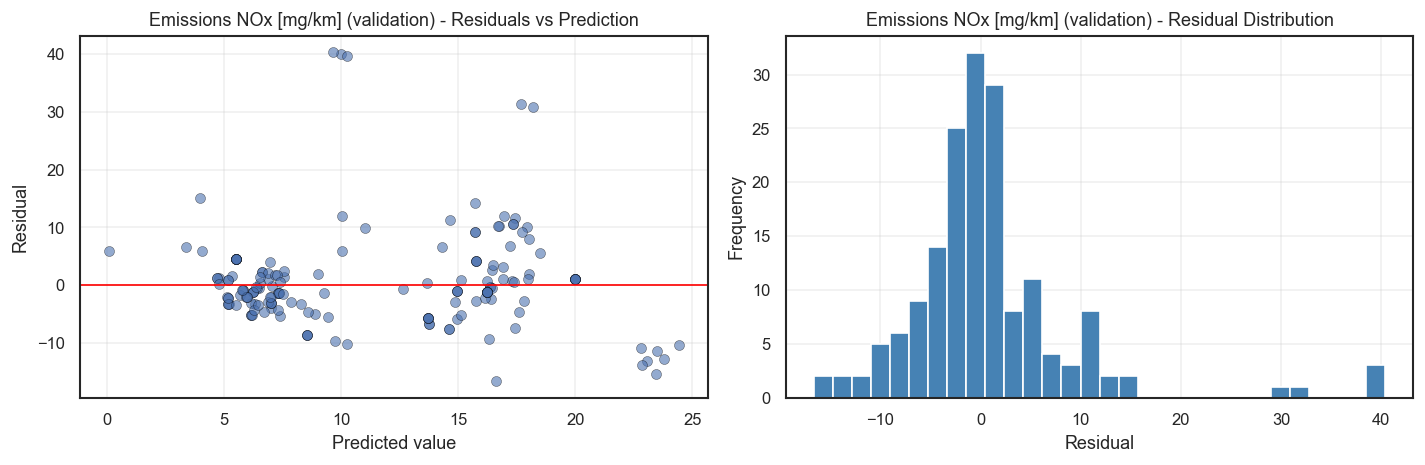

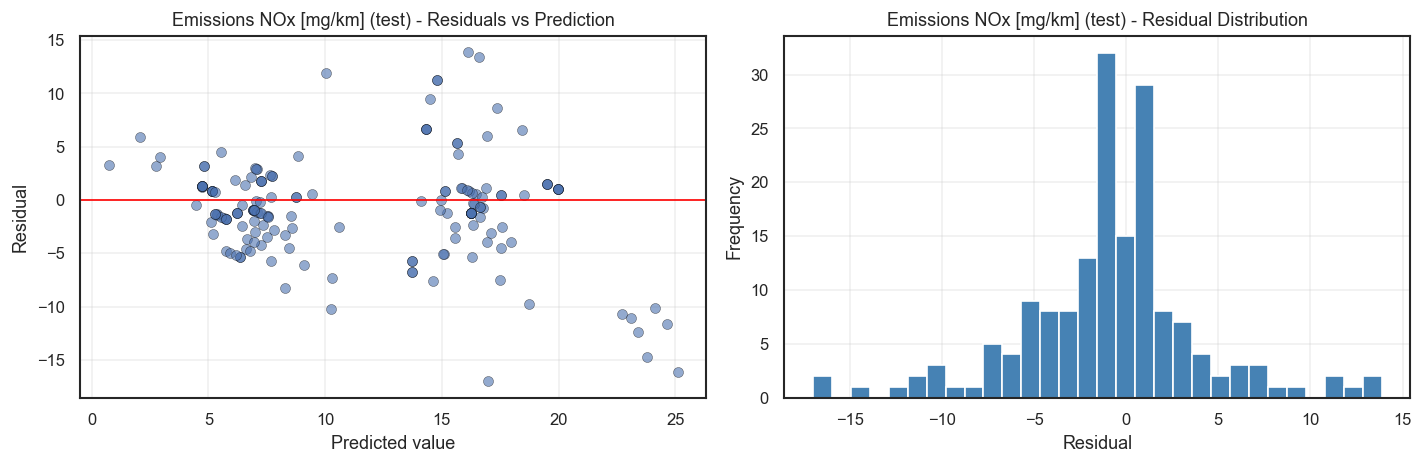

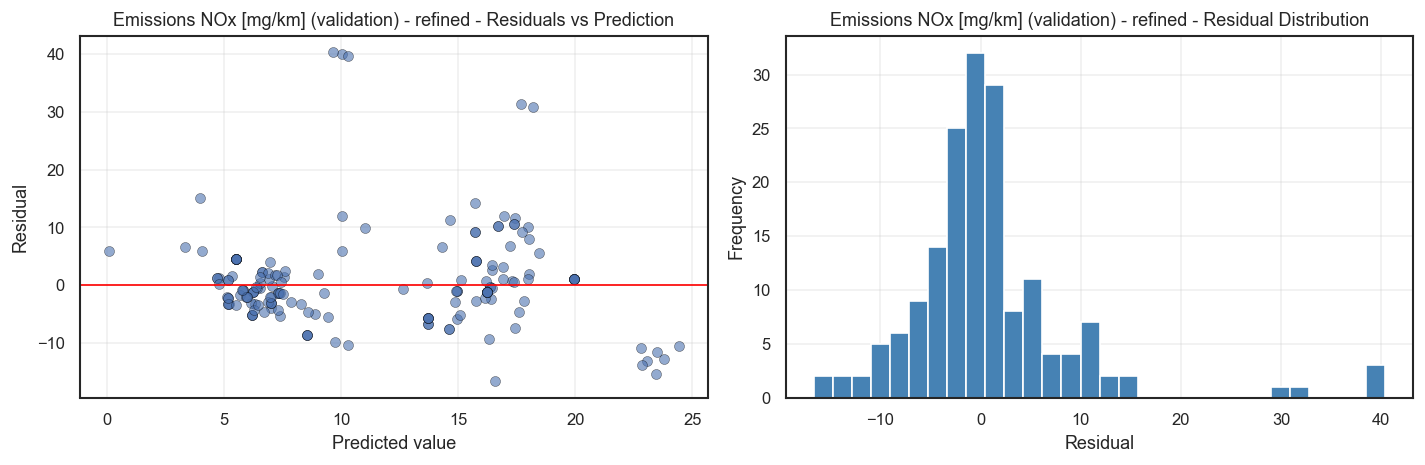

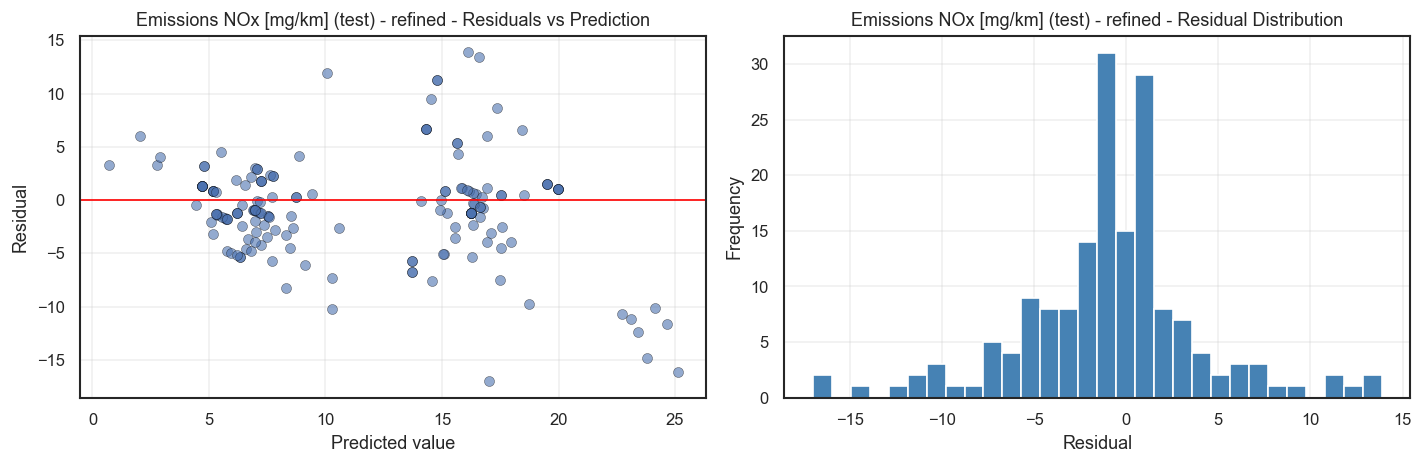

In [45]:
# Lasso for hybrid/NOx
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lasso_hybrid_nox = train_lasso_with_cv(target="Emissions NOx [mg/km]", data=data_hybrid, cv=10, plot_diagnostics=True)
    lasso_hybrid_nox

    ridge_hybrid_nox = evaluate_ridge_baseline(target="Emissions NOx [mg/km]", data=data_hybrid, cv=10)
    ridge_hybrid_nox

For hybrid / NOx prediction, the 12-features model are doing great in both validation and testing but the _Ridge_ model has chosen a high _alpha_ at 26.4 which could be due to the noisy target variables or small hybrid datasets.

In [46]:
comparison_hybrid_nox = summarise_models(
    label="Hyrid / NOx (12 features)",
    lasso=lasso_hybrid_nox ,          # from the Lasso cell
    ridge=ridge_hybrid_nox        # from the Ridge baseline cell
)
comparison_hybrid_nox
display(Markdown(comparison_hybrid_nox.to_markdown(index=False, floatfmt=".3f")))

| Label                     | Variant   |   Best α |   Train RMSE |   Val RMSE |   Val R² |   Test RMSE |   Test R² |
|:--------------------------|:----------|---------:|-------------:|-----------:|---------:|------------:|----------:|
| Hyrid / NOx (12 features) | Lasso     |    0.005 |        6.737 |      8.468 |    0.279 |       4.920 |     0.463 |
| Hyrid / NOx (12 features) | Ridge     |   26.367 |        6.752 |      8.481 |    0.277 |       4.805 |     0.488 |

In [47]:
# Lasso hybrid/NOx - reduced features
target_col = "Emissions NOx [mg/km]"

# Create a copy of the data
features = data_hybrid.copy()

# Keep only a subset of columns
keep_cols = ['Engine Capacity', 'Engine Power (PS)','WLTP Imperial Medium', target_col]
features = features[keep_cols]

# Train Lasso on the customised feature set
lasso_hybrid_nox_reduced = train_lasso_with_cv(target=target_col, data=features, cv=10)
lasso_hybrid_nox_reduced

ridge_hybrid_nox_reduced = evaluate_ridge_baseline(target=target_col, data=features, cv=10)
ridge_hybrid_nox_reduced

/Users/Hilary/Library/CloudStorage/OneDrive-WesternSydneyUniversity/COMP7023/GitHub/assignment-2-pa-25-group-7/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


{'model': RidgeCV(alphas=array([1.00000000e-03, 2.06913808e-03, 4.28133240e-03, 8.85866790e-03,
        1.83298071e-02, 3.79269019e-02, 7.84759970e-02, 1.62377674e-01,
        3.35981829e-01, 6.95192796e-01, 1.43844989e+00, 2.97635144e+00,
        6.15848211e+00, 1.27427499e+01, 2.63665090e+01, 5.45559478e+01,
        1.12883789e+02, 2.33572147e+02, 4.83293024e+02, 1.00000000e+03]),
         cv=10),
 'best_alpha': 1000.0,
 'train': {'rmse': 8.658466342818073, 'r2': 0.004039325368697777},
 'val': {'rmse': 9.967677799889934, 'r2': 0.001587953179250201},
 'test': {'rmse': 6.74563167961098, 'r2': -0.00906149842095516}}

The 3-features model for hybrid / NOx prediction has returned high errors in both _Lasso_ and _Ridge_ models. Hence, we will not consider this model. 

In [48]:
comparison_hybrid_nox_reduced = summarise_models(
    label="Hyrid / NOx (3 features)",
    lasso=lasso_hybrid_nox_reduced ,          # from the Lasso cell
    ridge=ridge_hybrid_nox_reduced       # from the Ridge baseline cell
)
comparison_hybrid_nox_reduced
display(Markdown(comparison_hybrid_nox_reduced.to_markdown(index=False, floatfmt=".3f")))

| Label                    | Variant   |   Best α |   Train RMSE |   Val RMSE |   Val R² |   Test RMSE |   Test R² |
|:-------------------------|:----------|---------:|-------------:|-----------:|---------:|------------:|----------:|
| Hyrid / NOx (3 features) | Lasso     |    0.056 |        8.656 |      9.941 |    0.007 |       6.749 |    -0.010 |
| Hyrid / NOx (3 features) | Ridge     | 1000.000 |        8.658 |      9.968 |    0.002 |       6.746 |    -0.009 |

Across the regularised experiments, 12-features model are performing better than 3-features model, with higher accuracy and less variants. The fuel/CO2 emerges as the most predictable target, follow by hybrid CO2 and NOx. Residual diagnostics therefore suggest targeted feature engineering or alternative models for the fuel/NOx task, where even the best configuration retains a biased right tail. 

# Neural Network - Regression Tasks

**Variables Selection:** All of the remaining variables after data preprocessing will be used for neural network regression models. Before bulding the models, examining the current features and data shape in the two datasets will be helpful to decide the relevant number of nodes in hidden layers, step size, and iterations.


In [49]:
#print current variables from the fuel cars dataset
print(data_fuel.columns)
print(data_fuel.shape)

Index(['Manual or Automatic', 'Engine Capacity', 'Fuel Type', 'Powertrain',
       'Engine Power (PS)', 'WLTP Imperial Low', 'WLTP Imperial Medium',
       'WLTP Imperial High', 'WLTP Imperial Extra High',
       'WLTP Imperial Combined', 'WLTP CO2', 'Emissions NOx [mg/km]'],
      dtype='object')
(1233, 12)


In [50]:
#print current variables from the hybrid cars dataset
print(data_hybrid.columns)
print(data_hybrid.shape)

Index(['Manual or Automatic', 'Engine Capacity', 'Fuel Type', 'Powertrain',
       'Engine Power (PS)', 'WLTP Imperial Low', 'WLTP Imperial Medium',
       'WLTP Imperial High', 'WLTP Imperial Extra High',
       'WLTP Imperial Combined', 'WLTP CO2', 'Emissions NOx [mg/km]'],
      dtype='object')
(1683, 12)


**Model Description**
As this is a regression task and both of target variables are numeric, hidden layers will be applied with ReLU - max(0,x) as activation method to keep gradients strong and captures nonlinearity. <br> 
The output layer will be applied with linear approach without activation to allow continuous outputs from the both gas emission types. <br>

**Parameters to train all the model:**
* Step size: 0.002. This is considered as relevant step size since the two datasets are small (< 5,000 rows). This step size also ensure sufficient learning for models when training. Small values lower than 0.0005 can cause overfitting for the models depending on current data scale.
* Iteration: 3,001 (). Since this is a small datatset, iteration times above 2,000 will be relevant for the model training. 
* Number of nodes in each layer: 10-60 nodes. Given the current features of two datasets are 12, the number of nodes for each hidden layer should range from 6 (0.5x numbers of features) to 60 (3x numbers of features) nodes.

## Neural Network Regression (2 Layers)

| Metric | Value |
| ------ | ----- |
| Training RMSE | 0.007827 |
| Coefficient of determination (R²) on training data | 1.000000 |
| Test RMSE | 69.798494 |
| Coefficient of determination (R²) on test data | -1.171900 |
| Validation RMSE | 72.883765 |
| Coefficient of determination (R²) on  validation data | -0.459300 |

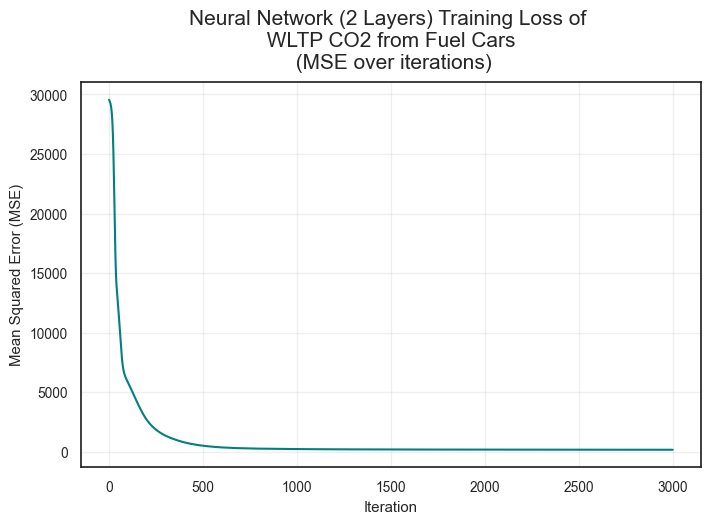

In [51]:
# Reusable function for Neural Network regression task - simple 1 hidden layer NN
def neural_network_regression(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    #reuse this part to access the splitted data.
    splits = data_split(target, data)

    # Access the data 
    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]

    # Flatten target arrays
    y_train = y_train.values.reshape(-1, 1)
    y_val   = y_val.values.reshape(-1, 1)
    y_test  = y_test.values.reshape(-1, 1)
    
    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train.shape[1] # number of features - 12
    D_out = 1 # number of outputs
    H = 60 # number of hidden neurons, based on number of features 2x or 3x

    # initiate the weights
    W0 = np.random.normal(0, 0.1, size=(D_in, H))
    W1 = np.random.normal(0, 0.1, size=(H, D_out))
    
    # GD training loop
    eta = 0.0002

    # set threshhold 
    min = -500
    max = 500

    loss_history = []
    for i in range(3001):
        # -- Forward Pass --
        ## Bias Terms
        b0 = np.zeros((1, H))
        b1 = np.zeros((1, 1))

        # Hidden Layer 1
        z1 = X_train.dot(W0) + b0
        z1 = np.clip(z1, min, max)
        a1 = np.maximum(0,z1)
        
        # Output Layer
        z2 = a1.dot(W1) + b1 # Linear output (no activation)
        y_pred = np.clip(z2, -1e3, 1e3)
        
        # Penalize large weights to stabilize learning
        Loss = np.sum((y_pred - y_train)**2)/N #+ 1e-4 * (np.sum(W0**2) + np.sum(W1**2)) 
        loss_history.append(float(Loss))


        # # print loss every 100 iterations
        # if i % 100 == 0:
        #     print(f"Iteration {i}: Loss {Loss:.4f}")
    
        # -- Backward Pass --
        # Derivative of Loss wrt output
        dy = 2.0 * (y_pred - y_train) / len(y_train)
        dW1 = a1.T.dot(dy)
        db1 = np.sum(dy, axis=0, keepdims=True)

        ## H1 to input
        da1 = dy.dot(W1.T)
        dz1 = da1 * (z1 > 0)
        dW0 = X_train.T.dot(dz1)
        db0 = np.sum(dz1, axis=0, keepdims=True)

        dW0 = X_train.T.dot(dz1)
        db0 = np.sum(dz1, axis=0, keepdims=True)
        
        
        # parameter updates (weights and bias)
        W0 -= eta * dW0 # weights update for features
        b0 -= eta * db0
        
        W1 -= eta * dW1
        b1 -= eta * db1


    # -- Evaluate --
    def predict(X):
        z1 = X.dot(W0)
        z1 = np.clip(z1, min, max)
        a1 = np.maximum(0,z1)
        return a1.dot(W1)

    y_train = predict(X_train)
    # MSE and RMSE on training data
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    train_r2 = round(r2_score(y_train, y_pred),4)
    # print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_pred)))
    # print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_pred),4))

    # Evaluate on test set
    y_test_pred = predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = round(r2_score(y_test, y_test_pred),4)
    # print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    # print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    y_val_pred = predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_r2 = round(r2_score(y_val, y_val_pred),4)
    # print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    # print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))

    rows = [
        ("Training RMSE", train_rmse),
        ("Coefficient of determination (R²) on training data", train_r2),
        ("Test RMSE", test_rmse),
        ("Coefficient of determination (R²) on test data", test_r2),
        ("Validation RMSE", val_rmse),
        ("Coefficient of determination (R²) on  validation data", val_r2),
    ]

    #convert into table in markdown
    table_md = ["| Metric | Value |", "| ------ | ----- |"]
    for label, value in rows:
        table_md.append(f"| {label} | {value:.6f} |")
    display(Markdown("\n".join(table_md)))


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network (2 Layers) Training Loss of \n {target} from {data_label} \n (MSE over iterations)",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()


# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression("WLTP CO2", data_fuel)

The neural network model (2 layers) used for predicting CO2 emissions from fuel cars seem to be overfitting due to high accuracy on training set but significantly low accuracy in both test and validation set. Therefore, this model will be removed. 

| Metric | Value |
| ------ | ----- |
| Training RMSE | 0.001051 |
| Coefficient of determination (R²) on training data | 1.000000 |
| Test RMSE | 14.862229 |
| Coefficient of determination (R²) on test data | -0.475800 |
| Validation RMSE | 16.466513 |
| Coefficient of determination (R²) on  validation data | -0.589100 |

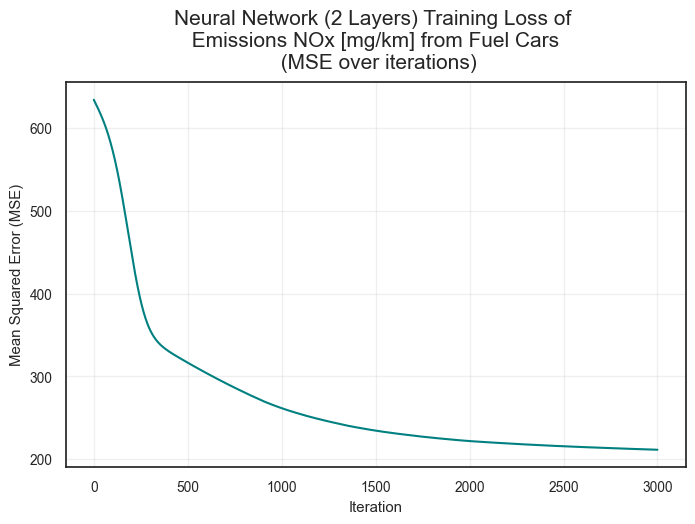

In [52]:
# Neural Network regression for fuel cars, target variable: Emissions NOx [mg/km]
neural_network_regression("Emissions NOx [mg/km]", data_fuel)

The neural network model (2 layers) used for predicting NOx emissions from fuel cars seem to be overfitting due to high accuracy on training set but significantly low accuracy in both test and validation set. Therefore, this model will be removed. 

| Metric | Value |
| ------ | ----- |
| Training RMSE | 0.004785 |
| Coefficient of determination (R²) on training data | 1.000000 |
| Test RMSE | 27.859055 |
| Coefficient of determination (R²) on test data | 0.720600 |
| Validation RMSE | 18.148563 |
| Coefficient of determination (R²) on  validation data | 0.837300 |

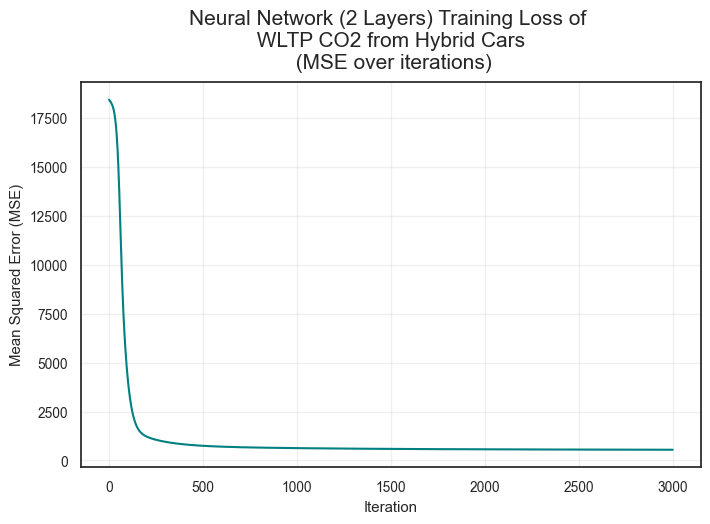

In [53]:
# Neural Network regression for hybrid cars, target variable: WLTP CO2
neural_network_regression("WLTP CO2", data_hybrid)

The neural network model (2 layers) used for predicting CO2 emissions from hybrid cars has lower gaps of accuracy and RMSE between training, and test and validation set. Thus, it can be a potential model for further evaluation as this stage.

| Metric | Value |
| ------ | ----- |
| Training RMSE | 0.000539 |
| Coefficient of determination (R²) on training data | 1.000000 |
| Test RMSE | 4.646769 |
| Coefficient of determination (R²) on test data | 0.521200 |
| Validation RMSE | 8.297508 |
| Coefficient of determination (R²) on  validation data | 0.308100 |

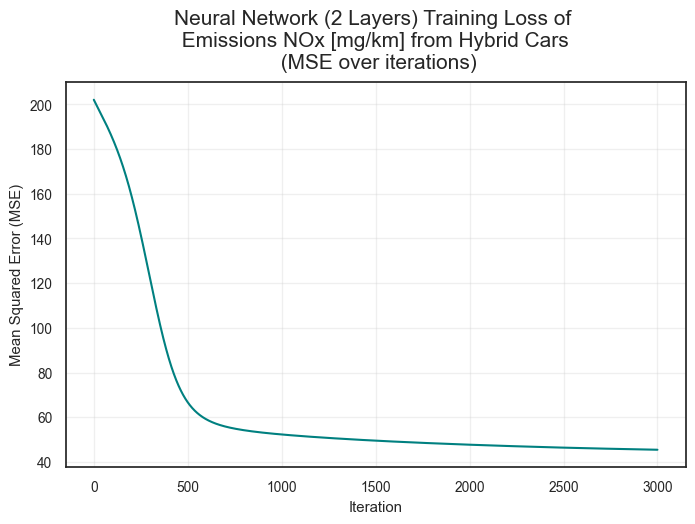

In [54]:
# Neural Network regression for hybrid cars, target variable: Emissions NOx [mg/km]
neural_network_regression("Emissions NOx [mg/km]", data_hybrid)

The neural network model (2 layers) used for predicting NOx emissions from hybrid cars seem to be overfitting due to high accuracy on training set but low accuracy in both test and validation set. Therefore, this model will be removed. 

**Findings:** 
Only 1 NN model can be selected at this stage which is for CO2 prediction of hybrid cars. <br>
Since the current models have only 2 layers which is quite simple, leading to biased results, other models should be built with 1 more layer for comprehensive comparisons and selection, leading to Neural Network Regression (3 Layers).

## Neural Network Regression - 3 Layers

In order to to achieve relevant model comparison, all of the current parameters in step size, and iterations will be kept. <br>
The first layer still have 60 nodes similar to the previous models. However, the second layer will have 30 nodes. 

| Metric | Value |
| ------ | ----- |
| Training RMSE | 5.726886 |
| Coefficient of determination (R²) on training data | 0.989200 |
| Test RMSE | 61.253981 |
| Coefficient of determination (R²) on test data | -0.672700 |
| Validation RMSE | 61.625088 |
| Coefficient of determination (R²) on  validation data | -0.043300 |

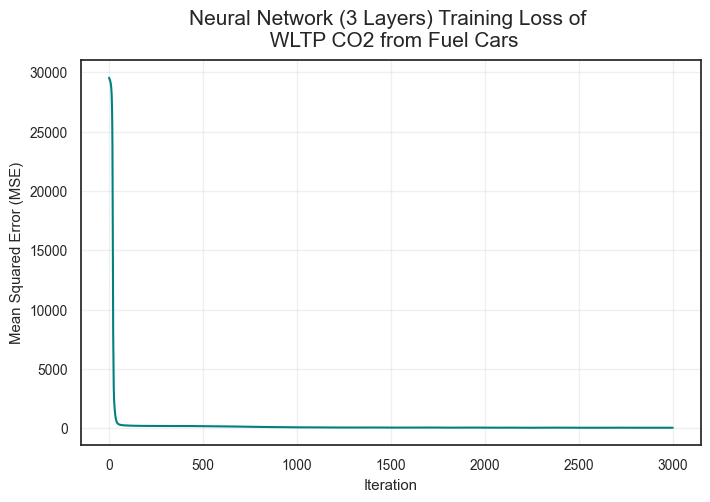

In [55]:
# Reusable function for Neural Network regression task - 2 hidden layer NN
def neural_network_regression_2hidden(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    splits = data_split(target, data)

    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]   
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]      

    # Flatten target arrays
    y_train = y_train.values.reshape(-1, 1)
    y_val   = y_val.values.reshape(-1, 1)
    y_test  = y_test.values.reshape(-1, 1)
    
    # Threshold for np.clip
    min = -500 
    max = 500
       
    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train.shape[1] # number of features
    D_out = 1 # number of outputs
    H1 = 60 # number of hidden neurons in hidden layer 1
    H2 = 30 # number of hidden neurons in hidden layer 2
    
    np.random.seed(42) # for reproducibility

    # -- Initialize weights
    # Layer 1: input -> hidden1
    W0 = normal(0, 0.1, size=(D_in, H1))
    b0 = np.zeros((1, H1))

    # Layer 2: hidden1 -> hidden2
    W1 = normal(0, 0.1, size=(H1, H2))
    b1 = np.zeros((1, H2))

    # Output: hidden2 -> output
    W2 = normal(0, 0.1, size=(H2, D_out))
    b2 = np.zeros((1, D_out))
    
    # Training loop
    eta = 0.0002

    loss_history = []
    for i in range(3001):
        # ---- forward pass ----
        ## Layer 1
        z1 = X_train.dot(W0) + b0
        z1 = np.clip(z1, min, max) 
        a1 = np.maximum(0,z1) # simple ReLU, no activation for all

        # Layer 2
        z2 = a1.dot(W1) + b1
        z2 = np.clip(z2, min, max)
        a2 = np.maximum(0,z2) 

        # Output (linear)
        z3 = a2.dot(W2) + b2
        y_pred = np.clip(z3, -1e3, 1e3)

        # Loss (MSE)
        Loss = np.mean((y_pred - y_train) ** 2)
        loss_history.append(float(Loss))

        # ---- backward pass ----
        # dLoss/dy_hat = 2*(y_pred - y) / N
        dy = (2.0 / N) * (y_pred - y_train)

        # Gradients for output layer (a2 -> y_pred)
        dW2 = a2.T.dot(dy)     
        db2 = np.sum(dy, axis=0, keepdims=True) 

        # Backprop into hidden2
        da2 = dy.dot(W2.T)                        
        dz2 = da2 * (z2 >0)               
        dW1 = a1.T.dot(dz2)                       
        db1 = np.sum(dz2, axis=0, keepdims=True)  

        # Backprop into hidden1
        da1 = dz2.dot(W1.T)                       
        dz1 = da1 * (z1>0)              
        dW0 = X_train.T.dot(dz1)           
        db0 = np.sum(dz1, axis=0, keepdims=True) 

        # ---- update parameters ----
        W2 -= eta * dW2
        b2 -= eta * db2
        
        W1 -= eta * dW1
        b1 -= eta * db1
        
        W0 -= eta * dW0
        b0 -= eta * db0

    
    # -- Evaluate --
    def predict(X):    
        z1_ = X.dot(W0) + b0
        z1_ = np.clip(z1_, min, max)
        a1_ = np.maximum(0, z1_)
        
        z2_ = a1_.dot(W1) + b1
        z2_ = np.clip(z2_, min, max)
        a2_ = np.maximum(0, z2_)
        
        return a2_.dot(W2) + b2

    # MSE and RMSE on training data
    y_pred = predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    train_r2 = round(r2_score(y_train, y_pred),4)
    #print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_pred)))
    #print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_pred),4))

    # Evaluate on test set
    y_test_pred = predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = round(r2_score(y_test, y_test_pred),4)
    #print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    #print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    y_val_pred = predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_r2 = round(r2_score(y_val, y_val_pred),4)
    #print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    #print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))

    rows = [
        ("Training RMSE", train_rmse),
        ("Coefficient of determination (R²) on training data", train_r2),
        ("Test RMSE", test_rmse),
        ("Coefficient of determination (R²) on test data", test_r2),
        ("Validation RMSE", val_rmse),
        ("Coefficient of determination (R²) on  validation data", val_r2),
    ]

    #convert into table in markdown
    table_md = ["| Metric | Value |", "| ------ | ----- |"]
    for label, value in rows:
        table_md.append(f"| {label} | {value:.6f} |")
    display(Markdown("\n".join(table_md)))

    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"

    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network (3 Layers) Training Loss of \n {target} from {data_label}",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0
    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression_2hidden("WLTP CO2", data_fuel)

The neural network model (3 layers) used for predicting CO2 emissions from fuel cars seem to be overfitting again due to high accuracy on training set but significantly low accuracy in both test and validation set. Therefore, this model will be removed. 

| Metric | Value |
| ------ | ----- |
| Training RMSE | 14.015439 |
| Coefficient of determination (R²) on training data | 0.199100 |
| Test RMSE | 16.430206 |
| Coefficient of determination (R²) on test data | -0.803600 |
| Validation RMSE | 18.211237 |
| Coefficient of determination (R²) on  validation data | -0.943700 |

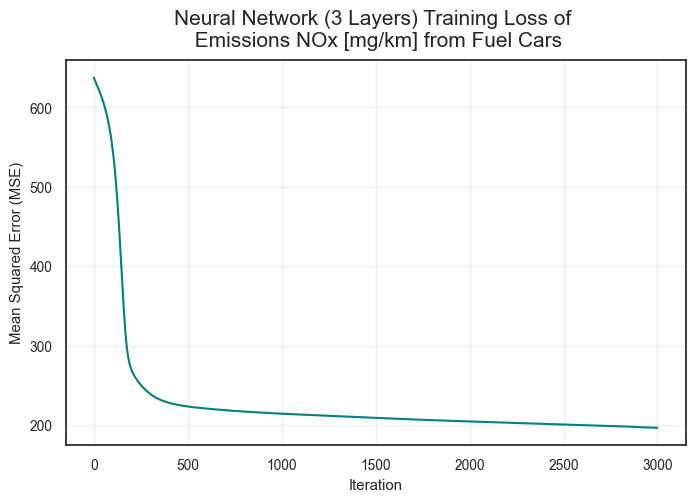

In [56]:
# NN Regression (2 hidden layers), Emissions NOx from Fuel cars
neural_network_regression_2hidden("Emissions NOx [mg/km]", data_fuel)

The neural network model (3 layers) used for predicting NOx emissions from fuel cars seem to be overfitting again due to high accuracy on training set but significantly low accuracy in both test and validation set. Therefore, this model will be removed. 

| Metric | Value |
| ------ | ----- |
| Training RMSE | 16.844756 |
| Coefficient of determination (R²) on training data | 0.903200 |
| Test RMSE | 16.965880 |
| Coefficient of determination (R²) on test data | 0.896400 |
| Validation RMSE | 11.594324 |
| Coefficient of determination (R²) on  validation data | 0.933600 |

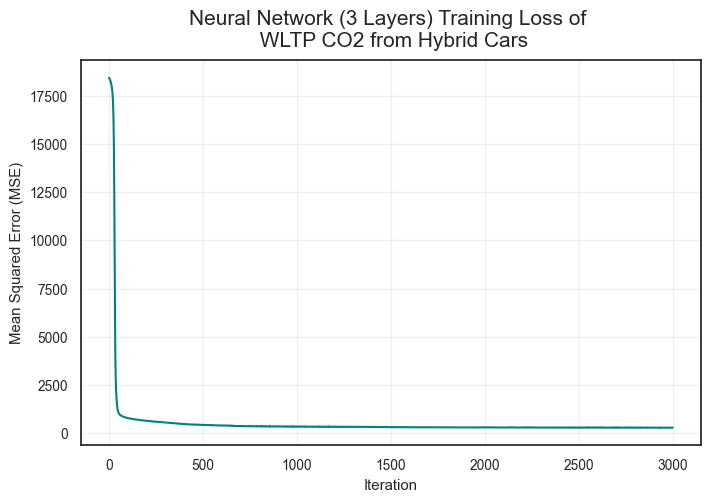

In [57]:
# NN Regression (2 hidden layers), CO2 emissions from Hybrid cars
neural_network_regression_2hidden("WLTP CO2", data_hybrid)

The neural network model (3 layers) used for predicting CO2 emissions from hybrid cars is a **potential model** due to having low differences of RMSE results between training and test set while having reasonable accuracy rate. Thus, this model will be kept for further evaluation on the next stage

| Metric | Value |
| ------ | ----- |
| Training RMSE | 6.504474 |
| Coefficient of determination (R²) on training data | 0.437900 |
| Test RMSE | 4.777774 |
| Coefficient of determination (R²) on test data | 0.493800 |
| Validation RMSE | 8.237239 |
| Coefficient of determination (R²) on  validation data | 0.318200 |

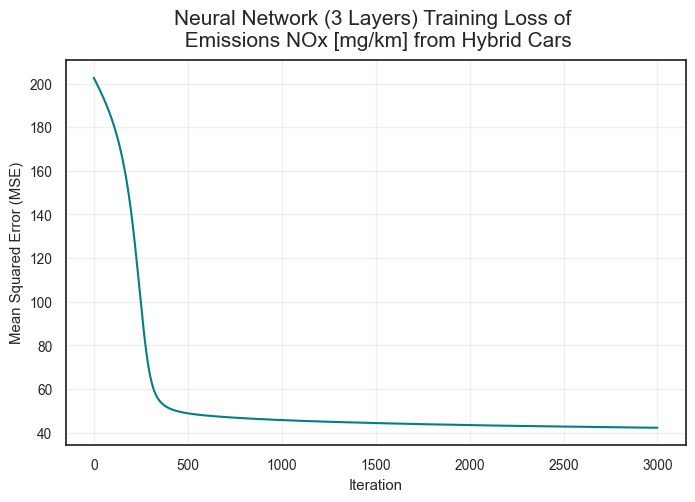

In [58]:
# NN Regression (2 hidden layers), Emissions NOx from Hybrid cars
neural_network_regression_2hidden("Emissions NOx [mg/km]", data_hybrid)

Despite having low gaps of accuracy and RMSE across different datasets, the accuracy score is quite low (nearly 50%). Thus, this model is not an effective model and should be removed at this stage

**Findings:** Similar to above findings, the similar model for CO2 predictions of hybrid car outperform other models within the same category. Thus, this model will be kepts for further comparison at the later stage <br>
Since there are no good models for predicting gas emissions (both types) for fuel cars, Neural Network Regression (4 Layers) should be built for further evaluation.

## Neural Network Regression - 4 Layers

In order to to achieve relevant model comparison, all of the current parameters in step size, and iterations will be kept. <br>
The first layer and second layer still have similar numbers of nodes with the previous models, 60 and 30 respectively. There will be an additional third layer having 20 nodes.

| Metric | Value |
| ------ | ----- |
| Training RMSE | 8.069100 |
| Coefficient of determination (R²) on training data | 0.978700 |
| Test RMSE | 23.891812 |
| Coefficient of determination (R²) on test data | 0.745500 |
| Validation RMSE | 24.803494 |
| Coefficient of determination (R²) on  validation data | 0.831000 |

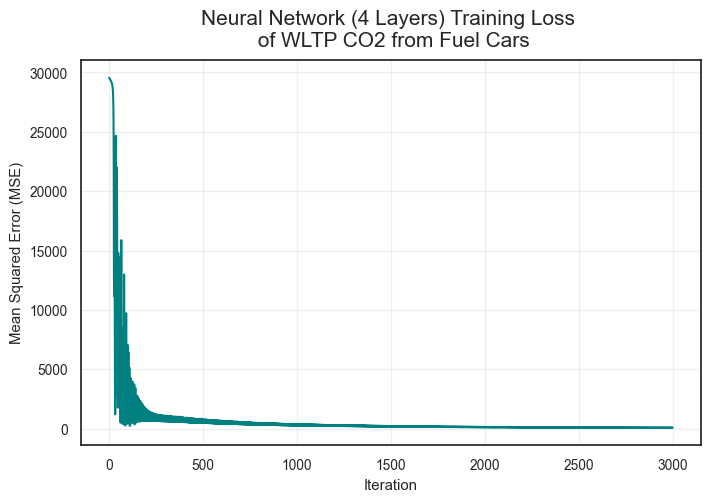

In [59]:
# Reusable function for Neural Network regression task - 3 hidden layer NN
def neural_network_regression_3hidden(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    # Perform data splitting
    splits = data_split(target, data)   
    
    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]   
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]
    
    # Flatten target arrays
    y_train = y_train.values.reshape(-1, 1)
    y_val   = y_val.values.reshape(-1, 1)
    y_test  = y_test.values.reshape(-1, 1)

    # Threshold for np.clip
    min = -500 
    max = 500

    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train.shape[1] # number of features
    D_out = 1 # number of outputs
    
    H1 = 60 # number of hidden neurons in hidden layer 1
    H2 = 30 # number of hidden neurons in hidden layer 2
    H3 = 20 # number of hidden neurons in hidden layer 3
    np.random.seed(42) # for reproducibility

    # -- Initialize weights
    # Layer 1: input -> hidden1
    W0 = normal(0, 0.1, size=(D_in, H1))
    b0 = np.zeros((1, H1))

    # Layer 2: hidden1 -> hidden2
    W1 = normal(0, 0.1, size=(H1, H2))
    b1 = np.zeros((1, H2))

    # Layer 3: hidden2 -> hidden3
    W2 = normal(0, 0.1, size=(H2, H3))
    b2 = np.zeros((1, H3))

    # Output: hidden3 -> output
    W3 = normal(0, 0.1, size=(H3, D_out))
    b3 = np.zeros((1, D_out))
    
    # Training loop
    eta = 0.0002

    loss_history = []
    for i in range(3001):
        # ---- forward pass ----
        ## Layer 1
        z1 = X_train.dot(W0) + b0
        z1 = np.clip(z1, min, max) 
        a1 = np.maximum(0, z1) #simple ReLU

        # Layer 2
        z2 = a1.dot(W1) + b1
        z2 = np.clip(z2, min, max)
        a2 = np.maximum(0, z2)

        # Layer 3
        z3 = a2.dot(W2) + b2
        z3 = np.clip(z3, -500, 500)
        a3 = np.maximum(0, z3)

        # Output (linear)
        y_hat = a3.dot(W3) + b3

        # Loss (MSE)
        Loss = np.mean((y_hat - y_train) ** 2)
        loss_history.append(float(Loss))


        # ---- backward pass ----
        dy = (2.0 / N) * (y_hat - y_train)

        # Gradients for output layer (a3 -> y_hat)
        dW3 = a3.T.dot(dy)       
        db3 = np.sum(dy, axis=0, keepdims=True)

        # Backprop into hidden3
        da3 = dy.dot(W3.T)
        dz3 = da3 * (z3 >0)
        dW2 = a2.T.dot(dz3)
        db2 = np.sum(dz3, axis=0, keepdims=True)
        
        # Backprop into hidden2
        da2 = dz3.dot(W2.T)
        dz2 = da2 * (z2 > 0)
        dW1 = a1.T.dot(dz2)
        db1 = np.sum(dz2, axis=0, keepdims=True)
        
        # Backprop into hidden1
        da1 = dz2.dot(W1.T)
        dz1 = da1 * (z1 >0)
        dW0 = X_train.T.dot(dz1)
        db0 = np.sum(dz1, axis=0, keepdims=True)
 
        # ---- update parameters ----
        W3 -= eta * dW3
        b3 -= eta * db3
        
        W2 -= eta * dW2
        b2 -= eta * db2
        
        W1 -= eta * dW1
        b1 -= eta * db1
        
        W0 -= eta * dW0
        b0 -= eta * db0

    # Evaluate on training set
    def predict(X):
        z1 = X.dot(W0) + b0
        z1_ = np.clip(z1, min, max)
        a1 = np.maximum(0, z1_)
        
        z2 = a1.dot(W1) + b1
        z2_ = np.clip(z2, min, max)
        a2 = np.maximum(0, z2_)
        
        z3 = a2.dot(W2) + b2
        z3_ = np.clip(z3, -500, 500)
        a3 = np.maximum(0, z3_)

        return a3.dot(W3) + b3

    
    # z1 = X_train_scaled.dot(W0) + b0
    # z1_ = np.clip(z1, -500, 500)
    # a1 = 1.0 / (1.0 + np.exp(-z1_))
        
    # z2 = a1.dot(W1) + b1
    # z2_ = np.clip(z2, -500, 500)
    # a2 = np.clip(z2_, -500, 500)
    
    # z3 = a2.dot(W2) + b2
    # z3_ = np.clip(z3, -500, 500)
    # a3 = 1.0 / (1.0 + np.exp(-z3_))
    # y_train_pred = a3.dot(W3) + b3

    # MSE and RMSE on training data
    y_train_pred = predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = round(r2_score(y_train, y_train_pred),4)
    #print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_train_pred)))
    #print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_train_pred),4))

    # Evaluate on test set
    y_test_pred = predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = round(r2_score(y_test, y_test_pred),4)
    #print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    #print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    y_val_pred = predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_r2 = round(r2_score(y_val, y_val_pred),4)
    #print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    #print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))

    rows = [
        ("Training RMSE", train_rmse),
        ("Coefficient of determination (R²) on training data", train_r2),
        ("Test RMSE", test_rmse),
        ("Coefficient of determination (R²) on test data", test_r2),
        ("Validation RMSE", val_rmse),
        ("Coefficient of determination (R²) on  validation data", val_r2),
    ]

    #convert into table in markdown
    table_md = ["| Metric | Value |", "| ------ | ----- |"]
    for label, value in rows:
        table_md.append(f"| {label} | {value:.6f} |")
    display(Markdown("\n".join(table_md)))

    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network (4 Layers) Training Loss \n of {target} from {data_label}",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0
    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression_3hidden("WLTP CO2", data_fuel)

The neural network model (4 layers) used for predicting CO2 emissions from fuel cars is a **potential model** as well due to having acceptable differences of RMSE results between training and test set. <br>
<br>
The accuracy rates across different sets are also acceptable with not very significant gaps. Thus, this model will be kept for further evaluation on the next stage.

| Metric | Value |
| ------ | ----- |
| Training RMSE | 12.853883 |
| Coefficient of determination (R²) on training data | 0.326300 |
| Test RMSE | 18.305319 |
| Coefficient of determination (R²) on test data | -1.238800 |
| Validation RMSE | 19.945129 |
| Coefficient of determination (R²) on  validation data | -1.331400 |

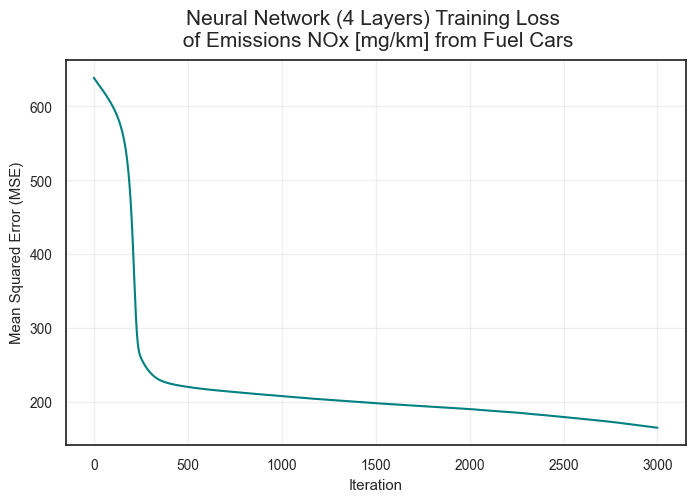

In [60]:
neural_network_regression_3hidden("Emissions NOx [mg/km]", data_fuel)

The neural network model (4 layers) used for predicting NOx emissions from fuel cars seem to be overfitting again due to similar patterns - the significant gaps of RMSE and accuracy rate across different datasets. Therefore, this model will be removed. 

| Metric | Value |
| ------ | ----- |
| Training RMSE | 16.126670 |
| Coefficient of determination (R²) on training data | 0.911300 |
| Test RMSE | 15.388180 |
| Coefficient of determination (R²) on test data | 0.914800 |
| Validation RMSE | 11.271801 |
| Coefficient of determination (R²) on  validation data | 0.937200 |

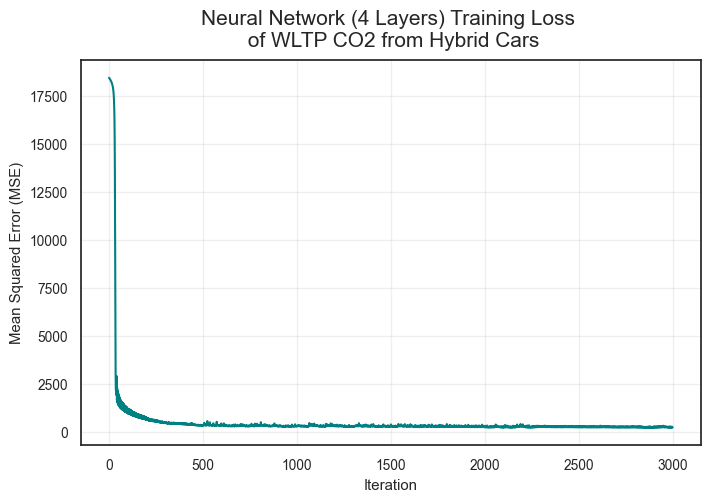

In [61]:
neural_network_regression_3hidden("WLTP CO2", data_hybrid)

Similar to above results of hybrid cars using CO2 emissions as the target variable, the neural network model (4 layers) used for predicting CO2 emissions from hybrid cars is a **potential model** due to having low differences of RMSE results between training and test set. <br>
The model also has relatively high and consistent accuracy rate across different datasets. Thus, this model will be kept for further evaluation on the next stage.

| Metric | Value |
| ------ | ----- |
| Training RMSE | 6.344130 |
| Coefficient of determination (R²) on training data | 0.465300 |
| Test RMSE | 4.655104 |
| Coefficient of determination (R²) on test data | 0.519500 |
| Validation RMSE | 8.134899 |
| Coefficient of determination (R²) on  validation data | 0.335000 |

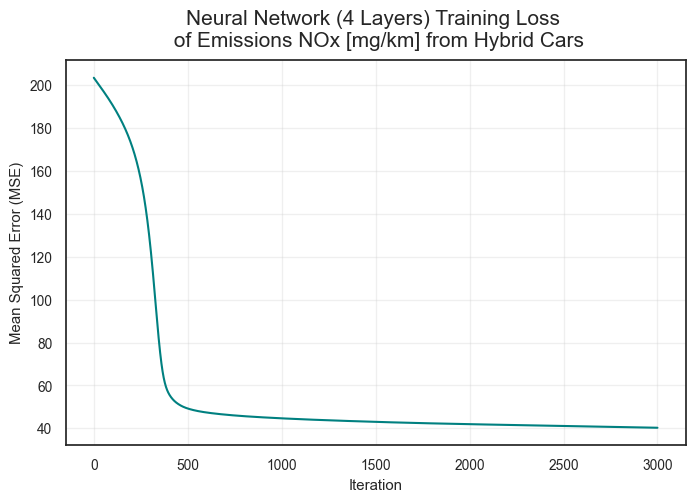

In [62]:
neural_network_regression_3hidden("Emissions NOx [mg/km]", data_hybrid)

There is also the similar patterns with the given hybrid car dataset and same target variable - NOx emissions, the accuracy score is quite low (below 50%). Thus, this model should be not be considered.

**Findings from 4 Layers:** There is an optimal regression model for predicting CO2 emissions of fuel cars now. Combining with above findings, CO2 prediction of hybrid cars tend to generate high and consistent results across different model complexity (number of layers). <br>
The below table will summarise the model selection process:   

**Summary of Neural Network Models for Fuel and Hybrid Cars**

In [63]:
# Define the data
data = {
    "NN (2 Layers)": ["No", "No", "Yes", "No"],
    "NN (3 Layers)": ["No", "No", "Yes", "No"],
    "NN (4 Layers)": ["Yes", "No", "Yes", "No"]
}

index = ["Fuel Cars, CO₂ Emissions", "Fuel Cars, NOₓ Emissions", "Hybrid Cars, CO₂ Emissions", "Hybrid Cars, NOₓ Emissions"]

# Create DataFrame
nn_table = pd.DataFrame(data, index=index)
nn_table

,NN (2 Layers),NN (3 Layers),NN (4 Layers)
"Fuel Cars, CO₂ Emissions",No,No,Yes
"Fuel Cars, NOₓ Emissions",No,No,No
"Hybrid Cars, CO₂ Emissions",Yes,Yes,Yes
"Hybrid Cars, NOₓ Emissions",No,No,No


## Model Selection

This stage is to select optimal models. These are the following selection criteria:  
- Model accuracy (R2 Score).  
- Performance consistency (the gaps between RMSE across different datasets).  
- Model Complexity (the number of layers within the model).

**CO2 predictions of Fuel Cars** <br>
Given there is one model across different layers in this caterogy, neural network model with 4 layers is the selected model to predict CO2 of fuel cars

**CO2 Predictions of Hybrid Cars** <br>
Despite being selected in all model categories, the neural network (NN) model (3 layers) will be selected to predict CO2 of hybrid cars. Although the model (4 layers) have higher accuracy, the rate is just slightly higher whereas having higher complexity (additional layer). <br>
Along with that, the neural network model (2 layers) has relatively considerable gaps of both accuracy and RMSE in different datasets. Thus, the NN model (3 layers) is the optimal model in this category.

# Support Vector Machine - Regression

In [64]:
def SVR_linear(C_value: float,
               eps_value = 0.1):
    svr = SVR(kernel='linear', C = C_value, epsilon = eps_value)
    return TransformedTargetRegressor(
        regressor=svr,
        transformer=StandardScaler() # scale y-only
    )

def SVR_RBF(C_value: float,
            eps_value = 0.1):
    svr = SVR(kernel="rbf", C = C_value, epsilon = eps_value, gamma="scale")
    return TransformedTargetRegressor(
        regressor=svr,
        transformer=StandardScaler() # scale y-only
    )

def find_margin_linear(target: str,
                data: pd.DataFrame,
                random_state = 42):
    splits = data_split(target, data)
    X_train = splits["X_train"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]   
    y_test  = splits["y_test"]

    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"
        
    margins = [0.01, 0.1, 1, 10, 100]
    rmse_list = []
    for m in margins:
        svr_linear_model = SVR_linear(C_value=m)
        svr_linear_model.fit(X_train,y_train)
        y_pre = svr_linear_model.predict(X_test)
        rmse =np.sqrt(mean_squared_error(y_test,y_pre))
        rmse_list.append(rmse)
        # print(f'C = {m}, RMSE = {rmse}')

    plt.figure(figsize=(6,4))
    plt.semilogx(margins, rmse_list, '*-')
    plt.xlabel("C Values")
    plt.ylabel("RMSE")
    plt.title(f"RMSE of LinearSVR With Different C - Target: {target} - Data: {data_label}")
    plt.show()
    
def find_margin_rbf(target: str,
                data: pd.DataFrame,
                random_state = 42):
    splits = data_split(target, data)
    X_train = splits["X_train"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]   
    y_test  = splits["y_test"]

    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"
        
    margins = [0.01, 0.1, 1, 10, 100]
    rmse_list = []
    for m in margins:
        svr_rbf_model = SVR_RBF(C_value=m)
        svr_rbf_model.fit(X_train,y_train)
        y_pre = svr_rbf_model.predict(X_test)
        rmse =np.sqrt(mean_squared_error(y_test,y_pre))
        rmse_list.append(rmse)
        # print(f'C = {m}, RMSE = {rmse}')

    plt.figure(figsize=(6,4))
    plt.semilogx(margins, rmse_list, '*-')
    plt.xlabel("C Values")
    plt.ylabel("RMSE")
    plt.title(f"RMSE of SVR_RBF With Different C - Target: {target} - Data: {data_label}")
    plt.show()

def svm_linear_model(target:str,
                     data: pd.DataFrame,
                     C: float, 
                     random_state = 42):
    splits = data_split(target, data)
    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]

    svr_linear_model = SVR_linear(C_value=C)
    svr_linear_model.fit(X_train,y_train)
    y_train_pre = svr_linear_model.predict(X_train)
    y_test_pre = svr_linear_model.predict(X_test)
    y_val_pre = svr_linear_model.predict(X_val)
    traing_rmse = np.sqrt(mean_squared_error(y_train, y_train_pre))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pre))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pre))

    print(f"Training RMSE of the model (linearSVR) is {traing_rmse}")
    print(f"Test RMSE of the model (linearSVR) is {test_rmse}")
    print(f"Validation RMSE of the model (linearSVR) is {val_rmse}")

def svm_rbf_model(target:str,
                     data: pd.DataFrame,
                     C: float, 
                     random_state = 42):
    splits = data_split(target, data)
    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]

    svr_rbf_model = SVR_RBF(C_value=C)
    svr_rbf_model.fit(X_train,y_train)
    y_train_pre = svr_rbf_model.predict(X_train)
    y_test_pre = svr_rbf_model.predict(X_test)
    y_val_pre = svr_rbf_model.predict(X_val)
    traing_rmse = np.sqrt(mean_squared_error(y_train, y_train_pre))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pre))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pre))

    print(f"Training RMSE of the model (SVR_RBF) is {traing_rmse}")
    print(f"Test RMSE of the model (SVR_RBF) is {test_rmse}")
    print(f"Validation RMSE of the model (SVR_RBF) is {val_rmse}")


**Approach**

Step1: In each SVM model, a CV is conducted to find the best C margin. 

Step2: Using the best C margin, determine the training, test and validation RMSE of the model. This step helps determine how the model adopts to the new data. 

Step 3: Aggregate findings in step 2 to determine the best model.


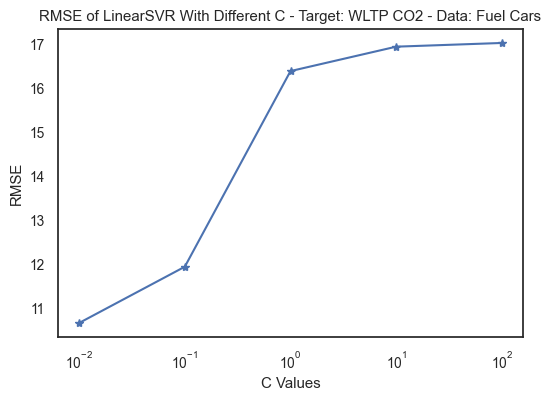

In [65]:
# SVR_linear - Data_Fuel - WLTP CO2
find_margin_linear("WLTP CO2", data_fuel)

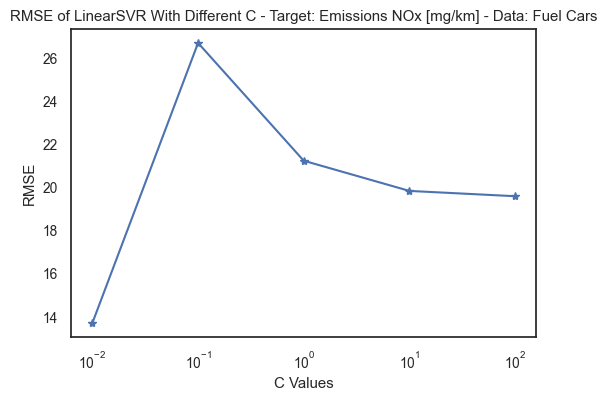

In [66]:
# SVR_linear - Data_Fuel - "Emissions NOx [mg/km]"
find_margin_linear("Emissions NOx [mg/km]", data_fuel)

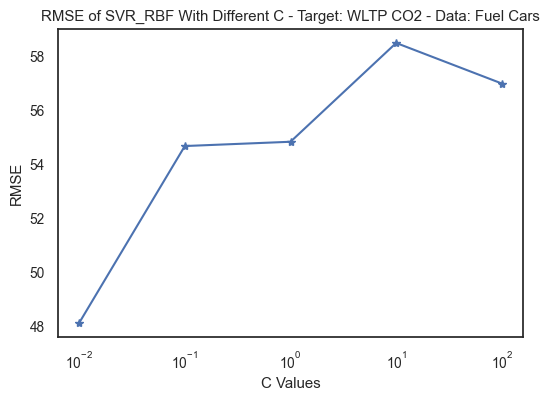

In [67]:
# SVR_RBF - Data_Fuel - "WLTP CO2"
find_margin_rbf("WLTP CO2", data_fuel)

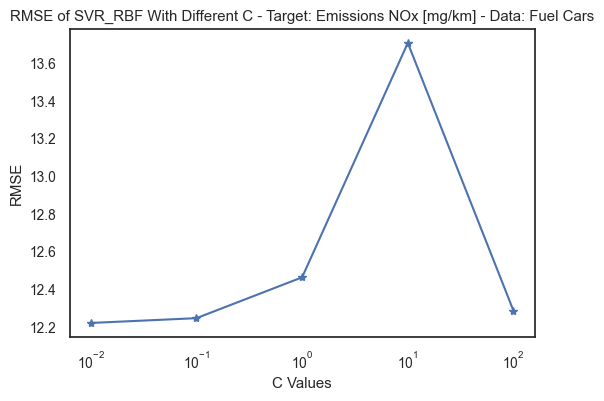

In [68]:
# SVR_RBF - Data_Fuel - "Emissions NOx [mg/km]"
find_margin_rbf("Emissions NOx [mg/km]", data_fuel)

**Findings:**
- Data: Data_Fuel - Target: WLTP CO2 - Model: LinearSVR - Best C: 0.01
- Data: Data_Fuel - Target: Emissions NOx [mg/km] - Model: LinearSVR - Best C: 0.01
- Data: Data_Fuel - Target: WLTP CO2 - Model: SVR_RBF - Best C: 0.01
- Data: Data_Fuel - Target: Emissions NOx [mg/km] - Model: SVR_RBF - Best C: 0.1
    - In this setup, RMSE at C - 0.01, 0.1 and 100 are at the same level between 12.2 and 12.3. However, C = 0.1 is selected as it is a balance between the risk of oversimplify (when C = 0.01) and overfitting (when C = 100). 





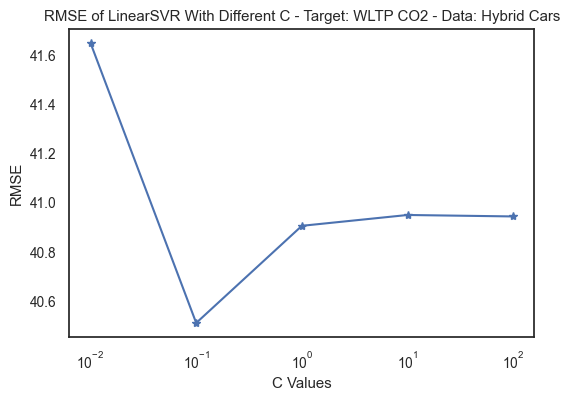

In [69]:
# SVR_linear - Data_Hybrid - WLTP CO2
find_margin_linear("WLTP CO2", data_hybrid)

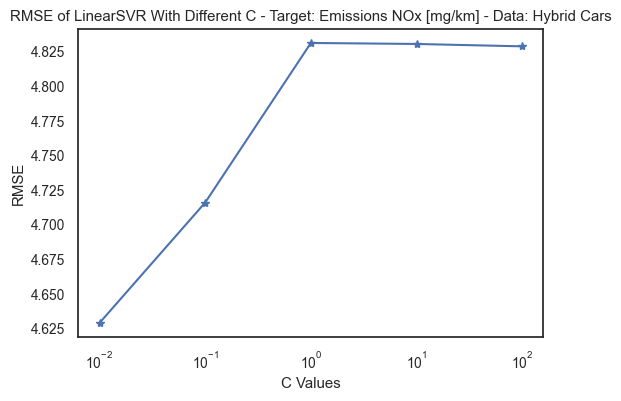

In [70]:
# SVR_linear - Data_Hybrid - Emissions NOx [mg/km]
find_margin_linear("Emissions NOx [mg/km]", data_hybrid)

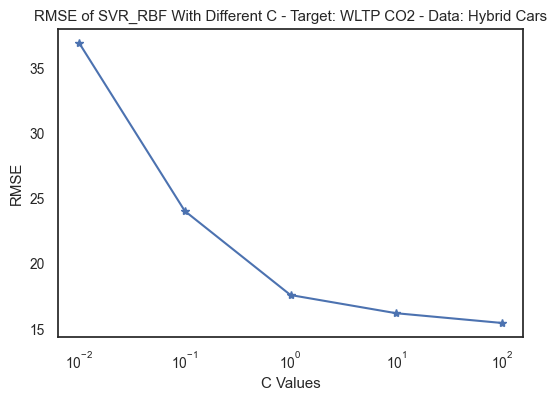

In [71]:
# SVR_RBF - Data_Hybrid - WLTP CO2
find_margin_rbf("WLTP CO2", data_hybrid)

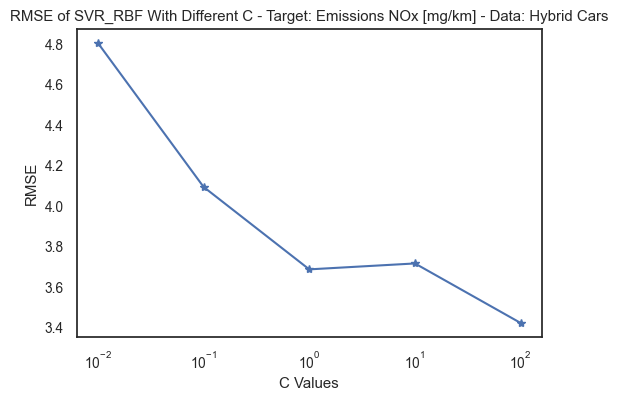

In [72]:
# SVR_RBF - Data_Hybrid - Emissions NOx [mg/km]
find_margin_rbf("Emissions NOx [mg/km]", data_hybrid)

**Findings:**  
- Data: data_hybrid - Target: WLTP CO2 - Model: LinearSVR - Best C: 0.1  
- Data: data_hybrid - Target: Emissions NOx [mg/km] - Model: LinearSVR - Best C: 0.01  
- Data: data_hybrid - Target: WLTP CO2 - Model: SVR_RBF - Best C: 100  
- Data: data_hybrid - Target: Emissions NOx [mg/km] - Model: SVR_RBF - Best C: 100  

In [73]:
# data_fuel - WLTP CO2 - LinearSVR - C = 0.01
svm_linear_model("WLTP CO2", data_fuel, C= 0.01)


Training RMSE of the model (linearSVR) is 14.818008428369495
Test RMSE of the model (linearSVR) is 10.671174583695839
Validation RMSE of the model (linearSVR) is 12.106965525400907


In [74]:
# data_fuel - WLTP CO2 - SVM_RBF - C = 0.01
svm_rbf_model("WLTP CO2", data_fuel, C= 0.01)

Training RMSE of the model (SVR_RBF) is 36.03971978226654
Test RMSE of the model (SVR_RBF) is 48.12935161919517
Validation RMSE of the model (SVR_RBF) is 60.11977282938391


**Findings 1:**
Between linearSVR and SVR_RBF models in predicting CO2 emissions from fuel cars, linearSVR is performing better. It records lower RMSEs while the gaps between training RMSE and test RMSE and validation RMSE are also smaller in linearSVR is smaller than the other. Hence, it returns a higher accuracy and a stable performance. 

In [75]:
# data_hybrid - WLTP CO2 - LinearSVR - C = 0.1
svm_linear_model("WLTP CO2", data_hybrid, C = 0.1)

Training RMSE of the model (linearSVR) is 37.60967196469193
Test RMSE of the model (linearSVR) is 40.51084216883486
Validation RMSE of the model (linearSVR) is 32.31765891375547


In [76]:
# data_hybrid - WLTP CO2 - SVR_RBF - C = 100
svm_rbf_model("WLTP CO2", data_hybrid, C = 100)

Training RMSE of the model (SVR_RBF) is 16.26323140965809
Test RMSE of the model (SVR_RBF) is 15.438230473931295
Validation RMSE of the model (SVR_RBF) is 11.777385489036144


**Findings 2:**
Between linearSVR and SVR_RBF models in predicting CO2 emissions from hybrid cars, SVR_RBF is performing better. The comparisons of figures show that SVR_RBF returns lower RMSEs. Moreover, noting that C in SVR_RBF model is 100. This means this model punishes errors heavily, which, in general, would lead to a higer error. However, the gaps between training, test and validation RMSE of this model are not significant. Hence, this model is outperforming linearSVR in this area. 

In [77]:
# data_fuel - Emissions NOx [mg/km] - LinearSVR - C = 0.01
svm_linear_model("Emissions NOx [mg/km]", data_fuel, C= 0.01)

Training RMSE of the model (linearSVR) is 15.041403692902918
Test RMSE of the model (linearSVR) is 13.71152606197146
Validation RMSE of the model (linearSVR) is 14.944216879365944


In [78]:
# data_fuel - Emissions NOx [mg/km] - SVM_RBF - C = 0.1
svm_rbf_model("Emissions NOx [mg/km]", data_fuel, C= 0.1)

Training RMSE of the model (SVR_RBF) is 14.660928513356994
Test RMSE of the model (SVR_RBF) is 12.24657395432253
Validation RMSE of the model (SVR_RBF) is 13.270477753715037


**Finding 3:**
Between linearSVR and SVR_RBF models in predicting NOx emissions from fuel cars, SVR_RBF model is a bit better than the other. Given that their RMSE are low and at the same rate (between 12 and 15), C becomes the matter in making decision. A smaller C means a simpler model, hence it has a higher bias. Moreover, a smaller C model more likely allows an error to happen. As a result, SVR_RBF model is selected with C at 0.1. 

In [79]:
# data_hybrid - Emissions NOx [mg/km] - LinearSVR - C = 0.1
svm_linear_model("Emissions NOx [mg/km]", data_hybrid, C = 0.1)

Training RMSE of the model (linearSVR) is 6.894769288588417
Test RMSE of the model (linearSVR) is 4.715904890092227
Validation RMSE of the model (linearSVR) is 8.769208267487658


In [80]:
# data_hybrid - Emissions NOx [mg/km] - SVR_RBF - C = 100
svm_rbf_model("Emissions NOx [mg/km]", data_hybrid, C = 100)

Training RMSE of the model (SVR_RBF) is 4.9344343500396155
Test RMSE of the model (SVR_RBF) is 3.4225757264201553
Validation RMSE of the model (SVR_RBF) is 8.097441934502436


**Finding 4:** 
Between linearSVR and SVR_RBF models in predicting NOx emissions from hybrid cars, linearSVR model outperforms the other. The outcomes record that both have relevantly small RMSE accrosing training, test and validation dataset. however, the notice is at the gap between test RMSE and validation RMSE in SVR_RBF model, which is significant (3.4 and 8.90). This suggests an inconsistent of performance of this model with new data. As a result, linearSVR is chosen in this comparison.  

**Conclusion in training SVM models:**

In the model selection process, two main criteria are considered: 

- ⁠Model accuracy using RMSE metric.
- ⁠Model complexity based on C value

As a result, there are four models selected for different set of target variable and dataset.  
1. LinearSVR with C at 0.01 is the best in predicting CO2 emission from fuel cars (Finding 1)  
2. ⁠SVR_RBF with C at 100 is the best in predicting CO2 emission from hybrid cars (Finding 2)  
3. ⁠SVR_RBF with C at 0.1 is the best in predicting NOx emission from fuel cars (Finding 3)  
4. ⁠LinearSVR with C at 0.1 is the best in predicting NOx emisison from hybrid cars (Finding 4)  


# Conclusion
**For CO2 Emissions prediction from fuel cars**
- ⁠Within the same target variable and dataset, in comparison to Neural Network Regression (4 Layers) above, LinearSVR with C at 0.01 is the best in predicting CO2 emission from fuel cars due to having lower gaps of RMSE. The RMSE of training set is also lower than the figure for test set. 

**For CO2 Emissions prediction from hybrid cars**
- ⁠In comparison between Neural Network (3 layers) and SVR_RBF model, there are no significant differences in RMSE values. Hence, both can be kept. 

**For NOx Emissions prediction from fuel cars and hybrid cars**
- As there is no Neural Network Regression for comparison, two models in Finding 3 and 4 of SVM model training are kept as the only best models.
- ⁠They are
    - SVR_RBF with C at 0.1 is the best in predicting NOx emission from fuel cars (Finding 3)
    - LinearSVR with C at 0.1 is the best in predicting NOx emisison from hybrid cars (Finding 4)

# References
- European Environment Agency, 2023, 'Greenhouse Gas Emissions from Transport in Europe.', _EEA Report No. 23/2023_, Publications Office of the European Union.

- Intergovernmental Panel on Climate Change (IPCC), 2022, 'Climate Change 2022: Mitigation of Climate Change', _Contribution of Working Group III to the Sixth Assessment Report of the IPCC_, Cambridge University Press.

- UK Vehicle Certification Agency, 2024, _Fuel Consumption and Emission Data Tables: Car Fuel and CO₂ Information. Department for Transport_, viewed 29 September 2025, <https://www.vehicle-certification-agency.gov.uk/>

- World Health Organization, 2021, _WHO Global Air Quality Guidelines: Particulate Matter, Ozone, Nitrogen Dioxide, Sulfur Dioxide and Carbon Monoxide_, Geneva: WHO.

- U.S. Environmental Protection Agency (EPA), 2023, _Nitrogen Oxides (NOₓ) Pollution_, EPA.

- European Environment Agency (EEA), 2022, _Air Pollution Sources — Volatile Organic Compounds (VOCs)_, EEA Report

- Veza, Ibham et al, 2023, 'Electric Vehicle (EV) and Driving Towards Sustainability: Comparison between EV, HEV, PHEV, and ICE Vehicles to Achieve Net Zero Emissions by 2050 from EV', _Alexandria Engineering Journal_, vol. 82, pp. 459–467, DOI.10.1016/j.aej.2023.10.020

